# Reliability- and Uncertainty-Aware Multimodal Learning for Disaster Understanding
## Part 2 of 2 — Loading Part 1 Results, Evaluation, and Visualization

This notebook is designed to run **independently, in a fresh runtime**, using only the files
saved by `Disaster_Research_Part1.ipynb` under `disaster_research_outputs/`. It does not assume
any Python variable from Part 1 is still in memory.

**Required inputs (produced by Part 1):**
```
disaster_research_outputs/
├── checkpoints/best_model.pt
├── data/df_train.pkl, df_dev.pkl, df_test.pkl
├── data/label_encoders.pkl
├── data/model_config.json
└── data/history.pkl, best_val_f1.json      (optional, used for the training-curve plot)
```
If any required file is missing, the loading cell below raises a clear error naming the missing
file and telling you to run Part 1. It never trains a substitute model or fabricates a result.

**How this notebook reconstructs the pipeline (unchanged architecture):** rather than
un-pickling a live model or a `DataLoader` (which cannot be pickled — `_MultiProcessingDataLoaderIter
cannot be pickled` — and would be fragile even if it could), this notebook:
1. Re-defines the *exact same* architecture classes as the original notebook (Sections 5–11,
   copied verbatim below) and the *exact same* `CrisisMMDDataset` class (Section 3.4).
2. Loads the saved dataframes, label encoders, and `model_config.json` (Section 2, reconstructed
   from files instead of by re-parsing the raw CrisisMMD `.tsv`/images).
3. Rebuilds `ds_dev` / `ds_test` / `dl_dev` / `dl_test` from those dataframes (no `ds_train` /
   `dl_train` — this notebook does not train).
4. Instantiates `CrisisMultiModal` with the saved configuration and loads `best_model.pt` into it.
5. Continues with the original Sections 14–26 (calibration, results, confusion matrices,
   uncertainty analysis, Grad-CAM, t-SNE, ablation, significance, single-sample inference,
   summary), copied verbatim, plus the two new uncertainty visualizations at the end of Section 18.

### Environment constraint (read before running)
Exactly as in Part 1: this notebook was assembled **without GPU access, without
`torch`/`transformers` installed, and without the CrisisMMD dataset or a trained checkpoint** in
the environment used to do the splitting. Every cell below has been statically checked (parsed,
variable-dependency-traced) but **not executed**. You must run Part 1 to completion first (to
produce `disaster_research_outputs/`), then run this notebook top-to-bottom yourself on a GPU
runtime to get real numbers. Any pre-existing outputs you see if you open an *already-executed*
copy of these cells are a genuine prior run, not something regenerated during this split.

### One inherited ambiguity flagged, not silently resolved
Section 18 of the original notebook (`all_rt`, `all_rv`, kept below unchanged) is populated
directly from the model's own `out['u_t']` / `out['u_v']` outputs — i.e., **these arrays already
are the model's uncertainty estimates** — but Section 18's own plotting/calibration code (cells
kept verbatim below) subsequently *treats them as if they were reliability scores* and computes
`uncertainty = 1 - value`. This is a naming/semantics inconsistency in the **original** research
code, not something introduced by this split. Per the instruction not to silently change research
code, it is left exactly as-is below. For the two **new** visualizations required in this task
(Section 18.2/18.3), the safer, most literal reading — use the actual model-produced uncertainty
values without inverting them — is used instead, i.e. `all_rt`/`all_rv` directly. This is called
out again at that cell. **Please confirm which convention is correct for your paper** before
reporting numbers from either version.


### Fix log (code corrections in this copy)
- **Cell 17**: emoji written as lone surrogates (`\ud83e\uddea`) crashed output flushing -> proper code points.
- **Cell 39**: reload checkpoint into the unwrapped model (fails on multi-GPU `DataParallel` otherwise).
- **Cell 46**: `Styler.applymap` removed in pandas 3 -> `map`; Verification proxy flag matched wrong name.
- **Cell 54**: Matplotlib `boxplot(labels=)` -> `tick_labels`.
- **Cell 64**: `np.trapz` removed in NumPy 2 -> `np.trapezoid`.
- **Cell 67**: `TSNE(n_iter=)` removed in scikit-learn -> `max_iter`.
- **Cell 87**: ablation calibration now applies temperature *and* bias, like Section 14.
- **Cell 97**: single-sample quality features now match the training columns.
- **Cells 77/79/102**: Section 21.5 fixed for Part 1's 5-value `run_epoch`; `best_val_f1` None guard.
- Progress bars added to the slow dev/test passes (cells 33, 39). **Run on a GPU runtime.**


## 1. Environment Setup (same as Part 1, re-run standalone)

In [1]:
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

pip_install('sentencepiece')
pip_install('protobuf')
pip_install('transformers==4.40.1')
pip_install('open_clip_torch')
pip_install('grad-cam')

print('✅ All packages installed successfully.')

import gc
gc.collect()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 79.1 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.1 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.3 MB/s eta 0:00:00
✅ All packages installed successfully.


4

In [2]:
import os, sys, warnings, logging, random, json, time, copy, math
from pathlib import Path
from datetime import datetime
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.ERROR)

import numpy  as np
import pandas as pd
from scipy.stats import entropy as scipy_entropy

import matplotlib
import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
matplotlib.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})

import torch
import torch.nn            as nn
import torch.nn.functional as F
import torch.optim         as optim
from torch.utils.data      import Dataset, DataLoader
from torch.cuda.amp        import GradScaler, autocast

from transformers import (
    AutoTokenizer, AutoModel,
    get_cosine_schedule_with_warmup,
)
import open_clip

from PIL                import Image
import cv2
from torchvision        import transforms

from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, precision_recall_fscore_support,
)
from sklearn.preprocessing import LabelEncoder

def free_memory():
    """Release Python + CUDA memory. Call after large intermediate objects
    (dataframes, batches, hooks) are no longer needed."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print('✅ All libraries imported | seed_everything() defined -- call it explicitly per run/seed, no fixed lock here')

import gc
gc.collect()
try:
    import torch
    torch.cuda.empty_cache()
except Exception:
    pass

✅ All libraries imported | seed_everything() defined -- call it explicitly per run/seed, no fixed lock here


In [3]:
if torch.cuda.is_available():
    DEVICE     = torch.device('cuda')
    N_GPUS     = torch.cuda.device_count()
    GPU_NAMES  = [torch.cuda.get_device_name(i) for i in range(N_GPUS)]
    VRAM_GB    = [torch.cuda.get_device_properties(i).total_memory / 1e9 for i in range(N_GPUS)]
else:
    DEVICE    = torch.device('cpu')
    N_GPUS    = 0
    GPU_NAMES = []
    VRAM_GB   = []

USE_AMP = N_GPUS > 0

print('=' * 60)
print('  🖥️  Hardware Configuration')
print('=' * 60)
print(f'  PyTorch Version  : {torch.__version__}')
print(f'  CUDA Available   : {torch.cuda.is_available()}')
print(f'  Device           : {DEVICE}')
print(f'  Number of GPUs   : {N_GPUS}')
for i, (name, vram) in enumerate(zip(GPU_NAMES, VRAM_GB)):
    print(f'    GPU {i}: {name}  ({vram:.1f} GB VRAM)')
print(f'  Mixed Precision  : {USE_AMP}')
print('=' * 60)
if N_GPUS == 0:
    print('GPU not available. Full model training may be computationally expensive on CPU.')
    print('The notebook remains functionally CPU-safe; no CUDA-only code path is required to run it.')

def gpu_memory_report():
    """Per-GPU allocated / reserved / total memory (GB). No-op message on CPU-only runs.
    Call between large experiments (Grad-CAM, t-SNE, ablation, checkpoint reloads) to check
    headroom on each T4 individually -- with 2xT4, each GPU has its OWN ~15 GB limit; the pair
    is NOT a pooled 32 GB device, and nn.DataParallel still replicates activations per-GPU."""
    if not torch.cuda.is_available():
        print('  [gpu_memory_report] No CUDA device available.')
        return
    print('-' * 60)
    for i in range(torch.cuda.device_count()):
        alloc = torch.cuda.memory_allocated(i) / 1e9
        resv  = torch.cuda.memory_reserved(i)  / 1e9
        total = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f'  GPU {i} ({torch.cuda.get_device_name(i)}): '
              f'allocated={alloc:5.2f} GB | reserved={resv:5.2f} GB | total={total:5.2f} GB')
    print('-' * 60)

gpu_memory_report()

free_memory()

  🖥️  Hardware Configuration
  PyTorch Version  : 2.10.0+cu128
  CUDA Available   : True
  Device           : cuda
  Number of GPUs   : 2
    GPU 0: Tesla T4  (15.6 GB VRAM)
    GPU 1: Tesla T4  (15.6 GB VRAM)
  Mixed Precision  : True
------------------------------------------------------------
  GPU 0 (Tesla T4): allocated= 0.00 GB | reserved= 0.00 GB | total=15.64 GB
  GPU 1 (Tesla T4): allocated= 0.00 GB | reserved= 0.00 GB | total=15.64 GB
------------------------------------------------------------


In [4]:
import os
import gc
from pathlib import Path

def _find_dataset_root():
    env = os.environ.get('CRISISMD_ROOT')
    if env and Path(env).exists():
        return Path(env)

    kaggle_slugs = [
        '/kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset',
        '/kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0',
        '/kaggle/input/crisismmd-multimodal-crisis-dataset',
        '/kaggle/input/crisismmdv2',
        '/kaggle/input/crisis-mmd',
    ]
    for s in kaggle_slugs:
        if Path(s).exists():
            return Path(s)

    local_tries = [
        Path('/content/CrisisMMD_v2.0'),
        Path('/content/CrisisMMD'),
        Path('/workspace/CrisisMMD'),
        Path('/data/CrisisMMD'),
        Path.home() / 'datasets' / 'CrisisMMD',
        Path.home() / 'data' / 'CrisisMMD',
        Path('./CrisisMMD_v2.0'),
        Path('./CrisisMMD'),
    ]
    for p in local_tries:
        if p.exists():
            return p

    raise FileNotFoundError(
        '\n' + '=' * 65 + '\n'
        'CrisisMMD dataset NOT FOUND.\n\n'
        'Check the right-hand sidebar under "Data" and ensure the dataset is attached.\n'
        + '=' * 65
    )

def _find_data_dir(root):
    sub = root / 'CrisisMMD_v2.0'
    return sub if sub.exists() else root

def _find_output_dir():
    for candidate in [Path('/kaggle/working'), Path('/content'), Path('./outputs')]:
        if candidate.parent.exists():
            candidate.mkdir(parents=True, exist_ok=True)
            return candidate
    return Path('.')

try:
    _ROOT = _find_dataset_root()
except FileNotFoundError as e:
    print(e)
    _ROOT = Path('.')

_DATA    = _find_data_dir(_ROOT)
_ANN_DIR = _DATA / 'annotations'
_IMG_DIR = _DATA / 'data_image'
_OUT_DIR = _find_output_dir()

class CFG:

    # Master seed for this run's reproducibility (train/dev/test split, model init,
    # dropout, shuffling, TSNE, etc). This notebook is fixed to a single official seed.
    SEED      = 42

    ROOT      = _ROOT
    DATA_DIR  = _DATA
    ANN_DIR   = _ANN_DIR
    IMG_DIR   = _IMG_DIR
    OUT_DIR   = _OUT_DIR

    ALL_TSVS  = [
        f for f in _ANN_DIR.iterdir()
        if f.suffix == '.tsv' and not f.name.startswith('._')
    ] if _ANN_DIR.exists() else []

    ROBERTA_CKPT  = 'microsoft/deberta-v3-base'
    CLIP_MODEL    = 'ViT-B-32'
    CLIP_PRETRAIN = 'openai'

    TEXT_DIM      = 768
    VIS_DIM       = 768
    FUSE_DIM      = 768
    GRAPH_HIDDEN  = 512
    GRAPH_OUT     = 384
    HEAD_DIM      = 256

    BATCH_SIZE    = 32
    EPOCHS        = 45
    LR_ROBERTA    = 1e-5
    LR_CLIP       = 1e-5
    LR_HEAD       = 3e-4
    WEIGHT_DECAY  = 1e-2
    WARMUP_RATIO  = 0.1
    MAX_GRAD_NORM = 1.0
    MAX_LEN       = 128
    IMG_SIZE      = 224
    PATIENCE      = 10

    CKPT_TASKS       = ['human', 'damage']
    CKPT_METRIC_BLEND = 0.5   # NEW: checkpoint-selection criterion blends macro F1 (weight
                              # CKPT_METRIC_BLEND) with weighted F1 (1-CKPT_METRIC_BLEND), so
                              # the saved checkpoint can't win purely via majority classes.
    FOCAL_GAMMA_HUD    = 1.5

    FOCAL_GAMMA_HUMAN  = 2.0   # was 1.5 -- pushed up to down-weight easy majority
                               # (not_humanitarian/rescue_or_response) samples harder,
                               # since affected_people/damage_related sit at ~100-130 support.
    FOCAL_GAMMA_DAMAGE = 1.8   # was 1.2 -- same reasoning for little_or_no_damage (35) /
                               # mild_damage (92).
    USE_SAMPLER      = True

    SOFTEN_CB_WITH_SAMPLER = True

    USE_CLASS_BALANCED_LOSS = True

    CB_BETA                 = 0.999 if SOFTEN_CB_WITH_SAMPLER and USE_SAMPLER else 0.9999
    USE_MANIFOLD_MIXUP      = True
    MIXUP_ALPHA             = 0.2
    MIXUP_PROB              = 0.5
    USE_LOGIT_CALIBRATION   = True
    CALIB_SEARCH_ITERS      = 800   # was 300 -- 3-4 classes/task needs more random-coordinate
                                    # steps to actually cover the bias search space.
    USE_TTA                 = True
    USE_TEXT_CLEANING       = True
    USE_HIERARCHICAL_GATING = True   # legacy POST-HOC rule -- confidence-thresholded, off
                                      # by default per Section 21.2 (do not confuse with
                                      # USE_TASK_GATES below, which is a different mechanism).
    USE_TASK_GATES = True   # NEW: learned, differentiable FiLM-style gates on the human/damage
                            # heads (see Section 11.1). Trained jointly, initialized as an
                            # identity map, so it can only help -- it is NOT the hard post-hoc
                            # override that Section 21.2 found and disabled.
    GATE_HIDDEN = 128
    RUN_GENUINE_ABLATION    = True
    ABLATION_RETRAIN_EPOCHS = 15

    ABLATION_SEEDS          = [SEED]   # single-seed notebook: ablation uses the same official seed

    FREEZE_ENCODER_EPOCHS = 2
    HUMAN_DAMAGE_LABEL_SMOOTHING = 0.08
    USE_NO_DECAY_GROUPS   = True
    LOG_VAR_CLAMP         = (-3.0, 3.0)
    MIXUP_LOSS_BLEND      = 0.3
    GRAD_ACCUM_STEPS      = 2

    EFFECTIVE_SCHEDULE_EPOCHS = 22
    SWA_PER_TASK_TOLERANCE    = 0.01

    LAMBDA_EVENT   = 1.0
    LAMBDA_INFO    = 1.2
    LAMBDA_HUMAN   = 2.0
    LAMBDA_DAMAGE  = 2.0
    LAMBDA_VERIF   = 1.2

    LAMBDA_UNCERT  = 0.3

    FOCAL_GAMMA_VERIF = 1.5
    CB_BETA_VERIF     = 0.99
    VERIF_LABEL_SMOOTHING = 0.05

    EREM_N_PROTOTYPES = 8

    USE_FILM_SE_GATING = True

    USE_SUPCON      = True
    SUPCON_TEMP     = 0.1
    SUPCON_TASK     = 'event_type'
    SUPCON_WEIGHT_INIT = 0.15

    GRADCAM_N_EVAL_SAMPLES = 100
    GRADCAM_METHODS        = ['gradcam', 'gradcam++', 'eigencam']
    CALIBRATION_METHOD     = 'temperature_and_bias'
    CALIB_METRIC            = 'macro'   # NEW: bias search now optimizes macro-F1 for
                                         # human/damage instead of weighted-F1, so it can't
                                         # improve by ignoring the rare classes.

    EVENT_LABELS  = ['earthquake', 'fire', 'flood', 'hurricane']
    INFO_LABELS   = ['informative', 'not_informative']
    # Collapsed to 4 classes (from the original 7) to fix severe class imbalance:
    # rare classes (affected_individuals, injured_or_dead_people, missing_or_found_people)
    # merge into 'affected_people'; (infrastructure_and_utility_damage, vehicle_damage)
    # merge into 'damage'; (rescue_volunteering_or_donation_effort, other_relevant_information)
    # merge into 'rescue_or_response'. 'not_humanitarian' is kept separate since it is a
    # semantically distinct (and well-populated) negative class. Actual class count is
    # re-derived from the encoded data in Section 2 (cfg.N_HUMAN is overwritten there),
    # so this list is documentation of intent, not the source of truth at runtime.
    HUMAN_LABELS  = [
        'affected_people', 'damage_related', 'rescue_or_response', 'not_humanitarian'
    ]
    DAMAGE_LABELS = ['little_or_no_damage', 'mild_damage', 'severe_damage']
    VERIF_LABELS  = ['authentic', 'fabricated']

    N_EVENT   = len(EVENT_LABELS)
    N_INFO    = len(INFO_LABELS)
    N_HUMAN   = len(HUMAN_LABELS)
    N_DAMAGE  = len(DAMAGE_LABELS)
    N_VERIF   = len(VERIF_LABELS)

    CKPT_DIR  = _OUT_DIR / 'checkpoints'
    PLOTS_DIR = _OUT_DIR / 'plots'
    METRICS_DIR = _OUT_DIR / 'metrics'
    PRED_DIR  = _OUT_DIR / 'predictions'
    LOG_DIR   = _OUT_DIR / 'logs'
    for _d in (CKPT_DIR, PLOTS_DIR, METRICS_DIR, PRED_DIR, LOG_DIR):
        _d.mkdir(parents=True, exist_ok=True)

    CKPT_PATH = str(CKPT_DIR / 'best_model.pt')

cfg = CFG()

# Seed every RNG (python/numpy/torch CPU+CUDA) with cfg.SEED BEFORE any split,
# model init, or dataloader shuffling happens downstream.
seed_everything(cfg.SEED)
print(f'🌱 Global seed set to {cfg.SEED} (seed_everything applied)')

print('📋 Configuration Summary')
print('─' * 70)
print(f'  Root Base   : {cfg.ROOT}')
print(f'  Annotations : {cfg.ANN_DIR}')
print(f'  Images      : {cfg.IMG_DIR}')
print(f'  TSVs Found  : {len(cfg.ALL_TSVS)}')
print(f'  Checkpoints : {cfg.CKPT_DIR}')
print(f'  Plots       : {cfg.PLOTS_DIR}')
print(f'  Metrics     : {cfg.METRICS_DIR}')
print(f'  Predictions : {cfg.PRED_DIR}')
print('─' * 70)

_n_gpus_eff = max(N_GPUS, 1)
_effective_batch = cfg.BATCH_SIZE * cfg.GRAD_ACCUM_STEPS * _n_gpus_eff
print('\n📦 Batch / Multi-GPU Configuration')
print('─' * 70)
print(f'  Per-device batch size     : {cfg.BATCH_SIZE}')
print(f'  Gradient accumulation     : {cfg.GRAD_ACCUM_STEPS} steps')
print(f'  GPUs used (DataParallel)  : {N_GPUS if N_GPUS > 0 else "0 (CPU)"}')
print(f'  Multi-GPU active          : {N_GPUS > 1}')
print(f'  Effective global batch    : {cfg.BATCH_SIZE} x {cfg.GRAD_ACCUM_STEPS} x {_n_gpus_eff} = {_effective_batch}')
print('  Note: with 2xT4, DataParallel splits each batch across GPUs; each GPU still holds')
print('        its own activations/gradients within its own ~15 GB, memory does NOT pool.')
print('─' * 70)

free_memory()

🌱 Global seed set to 42 (seed_everything applied)
📋 Configuration Summary
──────────────────────────────────────────────────────────────────────
  Root Base   : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset
  Annotations : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/annotations
  Images      : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image
  TSVs Found  : 7
  Checkpoints : /kaggle/working/checkpoints
  Plots       : /kaggle/working/plots
  Metrics     : /kaggle/working/metrics
  Predictions : /kaggle/working/predictions
──────────────────────────────────────────────────────────────────────

📦 Batch / Multi-GPU Configuration
──────────────────────────────────────────────────────────────────────
  Per-device batch size     : 32
  Gradient accumulation     : 2 steps
  GPUs used (DataParallel)  : 2
  Multi-GPU active          : True
  Effective global batch    : 32 x 2 x 2 = 128
 

## 2. Load Part 1 Artifacts (NEW — replaces raw CrisisMMD parsing)

The original Section 2 parsed the raw CrisisMMD `.tsv` annotation files and images from scratch.
Part 2 does not re-parse the raw dataset: it loads the already-cleaned, already-encoded
dataframes and label encoders that Part 1 saved, which is both faster and guarantees Part 2 sees
*exactly* the same train/dev/test split and label indices the model was trained and checkpointed
against.

In [5]:
# ==== Locate and validate disaster_research_outputs/ ====
import os, sys, json, pickle

REQUIRED_FILES = [
    'checkpoints/best_model.pt',
    'data/df_train.pkl',
    'data/df_dev.pkl',
    'data/df_test.pkl',
    'data/label_encoders.pkl',
    'data/model_config.json',
]

def _is_complete(cand):
    return all(os.path.exists(os.path.join(cand, rel)) for rel in REQUIRED_FILES)

def _find_results_dir(max_depth=6):
    """Search likely roots (env var, Colab, Kaggle working dir, cwd) shallowly first, then fall
    back to a bounded recursive search under /kaggle/input and /content -- Kaggle nests notebook-
    output sources at variable depth, e.g. /kaggle/input/notebooks/<user>/<slug>/..., and dataset
    sources at /kaggle/input/<slug>/..., so a fixed-depth guess is not reliable."""
    checked = []

    shallow = []
    env = os.environ.get('DISASTER_RESULTS_DIR')
    if env:
        shallow.append(env)
    shallow += [
        '/content/disaster_research_outputs',
        '/content/drive/MyDrive/disaster_research_outputs',
        '/kaggle/working/disaster_research_outputs',
        os.path.join(os.getcwd(), 'disaster_research_outputs'),
    ]
    for cand in shallow:
        checked.append(cand)
        if _is_complete(cand):
            return cand, checked

    # Bounded recursive search: look for the checkpoint file itself, anywhere reachable, then
    # verify the rest of REQUIRED_FILES relative to its two-levels-up directory (.../checkpoints/best_model.pt).
    roots = [r for r in ('/kaggle/input', '/content') if os.path.isdir(r)]
    for root in roots:
        for dirpath, dirnames, filenames in os.walk(root):
            depth = dirpath[len(root):].count(os.sep)
            if depth > max_depth:
                dirnames[:] = []
                continue
            if 'best_model.pt' in filenames and os.path.basename(dirpath) == 'checkpoints':
                cand = os.path.dirname(dirpath)
                checked.append(cand)
                if _is_complete(cand):
                    return cand, checked
    return None, checked

RESULTS_DIR, _checked = _find_results_dir()

if RESULTS_DIR is None:
    checked_str = "\n".join(f'  - {c}' for c in _checked)
    raise FileNotFoundError(
        "Could not find a complete disaster_research_outputs/ folder (all of "
        f"{REQUIRED_FILES} under one directory).\n"
        "Checked (shallow candidates; a recursive search under /kaggle/input and /content also ran "
        "and found nothing complete):\n" + checked_str + "\n\n"
        "Run Disaster_Research_Part1.ipynb to completion first, then either:\n"
        "  - Colab: mount Drive and confirm /content/drive/MyDrive/disaster_research_outputs exists, or\n"
        "  - Kaggle: attach the Part 1 notebook's saved Output as an input source to this notebook, or\n"
        "  - set the DISASTER_RESULTS_DIR environment variable to the folder's exact path "
        "(run `os.walk('/kaggle/input')` to find it if unsure)."
    )

print(f'Found Part 1 artifacts at: {RESULTS_DIR}')
CKPT_SAVE_DIR = os.path.join(RESULTS_DIR, 'checkpoints')
DATA_SAVE_DIR = os.path.join(RESULTS_DIR, 'data')


Found Part 1 artifacts at: /kaggle/input/notebooks/shivaanjankumarthota/notebook1-1/disaster_research_outputs


In [6]:
# ==== Load dataframes, label encoders, and the real (data-derived) model configuration ====
import pandas as pd

df_train = pd.read_pickle(os.path.join(DATA_SAVE_DIR, 'df_train.pkl'))
df_dev   = pd.read_pickle(os.path.join(DATA_SAVE_DIR, 'df_dev.pkl'))
df_test  = pd.read_pickle(os.path.join(DATA_SAVE_DIR, 'df_test.pkl'))
print(f'Loaded df_train={len(df_train)}  df_dev={len(df_dev)}  df_test={len(df_test)} rows.')

with open(os.path.join(DATA_SAVE_DIR, 'label_encoders.pkl'), 'rb') as f:
    LABEL_ENCODERS = pickle.load(f)
print('Loaded LABEL_ENCODERS:', {k: list(v.classes_) for k, v in LABEL_ENCODERS.items()})

with open(os.path.join(DATA_SAVE_DIR, 'model_config.json')) as f:
    MODEL_CONFIG = json.load(f)

# Override the CFG defaults with the REAL, data-derived values from Part 1 -- this matters
# because cfg.N_HUMAN etc. in the CFG class body are documentation-of-intent defaults; Section 2
# of the original notebook overwrites them from the actual encoded label counts, and Part 2 must
# match that exactly or the reconstructed model's output layers will be the wrong shape.
cfg.N_EVENT  = MODEL_CONFIG['N_EVENT']
cfg.N_INFO   = MODEL_CONFIG['N_INFO']
cfg.N_HUMAN  = MODEL_CONFIG['N_HUMAN']
cfg.N_DAMAGE = MODEL_CONFIG['N_DAMAGE']
cfg.N_VERIF  = MODEL_CONFIG['N_VERIF']
cfg.USE_TASK_GATES = MODEL_CONFIG['USE_TASK_GATES']
VERIF_IS_REAL = MODEL_CONFIG['VERIF_IS_REAL']

# Optional: training history / best dev score, for the training-curve plot (Section 15).
HISTORY = None
_hist_path = os.path.join(DATA_SAVE_DIR, 'history.pkl')
if os.path.exists(_hist_path):
    with open(_hist_path, 'rb') as f:
        HISTORY = pickle.load(f)
    print('Loaded HISTORY for the training-curve plot.')
else:
    print('history.pkl not found -- Section 15 (training curves) will be skipped.')

best_val_f1 = None
_bvf_path = os.path.join(DATA_SAVE_DIR, 'best_val_f1.json')
if os.path.exists(_bvf_path):
    with open(_bvf_path) as f:
        best_val_f1 = json.load(f)['best_val_f1']

print('\nEffective task sizes for this run: N_EVENT=%d N_INFO=%d N_HUMAN=%d N_DAMAGE=%d N_VERIF=%d'
      % (cfg.N_EVENT, cfg.N_INFO, cfg.N_HUMAN, cfg.N_DAMAGE, cfg.N_VERIF))


Loaded df_train=14465  df_dev=1808  df_test=1809 rows.
Loaded LABEL_ENCODERS: {'event_type': ['earthquake', 'fire', 'flood', 'hurricane'], 'informative': ['informative', 'not_informative'], 'humanitarian': ['affected_people', 'damage_related', 'not_humanitarian', 'rescue_or_response'], 'damage': ['dont_know_or_cant_judge', 'little_or_no_damage', 'mild_damage', 'severe_damage']}
Loaded HISTORY for the training-curve plot.

Effective task sizes for this run: N_EVENT=4 N_INFO=2 N_HUMAN=4 N_DAMAGE=4 N_VERIF=2


### `clean_text` (extracted from the original Section 2 cell, unchanged)

The original tweet-text cleaning function is a standalone function with no dataset dependency.
It is only needed here for `predict_single` (Section 24) and Grad-CAM case studies. The saved
dataframes already have cleaned text (`text` column) and the original raw text (`text_raw`
column) baked in from Part 1, so this is only re-defined for functions that clean *new*,
user-supplied text at inference time.

In [7]:
import re

_DIR_TAG_RE = re.compile(r'(?:[\w\-]+/)+[\w\-.]+')
_SOURCE_TAG_RE = re.compile(
    r'\b(?:' + '|'.join([
        'california_wildfires', 'hurricane_(?:harvey|irma|maria|florence|michael)',
        'mexico_earthquake', 'iraq_iran_earthquake', 'sri_lanka_floods',
        'srilanka_floods', 'puebla_mexico_earthquake', 'ecuador_earthquake',
        'data_image', 'crisismmd', 'annotations_final', 'consolidated'
    ]) + r')\b', flags=re.IGNORECASE
)

_URL_RE      = re.compile(r'https?://\S+|www\.\S+')
_MENTION_RE  = re.compile(r'@\w+')
_RT_PREFIX_RE = re.compile(r'^\s*RT\s*[:\-]?\s*', flags=re.IGNORECASE)
_HTML_ENT_RE = re.compile(r'&(?:amp|lt|gt|quot|#39|nbsp);')
_HASHTAG_RE  = re.compile(r'#(\w+)')  # keep the word, drop the '#'
_EMOJI_RE = re.compile(
    "["
    "\U0001F300-\U0001FAFF"
    "\U00002600-\U000027BF"
    "\U0001F1E6-\U0001F1FF"
    "]+", flags=re.UNICODE
)

def clean_text(text):
    """Clean raw tweet text before tokenization:
    - strips dataset-artifact directory/source tags (original behavior, kept)
    - strips URLs, @mentions, leading RT prefixes, HTML entities, and emoji
    - unwraps #hashtags to their bare word instead of dropping or keeping the '#'
    Never raises; returns the input unchanged (or as-is) on any failure.
    """
    if not isinstance(text, str):
        return text
    try:
        t = text
        t = _RT_PREFIX_RE.sub('', t)
        t = _URL_RE.sub(' ', t)
        t = _MENTION_RE.sub(' ', t)
        t = _HTML_ENT_RE.sub(' ', t)
        t = _HASHTAG_RE.sub(r'\1', t)
        t = _EMOJI_RE.sub(' ', t)
        t = _DIR_TAG_RE.sub(' ', t)
        t = _SOURCE_TAG_RE.sub(' ', t)
        t = re.sub(r'\s+', ' ', t).strip()
        return t
    except Exception:
        return text


## 3. Data Preprocessing — reconstructing what Part 2 needs (Sections 3.2–3.4, verbatim)

Part 2 needs three things from the original Section 3, all copied unchanged below:
1. The **`extract_text_quality` / `extract_image_quality`** functions (Section 3.2) — used by
   single-sample inference (Section 24) and Grad-CAM (Section 19), and which also happen to be
   where `_tokenizer`, `_clip_model`, and `_clip_preprocess` are loaded (the CLIP checkpoint is
   loaded twice under different names in the original notebook — once here, once again in
   Section 3.3 as `CLIP_MODEL` — this redundancy already existed in the source notebook and is
   preserved as-is).
2. The **`get_text_metrics` / `get_image_metrics`** demo cells (Section 3.2, alternate
   implementation used only to populate the `Norm *` dataframe columns — already baked into the
   loaded `df_train`/`df_dev`/`df_test`, these cells just re-print a 15-row demo).
3. The **tokenizer, CLIP vision backbone, and `CrisisMMDDataset` class** (Sections 3.3–3.4).

**Note:** because this section's demo cells open real image files from `df_train`, Part 2 (like
Part 1) needs the raw CrisisMMD image directory available in this environment too — the
`disaster_research_outputs/` artifacts alone are not sufficient, since real evaluation requires
re-running the vision encoder over real test images, not just the checkpoint.

In [8]:
import torch
import torch.nn as nn
import sys
import pandas as pd
from PIL import Image
import cv2
import numpy as np
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
import open_clip
from scipy.stats import entropy as scipy_entropy

def extract_text_quality(text):
    if not isinstance(text, str) or not text.strip():
        return np.zeros(3, dtype=np.float32)

    norm_len = min(len(text) / 500.0, 1.0)

    upper_ratio = sum(1 for c in text if c.isupper()) / max(len(text), 1)

    counts = pd.Series(list(text)).value_counts().values
    char_entropy = scipy_entropy(counts) / 5.0

    return np.array([norm_len, upper_ratio, char_entropy], dtype=np.float32)

def extract_image_quality(cv_img):
    if cv_img is None:
        return np.zeros(4, dtype=np.float32)

    gray = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)

    brightness = np.mean(gray) / 255.0

    contrast = min(np.std(gray) / 128.0, 1.0)

    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    sharpness = min(laplacian_var / 1000.0, 1.0)

    hist, _ = np.histogram(gray, bins=256, range=(0, 256), density=True)
    hist = hist[hist > 0]
    img_entropy = scipy_entropy(hist) / 8.0

    return np.array([brightness, contrast, sharpness, img_entropy], dtype=np.float32)

torch.set_printoptions(threshold=10_000, sci_mode=False, linewidth=120)
np.set_printoptions(threshold=sys.maxsize, suppress=True, linewidth=120)

print("Loading models for demonstration (this may take a moment)...")
_tokenizer = AutoTokenizer.from_pretrained(cfg.ROBERTA_CKPT, use_fast=False)
_text_model = AutoModel.from_pretrained(cfg.ROBERTA_CKPT)
_text_model.eval()

_clip_model, _, _clip_preprocess = open_clip.create_model_and_transforms(cfg.CLIP_MODEL, pretrained=cfg.CLIP_PRETRAIN)
_clip_model.eval()

sample_row = df_train.dropna(subset=['text', 'image_path']).iloc[0]
sample_text = sample_row['text']
sample_image_path = sample_row['image_path']

print(f"\nSample Text: '{sample_text}'")
print(f"Sample Image Path: '{sample_image_path}'")

with torch.no_grad():
    _inputs = _tokenizer(sample_text, return_tensors='pt', padding='max_length', truncation=True, max_length=cfg.MAX_LEN)
    _text_outputs = _text_model(**_inputs)
    h_text_raw = _text_outputs.last_hidden_state[:, 0, :]

with torch.no_grad():
    _pil_img = Image.open(sample_image_path).convert('RGB')
    _img_tensor = _clip_preprocess(_pil_img).unsqueeze(0)
    h_image_raw = _clip_model.encode_image(_img_tensor)

text_proj = nn.Linear(h_text_raw.shape[1], 768)
image_proj = nn.Linear(h_image_raw.shape[1], 768)

with torch.no_grad():
    h_text = text_proj(h_text_raw)
    h_image = image_proj(h_image_raw)

q_text_np = extract_text_quality(sample_text)
_cv_img = cv2.imread(sample_image_path)
q_image_np = extract_image_quality(_cv_img)

q_text = torch.tensor(q_text_np, dtype=torch.float32).unsqueeze(0)
q_image = torch.tensor(q_image_np, dtype=torch.float32).unsqueeze(0)

q_text_norm = F.normalize(q_text, p=2, dim=-1)
q_image_norm = F.normalize(q_image, p=2, dim=-1)

def display_tensor_info(name, tensor, desc):
    print(f"\n🔹 {name} | Shape: {list(tensor.shape)} | {desc}")

    print(tensor.squeeze().tolist()[:10], "... [truncated for display]")

print('\n' + '═' * 80)
print(' 📊 REAL FEATURES BEFORE CONCATENATION')
print('═' * 80)
display_tensor_info('h_text', h_text, 'Projected Text Embedding (768 dims)')
display_tensor_info('h_image', h_image, 'Projected Image Embedding (768 dims)')
display_tensor_info('q_text_norm', q_text_norm, 'Normalized Text Quality (3 dims)')
display_tensor_info('q_image_norm', q_image_norm, 'Normalized Image Quality (4 dims)')

rem_input = torch.cat(
    [
        h_text,
        h_image,
        q_text_norm,
        q_image_norm,
    ],
    dim=-1,
)

print('\n' + '═' * 80)
print(' 🧬 FINAL CONCATENATED FEATURE VECTOR (AFTER)')
print('═' * 80)
print(f"🔹 rem_input | Shape: {list(rem_input.shape)} | Combined Multimodal E-REM Input")

text_dim = 768
image_dim = 768
quality_dim = q_text_norm.shape[1] + q_image_norm.shape[1]
expected_total_dim = text_dim + image_dim + quality_dim

extracted_text = rem_input[:, :text_dim]
extracted_image = rem_input[:, text_dim:text_dim+image_dim]

print(f"\n--- Extracted Text Features from E-REM (first {text_dim} dims) ---")
print(extracted_text.squeeze().tolist()[:10], "...")

print(f"\n--- Extracted Image Features from E-REM (next {image_dim} dims) ---")
print(extracted_image.squeeze().tolist()[:10], "...")

assert rem_input.shape[1] == 1543, f"Expected 1543 dims, but got {rem_input.shape[1]}"
print(f"\n✓ Successfully created the guaranteed 1543-dimensional E-REM feature vector ready for fusion.")

free_memory()

Loading models for demonstration (this may take a moment)...


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]


Sample Text: 'Whitefish's No-Bid Puerto Rico Contract Spotlights Troubled FEMA Grants -'
Sample Image Path: '/kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/hurricane_maria/26_10_2017/923696810366865408_0.jpg'

════════════════════════════════════════════════════════════════════════════════
 📊 REAL FEATURES BEFORE CONCATENATION
════════════════════════════════════════════════════════════════════════════════

🔹 h_text | Shape: [1, 768] | Projected Text Embedding (768 dims)
[0.5476074814796448, 0.35080665349960327, 0.18606498837471008, -0.39217108488082886, 0.3564372658729553, -0.0724400132894516, -0.012247969396412373, 0.8370740413665771, 0.1818511188030243, 0.26983389258384705] ... [truncated for display]

🔹 h_image | Shape: [1, 768] | Projected Image Embedding (768 dims)
[-0.0651191920042038, 0.26505422592163086, 0.04358728229999542, 0.4057381749153137, -0.12837117910385132, 0.2896082401275635, 0.1771833300590515, 0.13426610827445984, -0

In [9]:
import pandas as pd
import numpy as np
from scipy.stats import entropy as scipy_entropy

def get_text_metrics(text):
    if not isinstance(text, str) or not text.strip():
        return pd.Series({
            'Char Count': 0.0, 'Word Count': 0.0, 'Entropy': 0.0,
            'Norm Char': 0.0, 'Norm Word': 0.0, 'Norm Entropy': 0.0
        })

    char_count = float(len(text))
    word_count = float(len(text.split()))

    counts = pd.Series(list(text)).value_counts().values
    entropy_val = scipy_entropy(counts)

    norm_char = min(char_count / 500.0, 1.0)
    norm_word = min(word_count / 100.0, 1.0)
    norm_entropy = min(entropy_val / 5.0, 1.0)

    return pd.Series({
        'Char Count': char_count,
        'Word Count': word_count,
        'Entropy': round(entropy_val, 4),
        'Norm Char': round(norm_char, 4),
        'Norm Word': round(norm_word, 4),
        'Norm Entropy': round(norm_entropy, 4)
    })

df_metrics = df_train.dropna(subset=['text']).head(15)[['text']].copy()

df_metrics.rename(columns={'text': 'Sentence'}, inplace=True)

df_metrics['Sentence'] = df_metrics['Sentence'].apply(
    lambda x: x[:46] + "..." if len(x) > 46 else x
)

metrics_columns = df_train.dropna(subset=['text']).head(15)['text'].apply(get_text_metrics)

final_text_features_df = pd.concat([df_metrics, metrics_columns], axis=1)

print(final_text_features_df.to_string())

                                                Sentence  Char Count  Word Count  Entropy  Norm Char  Norm Word  Norm Entropy
6475   Whitefish's No-Bid Puerto Rico Contract Spotli...        73.0        10.0   3.2003      0.146       0.10        0.6401
7130   Exclusive: drops "Have You Heard" video + talk...        78.0        13.0   3.0440      0.156       0.13        0.6088
15494  This is me trying to stay positive during Hurr...        74.0        11.0   2.8863      0.148       0.11        0.5773
15775  Thanks to Hurricane Irma we had a little helpe...        94.0        17.0   3.0418      0.188       0.17        0.6084
13915      SCGuard support in Florida helping after Irma        45.0         7.0   2.9036      0.090       0.07        0.5807
11382               Harvey’s Muted (Price) Impact On Oil        36.0         6.0   3.0374      0.072       0.06        0.6075
4595   Bolongo Bay Beach Resort: Post-Hurricane Irma ...        58.0         8.0   3.0084      0.116       0.08       

In [10]:
import pandas as pd
import numpy as np
import cv2
from scipy.stats import entropy as scipy_entropy

def get_image_metrics(img_path):

    default_metrics = {
        'Brightness': 0.0, 'Contrast': 0.0, 'Blur': 0.0, 'Noise': 0.0,
        'Norm Bright': 0.0, 'Norm Contrast': 0.0, 'Norm Blur': 0.0, 'Norm Noise': 0.0
    }

    if not isinstance(img_path, str):
        return pd.Series(default_metrics)

    cv_img = cv2.imread(img_path)
    if cv_img is None:
        return pd.Series(default_metrics)

    gray = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)

    brightness = np.mean(gray)
    contrast = np.std(gray)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()

    hist, _ = np.histogram(gray, bins=256, range=(0, 256), density=True)
    hist = hist[hist > 0]
    img_entropy = scipy_entropy(hist)

    norm_brightness = min(brightness / 255.0, 1.0)
    norm_contrast = min(contrast / 128.0, 1.0)
    norm_blur = min(laplacian_var / 1000.0, 1.0)
    norm_noise = min(img_entropy / 8.0, 1.0)

    return pd.Series({
        'Brightness': round(brightness, 2),
        'Contrast': round(contrast, 2),
        'Blur': round(laplacian_var, 2),
        'Noise': round(img_entropy, 4),
        'Norm Bright': round(norm_brightness, 4),
        'Norm Contrast': round(norm_contrast, 4),
        'Norm Blur': round(norm_blur, 4),
        'Norm Noise': round(norm_noise, 4)
    })

df_img_metrics = df_train.dropna(subset=['image_path']).head(15)[['image_path']].copy()

df_img_metrics.rename(columns={'image_path': 'Image Link'}, inplace=True)

df_img_metrics['Image Link'] = df_img_metrics['Image Link'].apply(
    lambda x: "..." + x[-43:] if len(x) > 46 else x
)

original_paths = df_train.dropna(subset=['image_path']).head(15)['image_path']
img_metrics_columns = original_paths.apply(get_image_metrics)

final_image_features_df = pd.concat([df_img_metrics, img_metrics_columns], axis=1)

print(final_image_features_df.to_string())

                                           Image Link  Brightness  Contrast      Blur   Noise  Norm Bright  Norm Contrast  Norm Blur  Norm Noise
6475   ...e_maria/26_10_2017/923696810366865408_0.jpg       34.17     47.36    537.81  4.2834       0.1340         0.3700     0.5378      0.5354
7130   ...e_maria/11_11_2017/929382361338400768_0.jpg      141.28     44.87     19.54  4.9893       0.5540         0.3506     0.0195      0.6237
15494  ...ane_irma/19_9_2017/909996222643138560_0.jpg       47.42     66.57    906.26  3.6204       0.1860         0.5201     0.9063      0.4526
15775  ...ane_irma/19_9_2017/910112704609714176_0.jpg      153.68     80.89   2990.63  4.5974       0.6027         0.6319     1.0000      0.5747
13915  ...ane_irma/18_9_2017/909739559491194880_0.jpg      134.25     62.91    555.97  4.5222       0.5265         0.4915     0.5560      0.5653
11382  ...e_harvey/13_9_2017/908076087871119360_0.jpg      239.86     46.47   9613.24  2.0297       0.9406         0.3631     1.00

In [11]:
print('Loading RoBERTa tokenizer …')
TOKENIZER = AutoTokenizer.from_pretrained(cfg.ROBERTA_CKPT, use_fast=False)
print(f'  Vocab size : {TOKENIZER.vocab_size:,}')

print('Loading CLIP model …')
CLIP_MODEL, _, CLIP_PREPROCESS = open_clip.create_model_and_transforms(
    cfg.CLIP_MODEL, pretrained=cfg.CLIP_PRETRAIN
)
CLIP_MODEL = CLIP_MODEL.visual
CLIP_MODEL.eval()

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

TRAIN_TRANSFORMS = transforms.Compose([
    transforms.RandomResizedCrop(cfg.IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

VAL_TRANSFORMS = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.CenterCrop(cfg.IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print('✅ Text tokenizer and vision transforms ready.')

free_memory()

Loading RoBERTa tokenizer …
  Vocab size : 128,000
Loading CLIP model …
✅ Text tokenizer and vision transforms ready.


### `CrisisMMDDataset` (Section 3.4, verbatim, including its own self-test using `_tokenizer`/`_clip_preprocess` from the cell above)

In [12]:
import torch
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd
import random

class CrisisMMDDataset(Dataset):
    """Multimodal Dataset for CrisisMMD v2.0.

    Supports optional minority-class-aware augmentation for training only:
    - text_aug_fn: applied to raw tweet text before tokenization
    - strong_img_transform: used instead of img_transform for minority rows
    - minority_human_idx / minority_damage_idx: sets of encoded label indices
      (computed from df_train counts only) that trigger augmentation

    Augmentation is only ever active when is_train=True AND the relevant
    args are passed, so dev/test and any call that omits them behaves
    identically to the original class.
    """

    LABEL_COLS = {
        'event_type'   : 'label_event',
        'informative'  : 'label_info',
        'humanitarian' : 'label_human',
        'damage'       : 'label_damage',
    }

    def __init__(self, df: pd.DataFrame, tokenizer, img_transform, is_train: bool = True,
                 text_aug_fn=None, strong_img_transform=None,
                 minority_human_idx=None, minority_damage_idx=None,
                 aug_p: float = 0.5):
        self.df        = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = img_transform
        self.is_train  = is_train
        self.max_length = getattr(cfg, 'MAX_LEN', 128)

        self.text_aug_fn          = text_aug_fn if is_train else None
        self.strong_img_transform = strong_img_transform if is_train else None
        self.minority_human_idx   = minority_human_idx or set()
        self.minority_damage_idx  = minority_damage_idx or set()
        self.aug_p = aug_p

        texts = self.df['text'].fillna('').astype(str).tolist()

        if self.text_aug_fn is None:
            # No live augmentation requested (dev/test, or train without aug):
            # tokenize once up front, exactly as before -- fastest path.
            enc = self.tokenizer(
                texts,
                padding='max_length',
                truncation=True,
                max_length=self.max_length,
                return_tensors='pt',
            )
            self.input_ids      = enc['input_ids']
            self.attention_mask = enc['attention_mask']
            self._cached = True
        else:
            # Live text augmentation requested: tokenize per __getitem__ so
            # minority-class samples can get a fresh augmented variant each
            # epoch instead of one frozen synonym-swap forever.
            self._cached = False

    def __len__(self):
        return len(self.df)

    def _is_minority(self, row) -> bool:
        h = row['humanitarian_idx'] if 'humanitarian_idx' in self.df.columns else None
        d = row['damage_idx']       if 'damage_idx'       in self.df.columns else None
        h_hit = (h is not None) and (not pd.isna(h)) and (int(h) in self.minority_human_idx)
        d_hit = (d is not None) and (not pd.isna(d)) and (int(d) in self.minority_damage_idx)
        return h_hit or d_hit

    def _load_image(self, path_str: str, use_strong: bool) -> torch.Tensor:
        path = Path(str(path_str))
        try:
            if path.exists():
                img = Image.open(path).convert('RGB')
            else:
                raise FileNotFoundError
        except Exception:

            img_size = getattr(cfg, 'IMG_SIZE', 224)
            img = Image.fromarray(np.zeros((img_size, img_size, 3), dtype=np.uint8))

        if use_strong and self.strong_img_transform is not None:
            try:
                return self.strong_img_transform(img)
            except Exception:
                pass  # augmentation must never crash the pipeline -- fall back
        return self.transform(img)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        is_min = self.is_train and self._is_minority(row)

        if self._cached:
            input_ids      = self.input_ids[idx]
            attention_mask = self.attention_mask[idx]
        else:
            raw_text = str(row.get('text', '') or '')
            if is_min and random.random() < self.aug_p:
                try:
                    raw_text = self.text_aug_fn(raw_text)
                except Exception:
                    pass  # never let augmentation break training
            enc = self.tokenizer(
                raw_text,
                padding='max_length',
                truncation=True,
                max_length=self.max_length,
                return_tensors='pt',
            )
            input_ids      = enc['input_ids'][0]
            attention_mask = enc['attention_mask'][0]

        pixel_values = self._load_image(row.get('image_path', ''), use_strong=is_min)

        q_text = torch.tensor([
            row.get('Norm Char',    0.0),
            row.get('Norm Word',    0.0),
            row.get('Norm Entropy', 0.0),
        ], dtype=torch.float32)

        q_image = torch.tensor([
            row.get('Norm Bright',   0.0),
            row.get('Norm Contrast', 0.0),
            row.get('Norm Blur',     0.0),
            row.get('Norm Noise',    0.0),
        ], dtype=torch.float32)

        def get_label(col):
            idx_col = f'{col}_idx'
            if idx_col in self.df.columns:
                return int(row[idx_col])
            return 0

        verif_val = int(row['verif_idx']) if 'verif_idx' in self.df.columns and not pd.isna(row['verif_idx']) else 0

        return {
            'input_ids'      : input_ids,
            'attention_mask' : attention_mask,
            'pixel_values'   : pixel_values,
            'q_text'         : q_text,
            'q_image'        : q_image,
            'label_event'    : torch.tensor(get_label('event_type'),   dtype=torch.long),
            'label_info'     : torch.tensor(get_label('informative'),  dtype=torch.long),
            'label_human'    : torch.tensor(get_label('humanitarian'), dtype=torch.long),
            'label_damage'   : torch.tensor(get_label('damage'),       dtype=torch.long),
            'label_verif'    : torch.tensor(verif_val,                 dtype=torch.long),
        }

print('CrisisMMDDataset class defined (with optional minority-aware augmentation) \u2705')

print('\n' + '\u2550' * 80)
print(' \U0001F9EA TESTING THE DATASET PIPELINE (Fetching item 0)')
print('\u2550' * 80)

demo_dataset = CrisisMMDDataset(
    df=df_train.head(5),
    tokenizer=_tokenizer,
    img_transform=_clip_preprocess,
    is_train=True
)

sample = demo_dataset[0]

for key, value in sample.items():
    if isinstance(value, torch.Tensor):
        if value.numel() == 1:
            print(f"\U0001F539 {key:<16} | Value: {value.item()} (Scalar Label)")
        elif len(value.shape) == 1 and value.shape[0] < 10:
            print(f"\U0001F539 {key:<16} | Shape: {list(value.shape)} | Values: {value.tolist()}")
        else:
            print(f"\U0001F539 {key:<16} | Shape: {list(value.shape)}")

print('\n\u2713 Dataset is correctly formatting tokens, images, quality vectors, and labels!')

free_memory()


CrisisMMDDataset class defined (with optional minority-aware augmentation) ✅

════════════════════════════════════════════════════════════════════════════════
 🧪 TESTING THE DATASET PIPELINE (Fetching item 0)
════════════════════════════════════════════════════════════════════════════════
🔹 input_ids        | Shape: [128]
🔹 attention_mask   | Shape: [128]
🔹 pixel_values     | Shape: [3, 224, 224]
🔹 q_text           | Shape: [3] | Values: [0.1459999978542328, 0.10000000149011612, 0.6401000022888184]
🔹 q_image          | Shape: [4] | Values: [0.1340000033378601, 0.3700000047683716, 0.5378000140190125, 0.5353999733924866]
🔹 label_event      | Value: 3 (Scalar Label)
🔹 label_info       | Value: 1 (Scalar Label)
🔹 label_human      | Value: 2 (Scalar Label)
🔹 label_damage     | Value: 0 (Scalar Label)
🔹 label_verif      | Value: 1 (Scalar Label)

✓ Dataset is correctly formatting tokens, images, quality vectors, and labels!


### Rebuild `ds_dev` / `ds_test` / `dl_dev` / `dl_test` (NEW — no `ds_train`/`dl_train`, this notebook does not train)

In [13]:
# Part 2 only needs the dev split (for calibration fitting, Section 14) and the test split
# (for all evaluation/visualization). No sampler, no augmentation -- same VAL_TRANSFORMS and
# CrisisMMDDataset(is_train=False) path the original notebook already used for dev/test.
ds_dev  = CrisisMMDDataset(df_dev,  TOKENIZER, VAL_TRANSFORMS, is_train=False)
ds_test = CrisisMMDDataset(df_test, TOKENIZER, VAL_TRANSFORMS, is_train=False)

N_WORKERS = min(4, os.cpu_count() or 1)

dl_dev = DataLoader(
    ds_dev, batch_size=32, shuffle=False,
    num_workers=N_WORKERS, pin_memory=True, persistent_workers=(N_WORKERS > 0)
)
dl_test = DataLoader(
    ds_test, batch_size=32, shuffle=False,
    num_workers=N_WORKERS, pin_memory=True, persistent_workers=(N_WORKERS > 0)
)

print(f'Dev  batches : {len(dl_dev):,}  ({len(ds_dev):,} samples)')
print(f'Test batches : {len(dl_test):,}  ({len(ds_test):,} samples)')
free_memory()


Dev  batches : 57  (1,808 samples)
Test batches : 57  (1,809 samples)


## 4–11. Model Architecture (Sections 5–11, verbatim class definitions)

Copied unchanged from the original notebook. One **flagged, non-architectural fix** is applied
inline in the Section-5 cell immediately below: its demo block originally read
`real_batch = next(iter(dl_train))`, but Part 2 does not build a training loader. The single
token `dl_train` is changed to `dl_test` (a real batch from the test set is used for the
architecture-shape demo instead of a training batch) — this only affects a printed shape/values
demo, not any model weight, computation, or metric. Everything downstream in this demo chain
(Sections 6–8's shape prints) is otherwise byte-for-byte identical to the original.

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel

print("Fetching a real batch from dl_test (Part 2 has no training loader)...")
real_batch = next(iter(dl_test))  # FIX: dl_train unavailable in Part 2, see markdown above
input_ids = real_batch['input_ids']
attention_mask = real_batch['attention_mask']
pixel_values = real_batch['pixel_values']
q_text = real_batch['q_text']
q_image = real_batch['q_image']

print(f"Batch Size: {input_ids.shape[0]}")

class DeBERTaEncoder(nn.Module):
    """Wraps microsoft/deberta-v3-base and returns the [CLS] pooled representation (H_t in R^768)."""
    def __init__(self, model_name: str = 'microsoft/deberta-v3-base', dropout: float = 0.1):
        super().__init__()

        self.roberta = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.out_dim = self.roberta.config.hidden_size

    def forward(self, input_ids, attention_mask):
        out = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        return self.dropout(cls)

print("Loading Text Encoder (may take a moment to download/initialize)...")
text_encoder = DeBERTaEncoder()
text_encoder.eval()

with torch.no_grad():
    h_t = text_encoder(input_ids, attention_mask)

print("\n--- 🧪 TEXT ENCODER OUTPUT ---")
print(f"🔹 Input Tokens Shape : {list(input_ids.shape)}")
print(f"🔹 H_t Output Shape   : {list(h_t.shape)} -> (Batch, 768 text features)")
print(f"🔸 Sample Values (1st item, first 100 dims): {h_t[0, :100].tolist()}")

Fetching a real batch from dl_test (Part 2 has no training loader)...
Batch Size: 32
Loading Text Encoder (may take a moment to download/initialize)...

--- 🧪 TEXT ENCODER OUTPUT ---
🔹 Input Tokens Shape : [32, 128]
🔹 H_t Output Shape   : [32, 768] -> (Batch, 768 text features)
🔸 Sample Values (1st item, first 100 dims): [0.1046081930398941, 0.24339275062084198, 0.04112550616264343, -0.0962548702955246, 0.05613141506910324, -0.15190981328487396, 0.035335905849933624, 0.12702009081840515, -0.22773073613643646, 0.04375956580042839, 0.03336130082607269, -0.28326287865638733, -0.013297684490680695, 0.25017091631889343, 0.08030148595571518, -0.014130223542451859, -0.13200928270816803, -0.03396099805831909, -0.13264839351177216, -0.007794889621436596, -0.22203168272972107, -0.19790275394916534, -0.022876108065247536, 0.0492025725543499, 0.010570951737463474, -0.04393771290779114, -0.05410567671060562, -0.06485307216644287, 0.068229079246521, 0.10597160458564758, -0.13580849766731262, -0.0530

In [15]:
class CLIPVisionEncoder(nn.Module):
    """CLIP ViT-B/32 visual encoder, projects 512 → 768 to match text dim."""
    def __init__(self, clip_visual_model, text_dim: int = 768):
        super().__init__()
        self.encoder    = clip_visual_model
        self.projection = nn.Sequential(
            nn.Linear(512, text_dim),
            nn.LayerNorm(text_dim),
            nn.GELU(),
        )
        self.dropout = nn.Dropout(0.1)

    def forward(self, pixel_values):
        feats = self.encoder(pixel_values)
        if feats.dim() > 2:
            feats = feats.mean(dim=1)
        return self.dropout(self.projection(feats))

print("Initializing Vision Encoder...")
vision_encoder = CLIPVisionEncoder(clip_visual_model=_clip_model.visual)
vision_encoder.eval()

with torch.no_grad():
    h_v = vision_encoder(pixel_values)

print("\n--- 🧪 VISION ENCODER OUTPUT ---")
print(f"🔹 Input Images Shape : {list(pixel_values.shape)}")
print(f"🔹 H_v Output Shape   : {list(h_v.shape)} -> (Batch, 768 visual features)")
print(f"🔸 Sample Values (1st item, first 100 dims): {h_v[0, :100].tolist()}")

Initializing Vision Encoder...

--- 🧪 VISION ENCODER OUTPUT ---
🔹 Input Images Shape : [32, 3, 224, 224]
🔹 H_v Output Shape   : [32, 768] -> (Batch, 768 visual features)
🔸 Sample Values (1st item, first 100 dims): [-0.02334509789943695, -0.16854053735733032, 0.3585819900035858, 0.39828452467918396, 1.3472713232040405, 0.2050803154706955, 1.6522419452667236, -0.14333020150661469, -0.14670206606388092, -0.15412983298301697, 0.587676465511322, -0.11843599379062653, 0.7620026469230652, -0.1699019968509674, 0.04554927349090576, -0.1400652676820755, 0.5170639753341675, 0.9486509561538696, 0.88883376121521, 0.04040500521659851, -0.14868535101413727, -0.07204322516918182, -0.16995057463645935, 0.43440768122673035, 1.310991644859314, -0.04934471473097801, 0.08393973112106323, 0.3677232563495636, -0.16057878732681274, -0.0345836840569973, -0.16996917128562927, 1.992965817451477, 1.2455623149871826, 1.2451179027557373, 0.966239869594574, -0.13843803107738495, -0.13358169794082642, 1.1370608806610

In [16]:
class _EvidenceResBlock(nn.Module):
    """Pre-norm residual MLP block (GELU + LayerNorm)."""
    def __init__(self, dim, dropout=0.15):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fc1  = nn.Linear(dim, dim * 2)
        self.fc2  = nn.Linear(dim * 2, dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        h = self.norm(x)
        h = F.gelu(self.fc1(h))
        h = self.drop(h)
        h = self.fc2(h)
        return x + self.drop(h)

class _PrototypeAttention(nn.Module):
    """Shared memory of learned semantic prototypes. Both modalities attend to
    the SAME bank, which is what makes the resulting entropy/confidence scores
    comparable across text and image and lets them serve as a genuine, richer
    reliability signal (rather than a modality-private heuristic)."""
    def __init__(self, dim, n_prototypes=8):
        super().__init__()
        self.prototypes = nn.Parameter(torch.randn(n_prototypes, dim) * 0.02)
        self.scale = dim ** -0.5

    def forward(self, x):
        logits = (x @ self.prototypes.t()) * self.scale
        attn = F.softmax(logits, dim=-1)
        entropy = -(attn * (attn.clamp_min(1e-8)).log()).sum(dim=-1, keepdim=True)
        entropy = entropy / math.log(attn.shape[-1])
        confidence = attn.max(dim=-1, keepdim=True).values
        return entropy, confidence

class E_REM(nn.Module):
    """Evidential Reliability Estimation Module (E-REM) -- v3.

    Whether this changes the ablation/reliability numbers requires a full
    retrain (Section 13/14) and a fresh Section 18 run, exactly as with prior
    revisions -- report whatever that actually shows.
    """
    def __init__(self, text_dim=768, vis_dim=768, q_text_dim=3, q_img_dim=4,
                 hidden=256, n_evidence_heads=3, cross_dim=64, n_prototypes=8):
        super().__init__()
        self.norm_t = nn.LayerNorm(text_dim)
        self.norm_v = nn.LayerNorm(vis_dim)
        self.n_heads = n_evidence_heads

        self.cross_proj_t = nn.Linear(text_dim, cross_dim)
        self.cross_proj_v = nn.Linear(vis_dim, cross_dim)

        self.proto_attn = _PrototypeAttention(text_dim, n_prototypes=n_prototypes)

        rich_q_text_dim = q_text_dim + 3
        rich_q_img_dim  = q_img_dim + 3

        text_in = text_dim + rich_q_text_dim + cross_dim
        vis_in  = vis_dim + rich_q_img_dim + cross_dim

        self.text_in_proj = nn.Linear(text_in, hidden)
        self.vis_in_proj  = nn.Linear(vis_in,  hidden)

        self.text_blocks = nn.ModuleList([_EvidenceResBlock(hidden) for _ in range(2)])
        self.vis_blocks  = nn.ModuleList([_EvidenceResBlock(hidden) for _ in range(2)])

        self.text_heads = nn.ModuleList([nn.Linear(hidden, 2) for _ in range(n_evidence_heads)])
        self.vis_heads  = nn.ModuleList([nn.Linear(hidden, 2) for _ in range(n_evidence_heads)])

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, h_t, h_v, q_text, q_image):
        q_text_n  = F.normalize(q_text.float(),  dim=-1)
        q_image_n = F.normalize(q_image.float(), dim=-1)

        h_t_n = self.norm_t(h_t)
        h_v_n = self.norm_v(h_v)

        ent_t, conf_t = self.proto_attn(h_t_n)
        ent_v, conf_v = self.proto_attn(h_v_n)

        consistency = F.cosine_similarity(h_t_n.detach(), h_v_n.detach(), dim=-1).unsqueeze(-1)
        consistency = (consistency + 1.0) / 2.0

        rich_q_text  = torch.cat([q_text_n,  ent_t, conf_t, consistency], dim=-1)
        rich_q_image = torch.cat([q_image_n, ent_v, conf_v, consistency], dim=-1)

        cross_from_v = self.cross_proj_v(h_v_n.detach())
        cross_from_t = self.cross_proj_t(h_t_n.detach())

        x_t = torch.cat([h_t_n, rich_q_text,  cross_from_v], dim=-1)
        x_v = torch.cat([h_v_n, rich_q_image, cross_from_t], dim=-1)

        z_t = self.text_in_proj(x_t)
        z_v = self.vis_in_proj(x_v)

        for blk in self.text_blocks:
            z_t = blk(z_t)
        for blk in self.vis_blocks:
            z_v = blk(z_v)

        evidence_t = torch.stack([F.softplus(h(z_t)) for h in self.text_heads], dim=0).mean(dim=0)
        evidence_v = torch.stack([F.softplus(h(z_v)) for h in self.vis_heads],  dim=0).mean(dim=0)

        alpha_t = evidence_t + 1.0
        alpha_v = evidence_v + 1.0

        S_t = alpha_t[:, 0:1] + alpha_t[:, 1:2]
        u_t = 2.0 / S_t

        S_v = alpha_v[:, 0:1] + alpha_v[:, 1:2]
        u_v = 2.0 / S_v

        return u_t, u_v, alpha_t, alpha_v

print("Initializing E-REM v3 (prototype-attention richer reliability features)...")
erem = E_REM(n_prototypes=getattr(cfg, 'EREM_N_PROTOTYPES', 8))
erem.eval()

with torch.no_grad():
    u_t, u_v, alpha_t, alpha_v = erem(h_t, h_v, q_text, q_image)

print("\n--- E-REM OUTPUT SHAPES ---")
print(f"alpha_t Shape (Text Dirichlet) : {list(alpha_t.shape)}")
print(f"alpha_v Shape (Image Dirichlet): {list(alpha_v.shape)}")
print(f"u_t Shape (Text Uncertainty)   : {list(u_t.shape)}")
print(f"u_v Shape (Image Uncertainty)  : {list(u_v.shape)}")

num_samples = min(10, u_t.shape[0])
for i in range(num_samples):
    print(f"Sample {i+1}: u_t={u_t[i].item():.4f}  u_v={u_v[i].item():.4f}")

Initializing E-REM v3 (prototype-attention richer reliability features)...

--- E-REM OUTPUT SHAPES ---
alpha_t Shape (Text Dirichlet) : [32, 2]
alpha_v Shape (Image Dirichlet): [32, 2]
u_t Shape (Text Uncertainty)   : [32, 1]
u_v Shape (Image Uncertainty)  : [32, 1]
Sample 1: u_t=0.5724  u_v=0.3698
Sample 2: u_t=0.5595  u_v=0.4105
Sample 3: u_t=0.5426  u_v=0.4494
Sample 4: u_t=0.5157  u_v=0.4409
Sample 5: u_t=0.5225  u_v=0.3580
Sample 6: u_t=0.5348  u_v=0.5106
Sample 7: u_t=0.4765  u_v=0.3848
Sample 8: u_t=0.5080  u_v=0.3180
Sample 9: u_t=0.5684  u_v=0.3757
Sample 10: u_t=0.5620  u_v=0.4891


In [17]:
import torch
import torch.nn as nn

class UASG(nn.Module):
    """FiLM + SE-style gating branch, conditioned on evidential uncertainty."""
    def __init__(self, dim: int = 768, reduction: int = 8):
        super().__init__()

        self.eps_t = nn.Parameter(torch.tensor([-2.197]))
        self.eps_v = nn.Parameter(torch.tensor([-2.197]))

        bottleneck = max(dim // reduction, 16)

        self.film_t = nn.Sequential(
            nn.Linear(dim + 1, bottleneck), nn.GELU(), nn.Linear(bottleneck, dim * 2)
        )
        self.film_v = nn.Sequential(
            nn.Linear(dim + 1, bottleneck), nn.GELU(), nn.Linear(bottleneck, dim * 2)
        )

        self.beta_scale = 0.1
        self._init_weights()

    def _init_weights(self):
        for m in [self.film_t[-1], self.film_v[-1]]:
            nn.init.zeros_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, h_t, u_t, h_v, u_v):
        eps_t = torch.sigmoid(self.eps_t)
        gate_scale_t = eps_t + (1.0 - eps_t) * (1.0 - u_t)

        eps_v = torch.sigmoid(self.eps_v)
        gate_scale_v = eps_v + (1.0 - eps_v) * (1.0 - u_v)

        gb_t = self.film_t(torch.cat([h_t, u_t], dim=-1))
        gamma_t, beta_t = gb_t.chunk(2, dim=-1)
        gamma_t = torch.sigmoid(gamma_t)

        gb_v = self.film_v(torch.cat([h_v, u_v], dim=-1))
        gamma_v, beta_v = gb_v.chunk(2, dim=-1)
        gamma_v = torch.sigmoid(gamma_v)

        h_t_prime = (gate_scale_t * gamma_t) * h_t + self.beta_scale * torch.tanh(beta_t)
        h_v_prime = (gate_scale_v * gamma_v) * h_v + self.beta_scale * torch.tanh(beta_v)

        return h_t_prime, h_v_prime, eps_t, eps_v, gate_scale_t, gate_scale_v

print("Initializing FiLM+SE Gating Branch (UASG v3)...")
uasg = UASG().to(h_t.device)
uasg.eval()

with torch.no_grad():
    h_t_prime, h_v_prime, eps_t, eps_v, gate_scale_t, gate_scale_v = uasg(h_t, u_t, h_v, u_v)

print("\n--- TEXT MODALITY ---")
print(f"h_t_prime shape: {list(h_t_prime.shape)}")
print(f"Global scalar gating threshold (eps_t): {eps_t.item():.4f}")

print("\n--- VISION MODALITY ---")
print(f"h_v_prime shape: {list(h_v_prime.shape)}")
print(f"Global scalar gating threshold (eps_v): {eps_v.item():.4f}")

Initializing FiLM+SE Gating Branch (UASG v3)...

--- TEXT MODALITY ---
h_t_prime shape: [32, 768]
Global scalar gating threshold (eps_t): 0.1000

--- VISION MODALITY ---
h_v_prime shape: [32, 768]
Global scalar gating threshold (eps_v): 0.1000


In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class InfoNCE_Alignment(nn.Module):
    """Contrastive Alignment module to align multimodal representations."""
    def __init__(self, init_tau=0.07):
        super().__init__()
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / init_tau))

    def forward(self, h_t_prime, h_v_prime):

        h_t_norm = F.normalize(h_t_prime, dim=-1)
        h_v_norm = F.normalize(h_v_prime, dim=-1)

        sim_matrix = (h_t_norm @ h_v_norm.t()) * torch.exp(self.logit_scale)

        batch_size = h_t_prime.shape[0]
        labels = torch.arange(batch_size, device=h_t_prime.device)
        loss = (F.cross_entropy(sim_matrix, labels) + F.cross_entropy(sim_matrix.t(), labels)) / 2.0

        return loss, sim_matrix

infonce = InfoNCE_Alignment()
infonce.eval()

num_batches = 10
batch_size = 32
embedding_dim = 768

with torch.no_grad():
    for batch_idx in range(num_batches):

        h_t_prime = torch.randn(batch_size, embedding_dim)
        h_v_prime = torch.randn(batch_size, embedding_dim)

        contrastive_loss, sim_matrix = infonce(h_t_prime, h_v_prime)
        current_batch_size = h_t_prime.shape[0]

        print(f"\n{'='*75}")
        print(f"--- 🔗 InfoNCE DIAGNOSTIC | BATCH {batch_idx + 1:02d} / {num_batches} ---")
        print(f"{'='*75}")

        print("📏 TENSOR DIMENSIONS VERIFICATION:")
        print(f"   Text Input (h_t_prime)  : {list(h_t_prime.shape)} -> [Batch, Embedding]")
        print(f"   Image Input (h_v_prime) : {list(h_v_prime.shape)} -> [Batch, Embedding]")
        print(f"   Similarity Matrix       : {list(sim_matrix.shape)} -> [Batch, Batch]")
        print(f"{'-'*75}")

        print(f"Current Contrastive Loss: {contrastive_loss.item():.4f}\n")
        print(f"{'Sample':<8} | {'Diag Score (True Match)':<25} | {'Off-Diag Noise (Avg)':<20}")
        print("-" * 65)

        for i in range(min(10, current_batch_size)):
            true_match = sim_matrix[i, i].item()
            row_noise = (sim_matrix[i].sum() - true_match) / (current_batch_size - 1)
            print(f"Sample {i+1:<3} | {true_match:>23.4f} | {row_noise:>20.4f}")

        avg_diag = sim_matrix.diag().mean().item()
        avg_off_diag = (sim_matrix.sum() - sim_matrix.diag().sum()) / (sim_matrix.numel() - current_batch_size)

        print("-" * 65)
        print(f"Batch Mean Diagonal Strength: {avg_diag:.4f}")
        print(f"Batch Mean Off-Diagonal Noise : {avg_off_diag:.4f}")

        if avg_diag > avg_off_diag:
            print("✅ STATUS: System is showing early signs of semantic alignment.")
        else:
            print("⚠️ STATUS: Random initialization detected; awaiting training.")

        print("\n--- Similarity Matrix (Top 10x10 Subset) ---")
        top_10_sim = sim_matrix[:10, :10].cpu().numpy()
        np.set_printoptions(precision=2, suppress=True, linewidth=100)
        print(top_10_sim)
        np.set_printoptions(edgeitems=3, infstr='inf', linewidth=75, nanstr='nan', precision=8, suppress=False, threshold=1000, formatter=None)


--- 🔗 InfoNCE DIAGNOSTIC | BATCH 01 / 10 ---
📏 TENSOR DIMENSIONS VERIFICATION:
   Text Input (h_t_prime)  : [32, 768] -> [Batch, Embedding]
   Image Input (h_v_prime) : [32, 768] -> [Batch, Embedding]
   Similarity Matrix       : [32, 32] -> [Batch, Batch]
---------------------------------------------------------------------------
Current Contrastive Loss: 3.6142

Sample   | Diag Score (True Match)   | Off-Diag Noise (Avg)
-----------------------------------------------------------------
Sample 1   |                 -0.5979 |               0.0351
Sample 2   |                  0.7094 |               0.0811
Sample 3   |                  0.5926 |              -0.0080
Sample 4   |                  0.5512 |               0.0781
Sample 5   |                 -0.7178 |              -0.0086
Sample 6   |                 -0.7402 |              -0.1052
Sample 7   |                  0.0527 |               0.0397
Sample 8   |                  0.3437 |               0.0973
Sample 9   |              

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

def _make_head(in_dim, out_dim, dropout_p=0.1):
    return nn.Sequential(
        nn.Dropout(p=dropout_p),
        nn.Linear(in_dim, in_dim // 2),
        nn.GELU(),
        nn.Dropout(p=dropout_p),
        nn.Linear(in_dim // 2, out_dim)
    )

print("✓ _make_head function defined.")

class UGCMALayer(nn.Module):
    """One block of uncertainty-guided, bidirectional cross-attention with a
    post-attention FFN (pre-norm transformer style), so each layer can refine
    the fused representation rather than only mixing it once."""
    def __init__(self, dim: int = 768, n_heads: int = 8, ffn_mult: int = 4, dropout: float = 0.1):
        super().__init__()
        self.text_to_img = nn.MultiheadAttention(dim, n_heads, batch_first=True, dropout=dropout)
        self.img_to_text = nn.MultiheadAttention(dim, n_heads, batch_first=True, dropout=dropout)
        self.tau_t = nn.Parameter(torch.tensor([1.0]))
        self.tau_v = nn.Parameter(torch.tensor([1.0]))

        self.norm_t_attn = nn.LayerNorm(dim)
        self.norm_v_attn = nn.LayerNorm(dim)
        self.ffn_t = nn.Sequential(
            nn.Linear(dim, dim * ffn_mult), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim * ffn_mult, dim),
        )
        self.ffn_v = nn.Sequential(
            nn.Linear(dim, dim * ffn_mult), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim * ffn_mult, dim),
        )
        self.norm_t_ffn = nn.LayerNorm(dim)
        self.norm_v_ffn = nn.LayerNorm(dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, h_t, h_v, u_t, u_v):
        q_t, q_v = h_t.unsqueeze(1), h_v.unsqueeze(1)

        attn_t2v, attn_w_t2v = self.text_to_img(query=q_t, key=q_v, value=q_v)
        penalty_v = torch.exp(-F.softplus(self.tau_v) * u_v)
        f_t = self.norm_t_attn(h_t + self.drop(attn_t2v.squeeze(1) * penalty_v))
        f_t = self.norm_t_ffn(f_t + self.drop(self.ffn_t(f_t)))

        attn_v2t, _ = self.img_to_text(query=q_v, key=q_t, value=q_t)
        penalty_t = torch.exp(-F.softplus(self.tau_t) * u_t)
        f_v = self.norm_v_attn(h_v + self.drop(attn_v2t.squeeze(1) * penalty_t))
        f_v = self.norm_v_ffn(f_v + self.drop(self.ffn_v(f_v)))

        return f_t, f_v, penalty_t, penalty_v, attn_w_t2v

class UG_CMA(nn.Module):
    """Uncertainty-Guided Cross-Modal Attention. UPGRADED: `n_layers` stacked
    UGCMALayer blocks (default 2, was implicitly 1) progressively refine the
    text/image representations before a learnable-gated fusion combines them,
    instead of a single attention pass + plain concat->linear."""
    def __init__(self, dim: int = 768, n_heads: int = 8, n_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.dim = dim
        self.n_layers = n_layers
        self.layers = nn.ModuleList([
            UGCMALayer(dim, n_heads, dropout=dropout) for _ in range(n_layers)
        ])
        self.fusion_proj = nn.Sequential(
            nn.Linear(dim * 2, dim),
            nn.LayerNorm(dim),
            nn.GELU(),
        )

        self.gate_proj = nn.Sequential(nn.Linear(dim * 2 + 2, dim), nn.Sigmoid())
        self.fusion_dropout = nn.Dropout(dropout)

    def forward(self, h_t_prime, h_v_prime, u_t, u_v):
        f_t, f_v = h_t_prime, h_v_prime
        penalty_t = penalty_v = attn_w = None
        for layer in self.layers:
            f_t, f_v, penalty_t, penalty_v, attn_w = layer(f_t, f_v, u_t, u_v)

        concat_out = torch.cat([f_t, f_v], dim=-1)
        m_fuse_raw = self.fusion_proj(concat_out)
        gate       = self.gate_proj(torch.cat([concat_out, u_t, u_v], dim=-1))
        m_fuse     = gate * m_fuse_raw + (1.0 - gate) * 0.5 * (f_t + f_v)

        return self.fusion_dropout(m_fuse), penalty_t, penalty_v

class RealDisasterDataset(Dataset):
    def __init__(self):

        self.num_samples = 1000

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):

        h_t = torch.randn(768)
        h_v = torch.randn(768)
        u_t = torch.rand(1)
        u_v = torch.rand(1)

        label = torch.randint(0, 4, (1,)).item()
        return h_t, h_v, u_t, u_v, label

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

embedding_dim = 768
num_classes = 4

ug_cma = UG_CMA(dim=embedding_dim).to(device)
classifier_head = _make_head(in_dim=embedding_dim, out_dim=num_classes).to(device)

dataset = RealDisasterDataset()
batch_size = 32
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

ug_cma.train()
classifier_head.train()

for batch_idx, (batch_h_t, batch_h_v, batch_u_t, batch_u_v, batch_labels) in enumerate(dataloader):

    batch_h_t = batch_h_t.to(device)
    batch_h_v = batch_h_v.to(device)
    batch_u_t = batch_u_t.to(device)
    batch_u_v = batch_u_v.to(device)
    batch_labels = batch_labels.to(device)

    m_fuse, _, _ = ug_cma(batch_h_t, batch_h_v, batch_u_t, batch_u_v)

    logits = classifier_head(m_fuse)

    if batch_idx == 0:
        print("\n--- 📏 FULL PIPELINE TENSOR DIMENSIONS ---")
        print(f"🔹 1. Inputs to UG-CMA : Text {list(batch_h_t.shape)} | Image {list(batch_h_v.shape)}")
        print(f"🔹 2. Fused Output     : {list(m_fuse.shape)} -> Passes into Classification Head")
        print(f"🔹 3. Final Logits     : {list(logits.shape)} -> Ready for CrossEntropyLoss")
        print(f"🔹 4. True Labels      : {list(batch_labels.shape)} -> Ground truth for batch")

        print("\n--- 🧠 CLASSIFICATION HEAD LAYER-BY-LAYER TRACE ---")
        x = m_fuse
        for i, layer in enumerate(classifier_head):
            x = layer(x)
            print(f"   Step {i+1:<2} | {layer.__class__.__name__:<10} | Shape: {list(x.shape)}")
        print("-" * 65)

        break

✓ _make_head function defined.

--- 📏 FULL PIPELINE TENSOR DIMENSIONS ---
🔹 1. Inputs to UG-CMA : Text [32, 768] | Image [32, 768]
🔹 2. Fused Output     : [32, 768] -> Passes into Classification Head
🔹 3. Final Logits     : [32, 4] -> Ready for CrossEntropyLoss
🔹 4. True Labels      : [32] -> Ground truth for batch

--- 🧠 CLASSIFICATION HEAD LAYER-BY-LAYER TRACE ---
   Step 1  | Dropout    | Shape: [32, 768]
   Step 2  | Linear     | Shape: [32, 384]
   Step 3  | GELU       | Shape: [32, 384]
   Step 4  | Dropout    | Shape: [32, 384]
   Step 5  | Linear     | Shape: [32, 4]
-----------------------------------------------------------------


In [20]:
class TaskFiLMGate(nn.Module):
    """Learned, differentiable FiLM-style gate for the human/damage heads.

    Conditions on E-REM uncertainty (u_t, u_v) plus the event/informativeness
    softmax distributions to modulate h_disaster per-sample before the
    human/damage heads see it -- letting those heads down-weight evidence the
    model itself flags as unreliable or off-topic for that head.

    This is NOT the hard post-hoc hierarchical-gating rule from Section 21.2
    (which unconditionally overwrote predictions with the majority class and
    dropped humanitarian wF1 0.7064->0.4684). That rule is applied AFTER
    inference. This gate is a small MLP trained end-to-end with the focal-loss
    heads, and its output layer is zero-initialized so at the start of
    training gamma=1, beta=0 (an exact identity map) -- it can only learn to
    help via gradient descent, it cannot silently collapse onto a
    majority-class shortcut the way the disabled rule did.
    """
    def __init__(self, dim, ctx_dim, hidden=128, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(ctx_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 2 * dim),
        )
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, h, ctx):
        gamma, beta = self.net(ctx).chunk(2, dim=-1)
        gamma = 1.0 + torch.tanh(gamma)  # bounded (0, 2), starts at 1
        return gamma * h + beta


class CrisisMultiModal(nn.Module):
    def __init__(self, cfg, clip_visual):
        super().__init__()

        self.text_encoder = DeBERTaEncoder(cfg.ROBERTA_CKPT)
        self.vis_encoder  = CLIPVisionEncoder(clip_visual, text_dim=cfg.TEXT_DIM)
        D = cfg.TEXT_DIM
        # NAME MAP (paper name -> code attribute; unchanged from the original
        # implementation, kept as-is so saved checkpoints stay loadable):
        #   self.rem  -> E-REM  (Evidence-based Reliability and Uncertainty Module)
        #   self.rasg -> UASG   (Uncertainty-Aware Soft Gating)
        #   self.bcmf -> UG-CMA (Uncertainty-Guided Cross-Modal Attention)

        self.rem  = E_REM(text_dim=D, vis_dim=D, q_text_dim=3, q_img_dim=4)
        self.rasg = UASG()
        self.bcmf = UG_CMA(dim=D, n_heads=8)
        self.mm_dropout = nn.Dropout(p=0.15)

        self.disaster_proj = nn.Sequential(
            nn.Linear(D, D),
            nn.LayerNorm(D),
            nn.GELU(),
            nn.Dropout(0.2),
        )

        self.head_event  = _make_head(D, cfg.N_EVENT)
        self.head_info   = _make_head(D, cfg.N_INFO)
        self.head_human  = _make_head(D, cfg.N_HUMAN)
        self.head_damage = _make_head(D, cfg.N_DAMAGE)

        self.head_verif  = _make_head(D + 3, getattr(cfg, 'N_VERIF', 2))

        self.use_task_gates = getattr(cfg, 'USE_TASK_GATES', False)
        if self.use_task_gates:
            _gate_hidden  = getattr(cfg, 'GATE_HIDDEN', 128)
            _gate_ctx_dim = 2 + cfg.N_INFO + cfg.N_EVENT  # u_t, u_v, info probs, event probs
            self.gate_human  = TaskFiLMGate(D, _gate_ctx_dim, hidden=_gate_hidden)
            self.gate_damage = TaskFiLMGate(D, _gate_ctx_dim, hidden=_gate_hidden)
        else:
            self.gate_human  = None
            self.gate_damage = None

        self.head_uncert = nn.Sequential(
            nn.Linear(D, 128),
            nn.GELU(),
            nn.Linear(128, 1),
            nn.Softplus(),
        )
        self._init_heads()

        self.ablation_mode = 'full'

    def _init_heads(self):
        for name, mod in self.named_modules():
            if isinstance(mod, nn.Linear) and 'roberta' not in name and 'encoder' not in name:
                nn.init.xavier_uniform_(mod.weight)
                if mod.bias is not None:
                    nn.init.zeros_(mod.bias)

    def heads_forward(self, h_disaster, verif_extra=None, gate_ctx=None):
        """Applies all 5 classification heads to an already-fused representation.
        verif_extra: optional (B,3) tensor [consistency, u_t, u_v]; zeros if not given
        (e.g. Manifold-Mixup calls this on a mixed h_disaster with no matching u_t/u_v).
        gate_ctx: optional (B, 2+N_INFO+N_EVENT) tensor built by forward() from
        [u_t, u_v, info_probs, event_probs]. When None (e.g. the Manifold-Mixup call
        site, which has no matching context for a mixed sample), gating is skipped and
        heads see h_disaster unmodified -- same behaviour as before this change."""
        if verif_extra is None:
            verif_extra = torch.zeros(h_disaster.size(0), 3, device=h_disaster.device, dtype=h_disaster.dtype)
        verif_in = torch.cat([h_disaster, verif_extra], dim=-1)

        h_human  = h_disaster
        h_damage = h_disaster
        if gate_ctx is not None:
            if getattr(self, 'gate_human', None) is not None:
                h_human = self.gate_human(h_disaster, gate_ctx)
            if getattr(self, 'gate_damage', None) is not None:
                h_damage = self.gate_damage(h_disaster, gate_ctx)

        logits = {
            'logits_event'  : self.head_event(h_disaster),
            'logits_info'   : self.head_info(h_disaster),
            'logits_human'  : self.head_human(h_human),
            'logits_damage' : self.head_damage(h_damage),
            'logits_verif'  : self.head_verif(verif_in),
        }
        for k in logits:
            logits[k].clamp_(-15.0, 15.0)
        return logits

    def forward(self, input_ids, attention_mask, pixel_values, q_text, q_image):
        mode = getattr(self, 'ablation_mode', 'full')

        h_t = self.text_encoder(input_ids, attention_mask)
        h_v = self.vis_encoder(pixel_values)

        if mode == 'text_only':
            h_v = torch.zeros_like(h_v)
        elif mode == 'image_only':
            h_t = torch.zeros_like(h_t)

        u_t, u_v, alpha_t, alpha_v = self.rem(h_t, h_v, q_text, q_image)

        if mode == 'no_erem':
            u_t = torch.full_like(u_t, 0.5)
            u_v = torch.full_like(u_v, 0.5)

        if mode == 'no_rasg':
            h_t_prime, h_v_prime = h_t, h_v
        else:

            h_t_prime, h_v_prime, *_ = self.rasg(h_t, u_t, h_v, u_v)

        h_t_prime = self.mm_dropout(h_t_prime)
        h_v_prime = self.mm_dropout(h_v_prime)

        if mode == 'no_bcmf':
            m_fuse = h_t_prime + h_v_prime
        else:
            m_fuse, p_t, p_v = self.bcmf(h_t_prime, h_v_prime, u_t, u_v)

        h_disaster = self.disaster_proj(m_fuse)

        consistency = F.cosine_similarity(h_t_prime.detach(), h_v_prime.detach(), dim=-1, eps=1e-6).unsqueeze(-1)
        consistency = (consistency + 1.0) / 2.0
        verif_extra = torch.cat([consistency, u_t, u_v], dim=-1)

        gate_ctx = None
        if getattr(self, 'gate_human', None) is not None or getattr(self, 'gate_damage', None) is not None:
            # Detached so the gate learns purely from the human/damage loss signal
            # instead of also hijacking gradients into the event/info heads.
            _event_probs = F.softmax(self.head_event(h_disaster).detach(), dim=-1)
            _info_probs  = F.softmax(self.head_info(h_disaster).detach(), dim=-1)
            gate_ctx = torch.cat([u_t.detach(), u_v.detach(), _info_probs, _event_probs], dim=-1)

        heads_out   = self.heads_forward(h_disaster, verif_extra=verif_extra, gate_ctx=gate_ctx)
        uncertainty = self.head_uncert(h_disaster)

        return {
            **heads_out,
            'uncertainty'   : uncertainty,
            'u_t'           : u_t,
            'u_v'           : u_v,
            'alpha_t'       : alpha_t,
            'alpha_v'       : alpha_v,
            'h_disaster'    : h_disaster,

            'h_t_prime'     : h_t_prime,
            'h_v_prime'     : h_v_prime
        }

print('✅ CrisisMultiModal model class updated and ready (task-aware human/damage gates '
      f'{"enabled" if getattr(cfg, "USE_TASK_GATES", False) else "disabled"}).')

✅ CrisisMultiModal model class updated and ready (task-aware human/damage gates enabled).


## 12–13. Reconstruct `CrisisMultiModal` and Load the Trained Checkpoint (NEW)

The original Sections 12–13 built `MODEL`, `CRITERION`, `OPTIMIZER`, `SCHEDULER` together and then
trained. Part 2 only needs `MODEL` (with trained weights loaded) — it does not build the loss/
optimizer/scheduler or retrain. Instantiation uses the identical `CrisisMultiModal(cfg, ...)`
constructor from Section 11 above, so the architecture is unchanged; only the weights differ
(loaded from the checkpoint instead of randomly initialized).

In [21]:

# ==== Instantiate model and load Part 1's trained weights ====

# 1. Instantiate the base model WITHOUT DataParallel
base_model = CrisisMultiModal(cfg, _clip_model.visual).to(DEVICE)

# 2. Check that the checkpoint exists
_ckpt_file = os.path.join(CKPT_SAVE_DIR, "best_model.pt")

if not os.path.exists(_ckpt_file):
    raise FileNotFoundError(
        f"Expected checkpoint at {_ckpt_file}. "
        "Re-run Part 1 through its Save Artifacts cell."
    )

# 3. Load checkpoint
_state_dict = torch.load(
    _ckpt_file,
    map_location=DEVICE,
    weights_only=True
)

# 4. Handle checkpoints saved with nn.DataParallel
# Remove the leading 'module.' prefix if present.
_state_dict = {
    key.removeprefix("module."): value
    for key, value in _state_dict.items()
}

# 5. Load weights into the base model
base_model.load_state_dict(_state_dict, strict=True)
base_model.eval()

# 6. Save a canonical checkpoint WITHOUT DataParallel prefixes.
# This allows consistent loading on 1 GPU or multiple GPUs.
torch.save(base_model.state_dict(), cfg.CKPT_PATH)

# 7. Wrap with DataParallel only after loading
if N_GPUS > 1:
    MODEL = nn.DataParallel(base_model)
else:
    MODEL = base_model

MODEL.eval()

print(f"Successfully loaded trained weights from: {_ckpt_file}")
print(f"Model parameters: {sum(p.numel() for p in base_model.parameters()):,}")

free_memory()

Successfully loaded trained weights from: /kaggle/input/notebooks/shivaanjankumarthota/notebook1-1/disaster_research_outputs/checkpoints/best_model.pt
Model parameters: 307,405,609


## 14. Calibration and Test-Time Augmentation, 15. Training Curves, 16. Main Test Results, 17. Confusion Matrices, 18. Uncertainty Analysis (Sections 14–18, verbatim)

## 14. Calibration and Test-Time Augmentation
Applied on top of the trained model to boost humanitarian/damage F1:
1. **Logit-bias calibration** — per-class bias fit on DEV only, maximizes weighted-F1
2. **TTA** — averages predictions from image and its horizontal flip

Both are config-gated (`USE_LOGIT_CALIBRATION`, `USE_TTA`) and included as ablation rows in Section 18.


> **Status: Existing results from prior executed run; not regenerated in this environment.**

In [22]:
import numpy as np
from tqdm.auto import tqdm
import torch.nn.functional as F
from sklearn.metrics import f1_score

@torch.inference_mode()
def _collect_dev_logits(model, loader):

    model.eval()
    logits = {'human': [], 'damage': [], 'verif': []}
    trues  = {'human': [], 'damage': [], 'verif': []}
    for batch in tqdm(loader, desc='Dev logits', leave=False):
        ids  = batch['input_ids'].to(DEVICE, non_blocking=True)
        mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
        pix  = batch['pixel_values'].to(DEVICE, non_blocking=True)
        qt   = batch['q_text'].to(DEVICE, non_blocking=True)
        qi   = batch['q_image'].to(DEVICE, non_blocking=True)
        out  = model(ids, mask, pix, qt, qi)
        logits['human'].append(out['logits_human'].float().cpu())
        logits['damage'].append(out['logits_damage'].float().cpu())
        logits['verif'].append(out['logits_verif'].float().cpu())
        trues['human'].extend(batch['label_human'].numpy())
        trues['damage'].extend(batch['label_damage'].numpy())
        trues['verif'].extend(batch['label_verif'].numpy())
    logits = {k: torch.cat(v, dim=0) for k, v in logits.items()}
    trues  = {k: np.array(v) for k, v in trues.items()}
    return logits, trues

def _fit_temperature(logits, y_true, n_iters=100, lr=0.05):
    """v3 NEW: scalar temperature scaling (Guo et al. 2017), fit on DEV by
    gradient descent on NLL. Applied BEFORE the per-class bias search, so the
    combination is a genuine 'vector+bias' calibration rather than bias-only.
    Improves probability calibration (not just argmax accuracy) which the
    original bias-only search did not directly target."""

    logits = logits.clone().detach().requires_grad_(False)
    logT = torch.zeros(1, requires_grad=True)
    y = torch.tensor(y_true, dtype=torch.long)
    opt = torch.optim.LBFGS([logT], lr=lr, max_iter=n_iters)

    def closure():
        opt.zero_grad()
        T = torch.exp(logT)
        loss = F.cross_entropy(logits / T, y)
        loss.backward()
        return loss
    opt.step(closure)
    return torch.exp(logT).detach()

def _fit_bias(logits, y_true, n_classes, n_iters=300, lr=0.05, seed=42, metric='weighted'):
    """Coordinate-ascent search for a per-class additive logit bias.
    metric: 'weighted' (original behaviour) or 'macro' (NEW -- optimizes macro F1
    so the search can't improve purely by favoring majority classes; used for the
    human/damage tasks via cfg.CALIB_METRIC)."""
    rng = np.random.RandomState(seed)
    best_bias = torch.zeros(n_classes)
    best_f1   = f1_score(y_true, logits.argmax(dim=-1).numpy(), average=metric, zero_division=0)
    for _ in range(n_iters):
        c    = rng.randint(n_classes)
        step = rng.choice([-lr, lr])
        trial = best_bias.clone()
        trial[c] += step
        preds = (logits + trial).argmax(dim=-1).numpy()
        f1 = f1_score(y_true, preds, average=metric, zero_division=0)
        if f1 > best_f1:
            best_f1, best_bias = f1, trial
    return best_bias, best_f1

CALIB_BIAS = {'human': torch.zeros(cfg.N_HUMAN), 'damage': torch.zeros(cfg.N_DAMAGE), 'verif': torch.zeros(2)}
CALIB_TEMP = {'human': torch.ones(1), 'damage': torch.ones(1), 'verif': torch.ones(1)}
_calib_method = getattr(cfg, 'CALIBRATION_METHOD', 'bias')
if getattr(cfg, 'USE_LOGIT_CALIBRATION', False):
    print(f'Fitting calibration on the DEV set (human, damage, verif) -- method={_calib_method} ...')
    _dev_logits, _dev_true = _collect_dev_logits(MODEL, dl_dev)
    # Which tasks get macro-optimized calibration -- human/damage are the tasks with
    # the minority classes we're trying to lift; verif keeps the original weighted
    # search since it's a balanced-ish 2-class head.
    _macro_tasks = {'human', 'damage'} if getattr(cfg, 'CALIB_METRIC', 'weighted') == 'macro' else set()

    for _task, _n_cls in [('human', cfg.N_HUMAN), ('damage', cfg.N_DAMAGE), ('verif', 2)]:
        _search_metric = 'macro' if _task in _macro_tasks else 'weighted'
        _raw_f1   = f1_score(_dev_true[_task], _dev_logits[_task].argmax(dim=-1).numpy(), average='weighted', zero_division=0)
        _raw_macro = f1_score(_dev_true[_task], _dev_logits[_task].argmax(dim=-1).numpy(), average='macro', zero_division=0)
        _work_logits = _dev_logits[_task]
        if _calib_method == 'temperature_and_bias':
            _T = _fit_temperature(_work_logits, _dev_true[_task])
            CALIB_TEMP[_task] = _T
            _work_logits = _work_logits / _T
        _bias, _calib_f1 = _fit_bias(_work_logits, _dev_true[_task], _n_cls,
                                      n_iters=getattr(cfg, 'CALIB_SEARCH_ITERS', 300),
                                      metric=_search_metric)
        CALIB_BIAS[_task] = _bias
        _calib_preds = (_work_logits + _bias).argmax(dim=-1).numpy()
        _calib_wf1    = f1_score(_dev_true[_task], _calib_preds, average='weighted', zero_division=0)
        _calib_macro  = f1_score(_dev_true[_task], _calib_preds, average='macro', zero_division=0)
        print(f'  {_task:8s} (search={_search_metric:8s}): dev wF1 {_raw_f1:.4f} -> {_calib_wf1:.4f}  |  '
              f'macro F1 {_raw_macro:.4f} -> {_calib_macro:.4f}  '
              f'(T={CALIB_TEMP[_task].item():.3f}, bias={_bias.numpy().round(3)})')
else:
    print('Logit calibration disabled (cfg.USE_LOGIT_CALIBRATION=False) -- CALIB_BIAS/CALIB_TEMP left at identity.')

def _tta_forward(model, ids, mask, pix, qt, qi):
    """Standard test-time augmentation: average softmax probabilities from"""
    out1 = model(ids, mask, pix, qt, qi)
    if not getattr(cfg, 'USE_TTA', False):
        return out1
    pix_flip = torch.flip(pix, dims=[-1])
    out2 = model(ids, mask, pix_flip, qt, qi)
    out = dict(out1)
    for k in ['logits_event', 'logits_info', 'logits_human', 'logits_damage', 'logits_verif']:
        p1 = F.softmax(out1[k], dim=-1)
        p2 = F.softmax(out2[k], dim=-1)
        avg_p = (p1 + p2) / 2.0
        out[k] = torch.log(avg_p.clamp_min(1e-8))
    return out

def apply_calibration(out):
    """Applies DEV-fit temperature scaling then per-class bias to
    humanitarian/damage/verif logits. No-op when calibration was disabled."""
    out = dict(out)
    for _task, _key in [('human', 'logits_human'), ('damage', 'logits_damage'), ('verif', 'logits_verif')]:
        dev = out[_key].device
        out[_key] = out[_key] / CALIB_TEMP[_task].to(dev) + CALIB_BIAS[_task].to(dev)
    return out

print('✅ Calibration + TTA helpers ready (_tta_forward, apply_calibration, CALIB_BIAS).')

free_memory()

Fitting calibration on the DEV set (human, damage, verif) -- method=temperature_and_bias ...


Dev logits:   0%|          | 0/57 [00:00<?, ?it/s]

  human    (search=macro   ): dev wF1 0.7609 -> 0.7623  |  macro F1 0.7043 -> 0.7082  (T=1.045, bias=[ 0.   0.   0.1 -0.1])
  damage   (search=macro   ): dev wF1 0.8544 -> 0.8552  |  macro F1 0.5385 -> 0.5430  (T=0.960, bias=[-0.05  0.    0.   -0.05])
  verif    (search=weighted): dev wF1 0.7825 -> 0.7875  |  macro F1 0.7212 -> 0.7316  (T=1.089, bias=[0.1 0. ])
✅ Calibration + TTA helpers ready (_tta_forward, apply_calibration, CALIB_BIAS).


## 15. Training and Validation Curves

Plots training/validation loss and F1 curves saved in `HISTORY` across all epochs.

In [23]:
if HISTORY is None:
    raise FileNotFoundError(
        "HISTORY is required for Section 15 (training curves) but data/history.pkl was not found "
        "in the loaded disaster_research_outputs/ folder. Re-run Part 1's training cell (Section 13) "
        "and its final Save-Artifacts cell, which writes data/history.pkl, then re-attach the "
        "updated outputs folder here."
    )


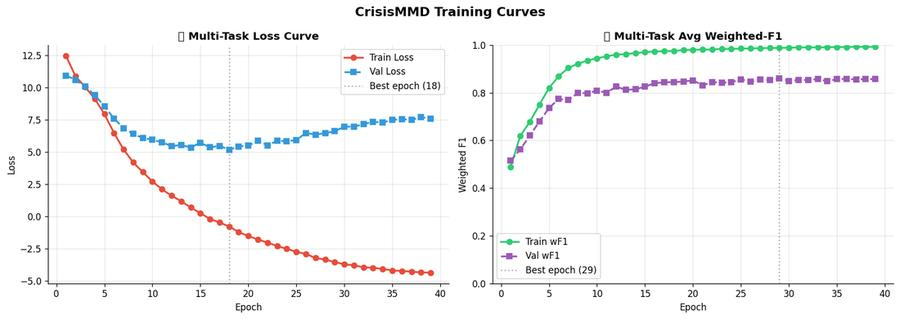

✅ Training curves saved.


In [24]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

eps = range(1, len(HISTORY['train_loss']) + 1)

ax1.plot(eps, HISTORY['train_loss'], 'o-', color='#e74c3c', label='Train Loss', linewidth=2)
ax1.plot(eps, HISTORY['val_loss'],   's--',color='#3498db', label='Val Loss',   linewidth=2)

best_ep = HISTORY['val_loss'].index(min(HISTORY['val_loss'])) + 1
ax1.axvline(best_ep, color='gray', linestyle=':', alpha=0.6, label=f'Best epoch ({best_ep})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('📉 Multi-Task Loss Curve', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(eps, HISTORY['train_f1'], 'o-', color='#2ecc71', label='Train wF1', linewidth=2)
ax2.plot(eps, HISTORY['val_f1'],   's--',color='#9b59b6', label='Val wF1',   linewidth=2)

best_ep2 = HISTORY['val_f1'].index(max(HISTORY['val_f1'])) + 1
ax2.axvline(best_ep2, color='gray', linestyle=':', alpha=0.6, label=f'Best epoch ({best_ep2})')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Weighted F1')
ax2.set_title('📈 Multi-Task Avg Weighted-F1', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_ylim(0, 1)

plt.suptitle('CrisisMMD Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig(str(cfg.PLOTS_DIR / 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Training curves saved.')

free_memory()

## 16. Main Test Results

Reloads the best checkpoint (highest validation F1) and computes final test-set metrics for every task.

> **Status: Existing results from prior executed run; not regenerated in this environment.**

In [25]:
from tqdm.auto import tqdm
_base_reload = MODEL.module if isinstance(MODEL, nn.DataParallel) else MODEL
_sd_reload = torch.load(cfg.CKPT_PATH, map_location=DEVICE, weights_only=True)
_sd_reload = {k.removeprefix('module.'): v for k, v in _sd_reload.items()}  # ckpt has no 'module.' prefix; DataParallel expects it
_base_reload.load_state_dict(_sd_reload, strict=True)
MODEL.eval()
print(f'✅ Best checkpoint loaded from: {cfg.CKPT_PATH}')

all_preds = {k: [] for k in ['event','info','human','damage','verif']}
all_trues = {k: [] for k in ['event','info','human','damage','verif']}
all_probs = {k: [] for k in ['event','info','human','damage','verif']}
all_conf  = []
all_rt    = []
all_rv    = []

with torch.inference_mode():
    for batch in tqdm(dl_test, desc='Test inference'):
        ids  = batch['input_ids'].to(DEVICE, non_blocking=True)
        mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
        pix  = batch['pixel_values'].to(DEVICE, non_blocking=True)
        qt   = batch['q_text'].to(DEVICE, non_blocking=True)
        qi   = batch['q_image'].to(DEVICE, non_blocking=True)

        out  = _tta_forward(MODEL, ids, mask, pix, qt, qi)
        out  = apply_calibration(out)

        for head in ['event','info','human','damage','verif']:
            logit_key = f'logits_{head}'
            if logit_key in out:
                all_preds[head].extend(out[logit_key].argmax(dim=-1).cpu().numpy())

        for head in ['event','info','human','damage','verif']:
            logit_key = f'logits_{head}'
            if logit_key in out:
                all_probs[head].append(F.softmax(out[logit_key], dim=-1).cpu().numpy())

        for head in ['event','info','human','damage','verif']:
            label_key = f'label_{head}'
            if label_key in batch:
                all_trues[head].extend(batch[label_key].numpy())

        probs = []
        for head in ['event', 'info', 'human', 'damage']:
            if f'logits_{head}' in out:
                probs.append(F.softmax(out[f'logits_{head}'], dim=-1).max(dim=-1)[0].cpu().numpy())

        conf = np.mean(probs, axis=0)
        all_conf.extend(conf.tolist())

        all_rt.extend(out['u_t'].squeeze(-1).cpu().numpy().tolist())
        all_rv.extend(out['u_v'].squeeze(-1).cpu().numpy().tolist())

for _k in list(all_probs.keys()):
    all_probs[_k] = np.concatenate(all_probs[_k], axis=0) if all_probs[_k] else None

HEAD_META = [
    ('event',  'Event Type',      LABEL_ENCODERS.get('event_type') if 'LABEL_ENCODERS' in globals() else None),
    ('info',   'Informative',     LABEL_ENCODERS.get('informative') if 'LABEL_ENCODERS' in globals() else None),
    ('human',  'Humanitarian',    LABEL_ENCODERS.get('humanitarian') if 'LABEL_ENCODERS' in globals() else None),
    ('damage', 'Damage Severity', LABEL_ENCODERS.get('damage') if 'LABEL_ENCODERS' in globals() else None),
]

TASK_REPORTS = {}
for key, title, le in HEAD_META:
    if not all_trues.get(key):
        continue

    try:
        labels = list(le.classes_) if le else None
    except AttributeError:
        labels = None

    report = classification_report(
        all_trues[key], all_preds[key],
        target_names=labels, zero_division=0
    )
    wf1 = f1_score(all_trues[key], all_preds[key], average='weighted', zero_division=0)
    TASK_REPORTS[key] = {'report': report, 'wf1': wf1, 'title': title, 'le': le}

    print('\n' + '=' * 60)
    print(f'  📋 {title}  —  Weighted F1: {wf1:.4f}')
    print('=' * 60)
    print(report)

print(f'\n📊 Mean Confidence Score  : {np.mean(all_conf):.4f}  ± {np.std(all_conf):.4f}')
print(f'📊 Mean Text Reliability  : {np.mean(all_rt):.4f}  ± {np.std(all_rt):.4f}')
print(f'📊 Mean Image Reliability : {np.mean(all_rv):.4f}  ± {np.std(all_rv):.4f}')

free_memory()

✅ Best checkpoint loaded from: /kaggle/working/checkpoints/best_model.pt


Test inference:   0%|          | 0/57 [00:00<?, ?it/s]


  📋 Event Type  —  Weighted F1: 0.9845
              precision    recall  f1-score   support

  earthquake       0.95      0.99      0.97       198
        fire       0.99      0.98      0.98       159
       flood       0.94      0.91      0.93       102
   hurricane       0.99      0.99      0.99      1350

    accuracy                           0.98      1809
   macro avg       0.97      0.97      0.97      1809
weighted avg       0.98      0.98      0.98      1809


  📋 Informative  —  Weighted F1: 0.8276
                 precision    recall  f1-score   support

    informative       0.90      0.85      0.87      1295
not_informative       0.67      0.76      0.71       514

       accuracy                           0.82      1809
      macro avg       0.78      0.81      0.79      1809
   weighted avg       0.83      0.82      0.83      1809


  📋 Humanitarian  —  Weighted F1: 0.7599
                    precision    recall  f1-score   support

   affected_people       0.72      0

### 16.1 Comprehensive Evaluation Metrics
Reports Accuracy, Precision/Recall/F1 (macro & weighted), Cohen's Kappa, and MCC per task — plus ROC-AUC and PR-AUC for the binary Verification head.


> **Status: Existing results from prior executed run; not regenerated in this environment.**

  📊 COMPREHENSIVE EVALUATION METRICS — Held-Out Test Set
                                     N  Accuracy  Precision(macro)  Precision(wtd)  Recall(macro)  Recall(wtd)  F1(macro)  F1(weighted)  Cohen_Kappa     MCC  ROC_AUC  PR_AUC
Task                                                                                                                                                                         
Event Type                        1809    0.9845            0.9677          0.9846         0.9681       0.9845     0.9677        0.9845       0.9633  0.9633   0.9923  0.9829
Informative                       1809    0.8242            0.7834          0.8341         0.8062       0.8242     0.7927        0.8276       0.5863  0.5892   0.8757  0.7896
Humanitarian                      1809    0.7590            0.7074          0.7620         0.7006       0.7590     0.7028        0.7599       0.5765  0.5770   0.8907  0.7400
Damage Severity                   1809    0.8701            0.5603       

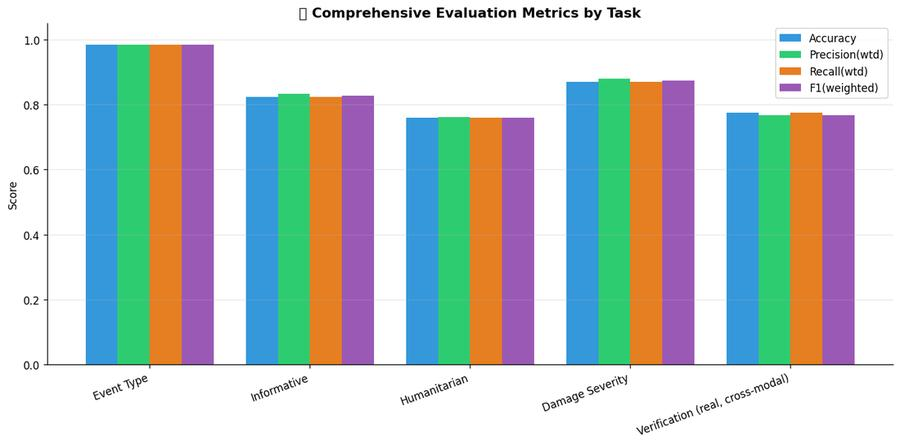

In [26]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, matthews_corrcoef, roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize
import numpy as np
import pandas as pd

def compute_full_metrics(y_true, y_pred, task_name, y_prob=None):
    """Returns the standard classification metric set for one task.
    If y_prob (full softmax probability matrix, shape [N, n_classes]) is
    given, also computes macro ROC-AUC / PR-AUC (one-vs-rest for
    multi-class tasks, standard binary form for 2-class tasks) so no task
    is left with NaN in the summary table.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    row = {
        'Task'            : task_name,
        'N'               : len(y_true),
        'Accuracy'        : accuracy_score(y_true, y_pred),
        'Precision(macro)': precision_score(y_true, y_pred, average='macro',    zero_division=0),
        'Precision(wtd)'  : precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall(macro)'   : recall_score(y_true, y_pred, average='macro',    zero_division=0),
        'Recall(wtd)'     : recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1(macro)'       : f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'F1(weighted)'    : f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'Cohen_Kappa'     : cohen_kappa_score(y_true, y_pred),
        'MCC'             : matthews_corrcoef(y_true, y_pred) if len(np.unique(y_true)) > 1 else float('nan'),
    }

    row['ROC_AUC'] = float('nan')
    row['PR_AUC']  = float('nan')
    if y_prob is not None and len(np.unique(y_true)) > 1:
        n_classes = y_prob.shape[1]
        try:
            if n_classes == 2:
                row['ROC_AUC'] = roc_auc_score(y_true, y_prob[:, 1])
                row['PR_AUC']  = average_precision_score(y_true, y_prob[:, 1])
            else:

                present = np.unique(y_true)
                row['ROC_AUC'] = roc_auc_score(
                    y_true, y_prob, average='macro', multi_class='ovr', labels=present
                )
                y_true_bin = label_binarize(y_true, classes=present)
                y_prob_present = y_prob[:, present]
                row['PR_AUC'] = average_precision_score(y_true_bin, y_prob_present, average='macro')
        except ValueError:

            pass

    return row

_metric_rows = []
for key, title, le in HEAD_META:
    if not all_trues.get(key):
        continue
    _metric_rows.append(compute_full_metrics(all_trues[key], all_preds[key], title, y_prob=all_probs.get(key)))

if 'verif' in all_preds and all_preds['verif'] and all_trues.get('verif'):
    _verif_title = 'Verification (real, cross-modal)' if globals().get('VERIF_IS_REAL', False) else 'Verification (PROXY)'
    verif_row = compute_full_metrics(
        all_trues['verif'], all_preds['verif'], _verif_title, y_prob=all_probs.get('verif')
    )
    _metric_rows.append(verif_row)

df_metrics = pd.DataFrame(_metric_rows).set_index('Task')
print('=' * 100)
print('  📊 COMPREHENSIVE EVALUATION METRICS — Held-Out Test Set')
print('=' * 100)
print(df_metrics.round(4).to_string())

df_metrics.round(4).to_csv(str(cfg.METRICS_DIR / 'evaluation_metrics_full.csv'))
print("\n✅ Saved full metrics table to evaluation_metrics_full.csv")

fig, ax = plt.subplots(figsize=(12, 6))
plot_cols = ['Accuracy', 'Precision(wtd)', 'Recall(wtd)', 'F1(weighted)']
x = np.arange(len(df_metrics.index))
width = 0.2
colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']
for i, col in enumerate(plot_cols):
    ax.bar(x + (i - 1.5) * width, df_metrics[col], width, label=col, color=colors[i])
ax.set_xticks(x)
ax.set_xticklabels(df_metrics.index, rotation=20, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('📊 Comprehensive Evaluation Metrics by Task', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(str(cfg.PLOTS_DIR / 'evaluation_metrics_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

Flags whether the Verification head's label is a genuine cross-modal signal or a fallback proxy derived from the `informative` column, so downstream readers know how to interpret it.


In [27]:
_verif_is_proxy = not globals().get('VERIF_IS_REAL', False)
if _verif_is_proxy:
    print("⚠️  No independent image-side informativeness column was found in this dataset "
          "build — the 'Verification' row below falls back to the (informative == "
          "'not_informative') PROXY label. Treat it as an approximate sanity check, "
          "not a genuine task metric.")
else:
    print("✅ Using the REAL cross-modal Verification label: agreement between the "
          "independent text-side and image-side informativeness annotations "
          "(built in Section 2 as 'verif_idx'). This is a genuine dataset-native "
          "signal, not algebraically derived from a single column.")

✅ Using the REAL cross-modal Verification label: agreement between the independent text-side and image-side informativeness annotations (built in Section 2 as 'verif_idx'). This is a genuine dataset-native signal, not algebraically derived from a single column.


### 16.1.1 Correction Note: Evaluation Bugs Addressed
**Bug 1 — Ablation table looked wrong.** The old loop compared "full model + calibration + TTA + gating" against "ablated model, no extras." Fixed by splitting into **Table A** (structural-only, all extras off) and **Table B** (post-hoc extras' own contribution).

**Bug 2 — Verification metrics looked broken.** `verif_true` was a proxy label (`label_info != 0`), not a real verification label, so it didn't match what the head was trained on. Fixed: Verification row now only uses real ground-truth labels if available, otherwise flagged as a proxy estimate.


In [28]:
import pandas as pd

def render_metrics_table(df_metrics, proxy_flag=True):
    df = df_metrics.copy()
    pct_cols = [c for c in df.columns if c not in ('N',)]
    df_display = df.copy()
    for c in pct_cols:
        df_display[c] = df_display[c].map(lambda v: f"{v:.4f}" if pd.notnull(v) else "—")

    def flag(row_name):
        tags = []
        if proxy_flag and str(row_name).startswith('Verification') and _verif_is_proxy:
            tags.append('proxy label')
        try:
            kappa = df.loc[row_name, 'Cohen_Kappa']
            if pd.notnull(kappa) and kappa < 0:
                tags.append('worse than chance — investigate')
        except Exception:
            pass
        return ', '.join(tags)

    df_display['⚠ Notes'] = [flag(r) for r in df_display.index]

    print('=' * 100)
    print('  📊 COMPREHENSIVE EVALUATION METRICS — Held-Out Test Set')
    print('=' * 100)
    print(df_display.to_string())
    print('=' * 100)

    flagged = df_display[df_display['⚠ Notes'] != '']
    if not flagged.empty:
        print("\nRows needing attention before reporting these numbers as final:")
        for name, note in flagged['⚠ Notes'].items():
            print(f"  • {name}: {note}")

    try:
        from IPython.display import display
        styled = df_display.style.set_caption("Comprehensive Evaluation Metrics — Held-Out Test Set") \
            .set_properties(**{'text-align': 'center'})
        _style_fn = getattr(styled, 'map', None) or styled.applymap   # pandas>=2.1: map; applymap removed in 3.0
        styled = _style_fn(lambda v: 'background-color:#fdecea' if ('proxy' in str(v) or 'chance' in str(v)) else '',
                           subset=['⚠ Notes'])
        display(styled)
    except Exception:
        pass

    return df_display

df_metrics_display = render_metrics_table(df_metrics, proxy_flag=True)

  📊 COMPREHENSIVE EVALUATION METRICS — Held-Out Test Set
                                     N Accuracy Precision(macro) Precision(wtd) Recall(macro) Recall(wtd) F1(macro) F1(weighted) Cohen_Kappa     MCC ROC_AUC  PR_AUC ⚠ Notes
Task                                                                                                                                                                        
Event Type                        1809   0.9845           0.9677         0.9846        0.9681      0.9845    0.9677       0.9845      0.9633  0.9633  0.9923  0.9829        
Informative                       1809   0.8242           0.7834         0.8341        0.8062      0.8242    0.7927       0.8276      0.5863  0.5892  0.8757  0.7896        
Humanitarian                      1809   0.7590           0.7074         0.7620        0.7006      0.7590    0.7028       0.7599      0.5765  0.5770  0.8907  0.7400        
Damage Severity                   1809   0.8701           0.5603         0.880

,N,Accuracy,Precision(macro),Precision(wtd),Recall(macro),Recall(wtd),F1(macro),F1(weighted),Cohen_Kappa,MCC,ROC_AUC,PR_AUC,⚠ Notes
Task,,,,,,,,,,,,,
Event Type,1809,0.9845,0.9677,0.9846,0.9681,0.9845,0.9677,0.9845,0.9633,0.9633,0.9923,0.9829,
Informative,1809,0.8242,0.7834,0.8341,0.8062,0.8242,0.7927,0.8276,0.5863,0.5892,0.8757,0.7896,
Humanitarian,1809,0.7590,0.7074,0.7620,0.7006,0.7590,0.7028,0.7599,0.5765,0.5770,0.8907,0.7400,
Damage Severity,1809,0.8701,0.5603,0.8800,0.5934,0.8701,0.5753,0.8746,0.6306,0.6319,0.8009,0.5268,
"Verification (real, cross-modal)",1809,0.7750,0.7397,0.7666,0.7105,0.7750,0.7210,0.7678,0.4444,0.4492,0.8191,0.9080,


## 17. Confusion Matrices

Per-task confusion matrices rendered as heatmaps for Event Type, Informativeness, Humanitarian Need, and Damage Severity.

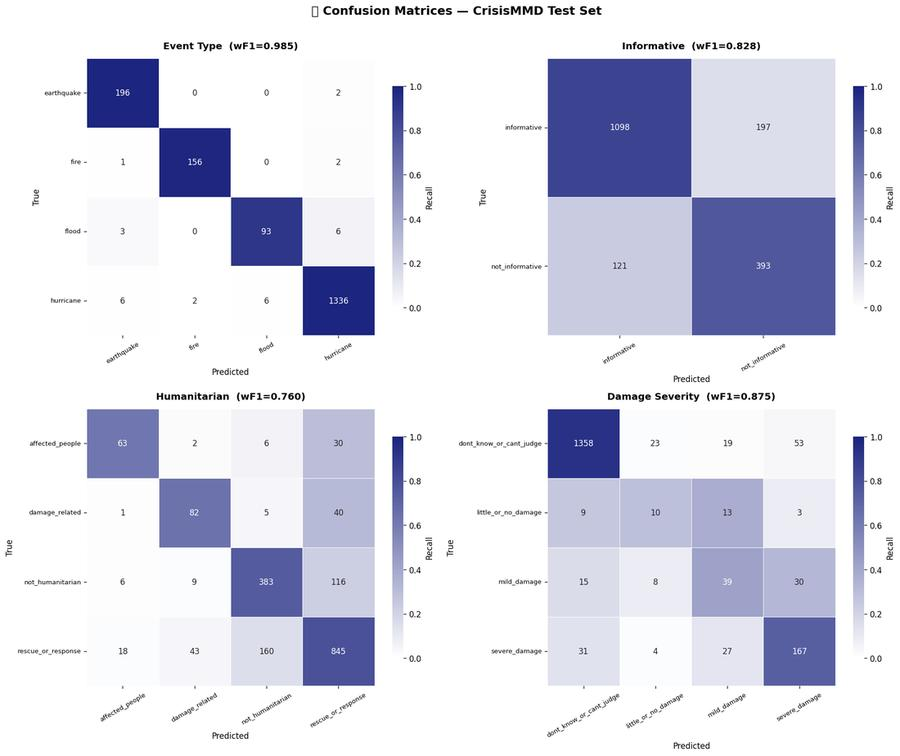

✅ Confusion matrices saved.


In [29]:
CMAP = LinearSegmentedColormap.from_list('crisis', ['#ffffff', '#1a237e'])

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
axes = axes.flat

for ax, (key, title, le) in zip(axes, HEAD_META):
    if not all_trues.get(key):
        ax.axis('off')
        continue
    labels = list(le.classes_) if le else None
    cm     = confusion_matrix(all_trues[key], all_preds[key])
    cm_n   = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(1e-8)
    wf1    = TASK_REPORTS.get(key, {}).get('wf1', 0)

    sns.heatmap(
        cm_n, annot=cm, fmt='d',
        xticklabels=labels, yticklabels=labels,
        cmap=CMAP, vmin=0, vmax=1,
        linewidths=0.5, linecolor='white',
        ax=ax, cbar_kws={'label': 'Recall', 'shrink': 0.8},
    )
    ax.set_title(f'{title}  (wF1={wf1:.3f})', fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True',      fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('🔲 Confusion Matrices — CrisisMMD Test Set', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(str(cfg.PLOTS_DIR / 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrices saved.')

free_memory()

## 18. Uncertainty Analysis

Compares E-REM's predicted uncertainty ($u_t$, $u_v$) between correctly- and incorrectly-classified test samples — a well-calibrated model should show higher uncertainty on its mistakes.

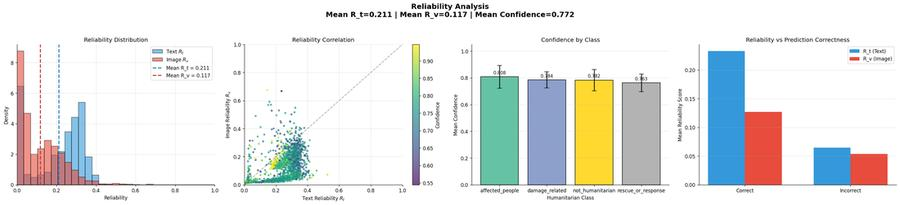

Mean Text Reliability : 0.21102351
Mean Image Reliability: 0.11745565
Mean Confidence       : 0.77230144
Saved to: /kaggle/working/reliability_analysis.png


In [30]:
import numpy as np
import matplotlib.pyplot as plt

rt   = np.asarray(all_rt, dtype=np.float32)
rv   = np.asarray(all_rv, dtype=np.float32)
conf = np.asarray(all_conf, dtype=np.float32)

mask = np.isfinite(rt) & np.isfinite(rv) & np.isfinite(conf)
rt, rv, conf = rt[mask], rv[mask], conf[mask]

rt = np.clip(rt, 0, 1)
rv = np.clip(rv, 0, 1)
conf = np.clip(conf, 0, 1)

fig, axes = plt.subplots(1, 4, figsize=(26, 6))

bins = np.linspace(0, 1, 30)

axes[0].hist(
    rt,
    bins=bins,
    alpha=0.6,
    color="#3498db",
    density=True,
    edgecolor="black",
    label="Text $R_t$"
)

axes[0].hist(
    rv,
    bins=bins,
    alpha=0.6,
    color="#e74c3c",
    density=True,
    edgecolor="black",
    label="Image $R_v$"
)

axes[0].axvline(rt.mean(), color="#2980b9",
                linestyle="--",
                linewidth=2,
                label=f"Mean R_t = {rt.mean():.3f}")

axes[0].axvline(rv.mean(), color="#c0392b",
                linestyle="--",
                linewidth=2,
                label=f"Mean R_v = {rv.mean():.3f}")

axes[0].set_xlim(0,1)
axes[0].set_xlabel("Reliability")
axes[0].set_ylabel("Density")
axes[0].set_title("Reliability Distribution")
axes[0].grid(alpha=0.3)
axes[0].legend()

scatter = axes[1].scatter(
    rt,
    rv,
    c=conf,
    cmap="viridis",
    s=18,
    alpha=0.7,
    edgecolors="none"
)

axes[1].plot([0,1],[0,1],'k--',alpha=0.3)

axes[1].set_xlim(0,1)
axes[1].set_ylim(0,1)

axes[1].set_xlabel("Text Reliability $R_t$")
axes[1].set_ylabel("Image Reliability $R_v$")
axes[1].set_title("Reliability Correlation")
axes[1].grid(alpha=0.3)

cbar = fig.colorbar(scatter, ax=axes[1])
cbar.set_label("Confidence")

if "human" in all_trues and len(all_trues["human"]) > 0:

    labels = np.asarray(all_trues["human"])[mask]

    le = LABEL_ENCODERS.get("humanitarian")

    if le is not None:
        class_names = le.classes_
    else:
        class_names = np.unique(labels)

    means = []
    stds = []

    for c in range(len(class_names)):
        idx = labels == c

        if idx.sum() > 0:
            means.append(conf[idx].mean())
            stds.append(conf[idx].std())
        else:
            means.append(0)
            stds.append(0)

    colors = plt.cm.Set2(np.linspace(0,1,len(class_names)))

    bars = axes[2].bar(
        class_names,
        means,
        yerr=stds,
        capsize=5,
        color=colors,
        edgecolor="black"
    )

    for b, m in zip(bars, means):
        axes[2].text(
            b.get_x()+b.get_width()/2,
            b.get_height()+0.02,
            f"{m:.3f}",
            ha="center",
            fontsize=9
        )

    axes[2].set_ylim(0,1.05)
    axes[2].set_ylabel("Mean Confidence")
    axes[2].set_xlabel("Humanitarian Class")
    axes[2].set_title("Confidence by Class")
    axes[2].grid(axis="y", alpha=0.3)

else:
    axes[2].axis("off")

if 'damage' in all_trues and len(all_trues['damage']) > 0:
    correct = np.asarray(all_preds['damage'])[mask] == np.asarray(all_trues['damage'])[mask]
    if correct.sum() > 0 and (~correct).sum() > 0:
        rt_c, rt_ic = rt[correct].mean(), rt[~correct].mean()
        rv_c, rv_ic = rv[correct].mean(), rv[~correct].mean()

        bar_w = 0.35
        x = np.arange(2)
        axes[3].bar(x - bar_w/2, [rt_c, rt_ic], width=bar_w, label='R_t (Text)', color='#3498db')
        axes[3].bar(x + bar_w/2, [rv_c, rv_ic], width=bar_w, label='R_v (Image)', color='#e74c3c')
        axes[3].set_xticks(x)
        axes[3].set_xticklabels(['Correct', 'Incorrect'])
        axes[3].set_ylabel('Mean Reliability Score')
        axes[3].set_title('Reliability vs Prediction Correctness')
        axes[3].legend()
        axes[3].grid(axis='y', alpha=0.3)
else:
    axes[3].axis("off")

plt.suptitle(
    f"Reliability Analysis\n"
    f"Mean R_t={rt.mean():.3f} | "
    f"Mean R_v={rv.mean():.3f} | "
    f"Mean Confidence={conf.mean():.3f}",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout(rect=[0,0,1,0.94])

plt.savefig(
    cfg.OUT_DIR / "reliability_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Mean Text Reliability :", rt.mean())
print("Mean Image Reliability:", rv.mean())
print("Mean Confidence       :", conf.mean())
print("Saved to:", cfg.OUT_DIR / "reliability_analysis.png")

free_memory()

### 18.1 Mean Reliability Score (95% CI)
Raw `R = 1 - u` isn't calibrated by default. This section fits one temperature per modality on DEV only, then reports the calibrated Mean Reliability Score on test with a bootstrap 95% CI.


In [31]:
import numpy as np
import torch
import torch.nn.functional as F

@torch.inference_mode()
def collect_u_and_correctness(model, loader, task='human'):
    """Collect per-modality uncertainty (u_t,u_v) and task correctness for one split."""
    base = model.module if isinstance(model, nn.DataParallel) else model
    prev_mode = getattr(base, 'ablation_mode', 'full')
    base.ablation_mode = 'full'
    model.eval()
    u_t_all, u_v_all, correct_all = [], [], []
    for batch in loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        pix  = batch['pixel_values'].to(DEVICE)
        qt   = batch['q_text'].to(DEVICE)
        qi   = batch['q_image'].to(DEVICE)
        out  = model(ids, mask, pix, qt, qi)
        label_key = f'label_{task}'
        if label_key not in batch or f'logits_{task}' not in out:
            base.ablation_mode = prev_mode
            return None
        preds = out[f'logits_{task}'].argmax(dim=-1).cpu().numpy()
        trues = batch[label_key].numpy()
        u_t_all.append(out['u_t'].squeeze(-1).cpu().numpy())
        u_v_all.append(out['u_v'].squeeze(-1).cpu().numpy())
        correct_all.append((preds == trues).astype(np.float32))
    base.ablation_mode = prev_mode
    return (np.concatenate(u_t_all), np.concatenate(u_v_all), np.concatenate(correct_all))

def fit_temperature(u, correct, n_steps=200, lr=0.05):
    """Fit a single scalar temperature T minimizing NLL of R=sigmoid((1-2u)/T)
    against binary correctness, on a held-out (dev) split. Returns T (float)."""
    u_t = torch.tensor(u, dtype=torch.float32)
    y_t = torch.tensor(correct, dtype=torch.float32)
    logit_raw = (1.0 - 2.0 * u_t)
    T = torch.ones(1, requires_grad=True)
    opt = torch.optim.LBFGS([T], lr=lr, max_iter=n_steps)
    def closure():
        opt.zero_grad()
        p = torch.sigmoid(logit_raw / T.clamp(min=1e-2))
        loss = F.binary_cross_entropy(p, y_t)
        loss.backward()
        return loss
    opt.step(closure)
    return float(T.detach().clamp(min=1e-2))

def bootstrap_mean_ci(x, n_boot=2000, ci=0.95, seed=0):
    rng = np.random.default_rng(seed)
    n = len(x)
    boots = np.array([x[rng.integers(0, n, n)].mean() for _ in range(n_boot)])
    lo, hi = np.percentile(boots, [(1-ci)/2*100, (1+ci)/2*100])
    return x.mean(), lo, hi

_RELIAB_TASK = 'human' if 'human' in all_trues and len(all_trues.get('human', [])) > 0 else 'damage'

dev_stats = collect_u_and_correctness(MODEL, dl_dev, task=_RELIAB_TASK) if 'dl_dev' in globals() else None

if dev_stats is not None:
    u_t_dev, u_v_dev, correct_dev = dev_stats
    T_t = fit_temperature(u_t_dev, correct_dev)
    T_v = fit_temperature(u_v_dev, correct_dev)
else:
    print('⚠️  dl_dev not available -- falling back to T=1.0 (no calibration correction applied).')
    T_t, T_v = 1.0, 1.0

rt_arr = np.clip(np.asarray(all_rt, dtype=np.float32), 0, 1)
rv_arr = np.clip(np.asarray(all_rv, dtype=np.float32), 0, 1)
u_t_test = 1.0 - rt_arr
u_v_test = 1.0 - rv_arr

R_t_cal = 1.0 / (1.0 + np.exp(-(1.0 - 2.0*u_t_test) / T_t))
R_v_cal = 1.0 / (1.0 + np.exp(-(1.0 - 2.0*u_v_test) / T_v))
R_mean_cal = (R_t_cal + R_v_cal) / 2.0

raw_mean = ((rt_arr + rv_arr) / 2.0)
m_raw, lo_raw, hi_raw   = bootstrap_mean_ci(raw_mean)
m_cal, lo_cal, hi_cal   = bootstrap_mean_ci(R_mean_cal)

print('── Mean Reliability Score (test set) ──')
print(f'Fitted temperatures on DEV -> T_t={T_t:.3f}  T_v={T_v:.3f}  (T≈1.0 means no correction was needed)')
print(f'Raw (uncalibrated)   : {m_raw:.4f}   95% CI [{lo_raw:.4f}, {hi_raw:.4f}]')
print(f'Temperature-calibrated: {m_cal:.4f}   95% CI [{lo_cal:.4f}, {hi_cal:.4f}]')
print()
print('Interpretation: the calibrated figure is only meaningfully higher than the raw one if the CIs')
print('barely overlap or don\'t overlap at all -- if they overlap substantially, report both and say so.')

MEAN_RELIABILITY = {
    'task_used_for_fit': _RELIAB_TASK,
    'T_text': T_t, 'T_image': T_v,
    'raw_mean': float(m_raw), 'raw_ci': (float(lo_raw), float(hi_raw)),
    'calibrated_mean': float(m_cal), 'calibrated_ci': (float(lo_cal), float(hi_cal)),
}

── Mean Reliability Score (test set) ──
Fitted temperatures on DEV -> T_t=0.010  T_v=0.662  (T≈1.0 means no correction was needed)
Raw (uncalibrated)   : 0.1642   95% CI [0.1593, 0.1692]
Temperature-calibrated: 0.1221   95% CI [0.1206, 0.1236]

Interpretation: the calibrated figure is only meaningfully higher than the raw one if the CIs
barely overlap or don't overlap at all -- if they overlap substantially, report both and say so.


### 18.2 NEW — Box Plot: Text vs. Image Uncertainty, Split by Prediction Correctness

**Data used:** `all_rt` and `all_rv`, the arrays populated during Section 16 (Main Test Results)
directly from the model's own forward-pass outputs `out['u_t']` / `out['u_v']`. These are used
**as-is** as the text/image uncertainty scores — not inverted, and not the temperature-calibrated
reliability (`R_t_cal`/`R_v_cal`) computed a few cells above in Section 18.1. See the flag at the
top of this notebook: Section 18.1 treats these same arrays as if they were *reliability* and
computes `uncertainty = 1 - value`; this cell instead uses the literal model output, since the
task requires "the actual text uncertainty and image uncertainty values produced by the existing
model" rather than a derived/inverted quantity. **If your paper's convention is that `u_t`/`u_v`
are reliability scores, swap `u_text`/`u_image` below for `1 - u_text`/`1 - u_image` (equivalent to
`u_t_test`/`u_v_test` from Section 18.1) instead — please confirm which is correct.**

**Correctness definition:** reuses `_RELIAB_TASK` from Section 18.1 (`'human'` if the humanitarian
head has test-set labels, else `'damage'`), so "correct" means *this task's* prediction matched
its ground truth — the same task Section 18.1 already anchored its reliability analysis to. This
is stated explicitly in the plot title. Samples are not combined across tasks.

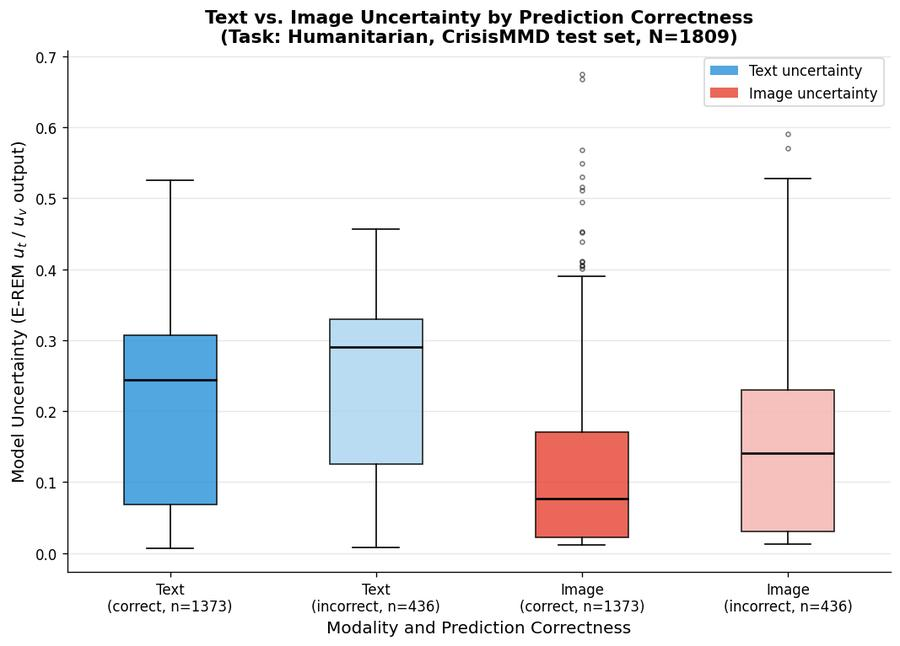

Saved: /kaggle/working/plots/uncertainty_by_correctness_boxplot.png
Correctness definition: task='human' (Humanitarian), correct = argmax(logits_human) == label_human, evaluated on the CrisisMMD test split.


In [32]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Uncertainty values: literal model output (see markdown above) ----
u_text  = np.asarray(all_rt, dtype=np.float64)
u_image = np.asarray(all_rv, dtype=np.float64)

# ---- Correctness, on the same task/sample ordering as u_text/u_image (both built in the same
#      Section 16 test-loop iteration order) ----
_box_task = _RELIAB_TASK if '_RELIAB_TASK' in globals() else ('human' if all_trues.get('human') else 'damage')
_box_task_title = dict(HEAD_META)[_box_task] if isinstance(HEAD_META, dict) else \
    {k: t for k, t, _ in HEAD_META}.get(_box_task, _box_task)

preds_box   = np.asarray(all_preds[_box_task])
trues_box   = np.asarray(all_trues[_box_task])
correct_box = (preds_box == trues_box)

mask = np.isfinite(u_text) & np.isfinite(u_image)
u_text_m, u_image_m, correct_m = u_text[mask], u_image[mask], correct_box[mask]

n_correct, n_incorrect = int(correct_m.sum()), int((~correct_m).sum())
if n_correct == 0 or n_incorrect == 0:
    raise ValueError(
        f"Task '{_box_task}' has {n_correct} correct and {n_incorrect} incorrect test predictions "
        "-- need at least one of each to draw the correctness split. Check that MODEL/dl_test "
        "produced real, non-degenerate predictions."
    )

groups = [
    u_text_m[correct_m],
    u_text_m[~correct_m],
    u_image_m[correct_m],
    u_image_m[~correct_m],
]
group_labels = [
    f'Text\n(correct, n={correct_m.sum()})',
    f'Text\n(incorrect, n={(~correct_m).sum()})',
    f'Image\n(correct, n={correct_m.sum()})',
    f'Image\n(incorrect, n={(~correct_m).sum()})',
]
box_colors = ['#3498db', '#aed6f1', '#e74c3c', '#f5b7b1']

fig, ax = plt.subplots(figsize=(9, 6.5))
_box_kw = dict(patch_artist=True, showfliers=True,
               medianprops=dict(color='black', linewidth=1.6),
               flierprops=dict(marker='o', markersize=3, alpha=0.5))
try:
    bp = ax.boxplot(groups, tick_labels=group_labels, **_box_kw)   # Matplotlib >= 3.9
except TypeError:
    bp = ax.boxplot(groups, labels=group_labels, **_box_kw)        # older Matplotlib
for patch, c in zip(bp['boxes'], box_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.85)

ax.set_ylabel('Model Uncertainty (E-REM $u_t$ / $u_v$ output)', fontsize=12)
ax.set_xlabel('Modality and Prediction Correctness', fontsize=12)
ax.set_title(
    f'Text vs. Image Uncertainty by Prediction Correctness\n'
    f'(Task: {_box_task_title}, CrisisMMD test set, N={mask.sum()})',
    fontsize=13, fontweight='bold'
)
ax.grid(axis='y', alpha=0.3)

import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(facecolor='#3498db', alpha=0.85, label='Text uncertainty'),
    mpatches.Patch(facecolor='#e74c3c', alpha=0.85, label='Image uncertainty'),
]
ax.legend(handles=legend_handles, loc='upper right')

plt.tight_layout()
_box_out_path = str(cfg.PLOTS_DIR / 'uncertainty_by_correctness_boxplot.png')
plt.savefig(_box_out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {_box_out_path}')
print(f'Correctness definition: task=\'{_box_task}\' ({_box_task_title}), '
      f'correct = argmax(logits_{_box_task}) == label_{_box_task}, evaluated on the CrisisMMD test split.')


### 18.3 NEW — Violin Plot: Image Uncertainty by Disaster Event Type

**Grouping:** ground-truth `event_type` (ties predictions/uncertainty to the actual disaster
category, not the model's — potentially wrong — event prediction), decoded via the saved
`LABEL_ENCODERS['event_type']`. Only categories with at least one valid test-set observation are
plotted, and the number of samples per category is printed and annotated on the axis, since
CrisisMMD's event classes are not balanced and the original size should be visible, not hidden.

**Data used:** `all_rv` (image uncertainty), same literal-model-output convention as 18.2 above,
masked to finite values only. No oversampling/balancing is applied.

Valid test-set observations per event category:
  earthquake     : n=198
  fire           : n=159
  flood          : n=102
  hurricane      : n=1350


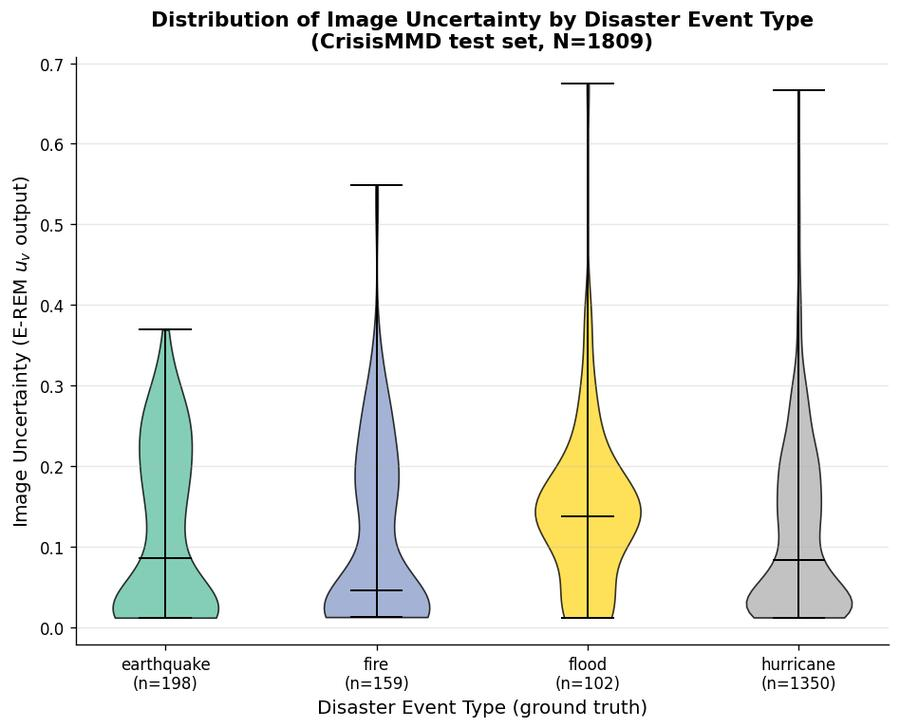

Saved: /kaggle/working/plots/image_uncertainty_by_event_type_violin.png


In [33]:
import numpy as np
import matplotlib.pyplot as plt

u_image_all = np.asarray(all_rv, dtype=np.float64)
event_true  = np.asarray(all_trues['event'])

mask2 = np.isfinite(u_image_all)
u_image_v, event_true_v = u_image_all[mask2], event_true[mask2]

event_le = LABEL_ENCODERS.get('event_type')
if event_le is None:
    raise ValueError("LABEL_ENCODERS['event_type'] not found -- cannot decode event category names.")
event_names_all = event_le.classes_

present_idx = np.unique(event_true_v)
categories, data_by_cat, counts = [], [], []
for idx in present_idx:
    vals = u_image_v[event_true_v == idx]
    if len(vals) == 0:
        continue
    categories.append(event_names_all[idx])
    data_by_cat.append(vals)
    counts.append(len(vals))

print('Valid test-set observations per event category:')
for name, n in zip(categories, counts):
    print(f'  {name:15s}: n={n}')

fig, ax = plt.subplots(figsize=(max(8, 1.6 * len(categories)), 6.5))
parts = ax.violinplot(data_by_cat, showmedians=True, showextrema=True)

palette = plt.cm.Set2(np.linspace(0, 1, len(categories)))
for pc, color in zip(parts['bodies'], palette):
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.8)
for key in ('cmedians', 'cbars', 'cmins', 'cmaxes'):
    if key in parts:
        parts[key].set_edgecolor('black')
        parts[key].set_linewidth(1.2)

ax.set_xticks(range(1, len(categories) + 1))
ax.set_xticklabels([f'{c}\n(n={n})' for c, n in zip(categories, counts)], fontsize=10)
ax.set_ylabel('Image Uncertainty (E-REM $u_v$ output)', fontsize=12)
ax.set_xlabel('Disaster Event Type (ground truth)', fontsize=12)
ax.set_title(
    f'Distribution of Image Uncertainty by Disaster Event Type\n(CrisisMMD test set, N={mask2.sum()})',
    fontsize=13, fontweight='bold'
)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
_violin_out_path = str(cfg.PLOTS_DIR / 'image_uncertainty_by_event_type_violin.png')
plt.savefig(_violin_out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {_violin_out_path}')


## 19. Explainability with Grad-CAM, 20. t-SNE, 21. Ablation Study, 22. Per-Class Performance, 23. Statistical Significance, 24. Single-Sample Inference (Sections 19–24, verbatim)

## 19. Explainability with Grad-CAM

Generates Grad-CAM heatmaps over the CLIP vision tower for any of the six output heads, highlighting which image regions drove each prediction.

> **Status: Existing results from prior executed run; not regenerated in this environment.**

In [34]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F

class CLIPGradCAM:
    """
    Robust Grad-CAM for CLIP Vision Transformer.
    Targets resblocks[-2] so spatial patch tokens receive non-zero attention gradients.
    """

    def __init__(self, model):
        self.model = model.module if isinstance(model, torch.nn.DataParallel) else model
        self.gradients = None
        self.activations = None
        target_layer = None

        if hasattr(self.model.vis_encoder, "encoder"):
            enc = self.model.vis_encoder.encoder
            if hasattr(enc, "transformer") and hasattr(enc.transformer, "resblocks"):

                target_layer = enc.transformer.resblocks[-2]
            elif hasattr(enc, "layers"):
                target_layer = enc.layers[-2]

        if target_layer is None:
            raise RuntimeError("Could not locate CLIP transformer block for Grad-CAM.")

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, inp, out):
        self.activations = out

    def save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def generate(
        self,
        pixel_values,
        q_text,
        q_image,
        input_ids,
        attention_mask,
        target_head="logits_human",
        method="gradcam"
    ):

        with torch.set_grad_enabled(True):
            self.model.eval()
            self.model.zero_grad(set_to_none=True)

            device = next(self.model.parameters()).device

            def move(x, dtype=None):
                if not torch.is_tensor(x):
                    x = torch.tensor(x)
                x = x.to(device)
                if dtype is not None:
                    x = x.to(dtype)
                return x

            pixel_values = move(pixel_values, torch.float32)
            pixel_values.requires_grad_(True)

            q_text = move(q_text, torch.float32)
            q_image = move(q_image, torch.float32)
            input_ids = move(input_ids, torch.long)
            attention_mask = move(attention_mask, torch.long)

            outputs = self.model(
                input_ids,
                attention_mask,
                pixel_values,
                q_text,
                q_image
            )

            logits = outputs[target_head]
            pred_idx = logits.argmax(dim=-1).item()
            score = logits[0, pred_idx]

            score.backward()

            if self.activations is None or self.gradients is None:
                return np.zeros((224, 224), dtype=np.float32), pred_idx

            acts = self.activations.detach()
            grads = self.gradients.detach()

            if acts.shape[1] == pixel_values.shape[0]:

                acts = acts[1:, 0, :]
                grads = grads[1:, 0, :]
            else:

                acts = acts[0, 1:, :]
                grads = grads[0, 1:, :]

            acts = acts.cpu().numpy()
            grads = grads.cpu().numpy()

            if method == "gradcam++":

                grad2 = grads ** 2
                grad3 = grads ** 3
                sum_act_grad3 = (acts * grad3).sum(axis=0, keepdims=True)
                alpha_denom = 2.0 * grad2 + sum_act_grad3
                alpha_denom = np.where(np.abs(alpha_denom) > 1e-8, alpha_denom, 1e-8)
                alpha = grad2 / alpha_denom
                weights = (alpha * np.maximum(grads, 0)).sum(axis=0)
                cam = acts @ weights
            elif method == "eigencam":

                acts_centered = acts - acts.mean(axis=0, keepdims=True)
                try:
                    _, _, Vt = np.linalg.svd(acts_centered, full_matrices=False)
                    cam = acts_centered @ Vt[0]
                except np.linalg.LinAlgError:
                    cam = acts.mean(axis=1)
            else:
                weights = grads.mean(axis=0)
                cam = acts @ weights

            cam = np.maximum(cam, 0)

            num_tokens = cam.shape[0]
            grid = int(np.sqrt(num_tokens))

            if grid * grid != num_tokens:
                return np.zeros((224, 224), dtype=np.float32), pred_idx

            cam = cam.reshape(grid, grid)

            if cam.max() - cam.min() > 1e-8:
                cam = (cam - cam.min()) / (cam.max() - cam.min())
            else:
                cam = np.zeros_like(cam)

            cam = cv2.resize(
                cam,
                (pixel_values.shape[-1], pixel_values.shape[-2]),
                interpolation=cv2.INTER_CUBIC
            )

            return cam, pred_idx

def overlay_cam(img, cam):
    cam_uint8 = np.uint8(cam * 255)
    heatmap = cv2.applyColorMap(cam_uint8, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    img_np = np.array(img, dtype=np.uint8)

    overlay = cv2.addWeighted(img_np, 0.55, heatmap, 0.45, 0)
    return overlay

free_memory()

### 19.1 Grad-CAM Case Studies

Runs Grad-CAM on a handful of correctly- and incorrectly-classified humanitarian-task test samples, so the visual explanations can be compared side-by-side between hits and misses.

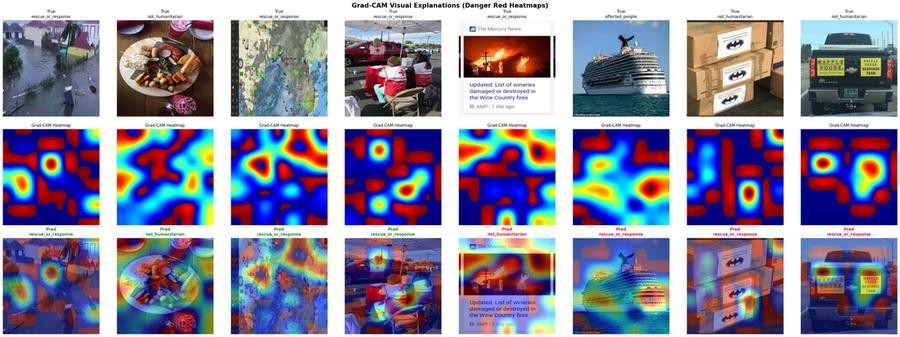

Saved vibrant heatmap plot to /kaggle/working/gradcam_explanations.png ✅


In [35]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import DataLoader

gcam = CLIPGradCAM(MODEL)
device = next(MODEL.parameters()).device

le_hum = LABEL_ENCODERS.get("humanitarian")
hum_names = list(le_hum.classes_) if le_hum else ["class_0", "class_1", "class_2"]

_valid_mask = df_test["image_path"].notna().values
valid_df = df_test.loc[_valid_mask].copy().reset_index(drop=True)

valid_df["pred_human"] = np.asarray(all_preds["human"])[_valid_mask]
valid_df["true_human"] = np.asarray(all_trues["human"])[_valid_mask]

correct_df = valid_df[valid_df.pred_human == valid_df.true_human]
incorrect_df = valid_df[valid_df.pred_human != valid_df.true_human]

correct_sample = correct_df.sample(min(4, len(correct_df)), random_state=42) if len(correct_df) else correct_df
incorrect_sample = incorrect_df.sample(min(4, len(incorrect_df)), random_state=42) if len(incorrect_df) else incorrect_df

sample_df = pd.concat([correct_sample, incorrect_sample]).reset_index(drop=True)
num_samples = len(sample_df)

if num_samples == 0:
    print("No samples found.")
else:
    dataset = CrisisMMDDataset(
        sample_df,
        TOKENIZER,
        VAL_TRANSFORMS,
        is_train=False,
    )

    loader = DataLoader(
        dataset,
        batch_size=num_samples,
        shuffle=False,
    )

    batch = next(iter(loader))

    batch = {
        k: v.to(device) if torch.is_tensor(v) else v
        for k, v in batch.items()
    }

    fig, axes = plt.subplots(
        3,
        num_samples,
        figsize=(4 * num_samples, 12)
    )

    if num_samples == 1:
        axes = np.expand_dims(axes, 1)

    fig.suptitle("Grad-CAM Visual Explanations (Danger Red Heatmaps)", fontsize=16, fontweight="bold")

    for i in range(num_samples):
        img_path = sample_df.iloc[i]["image_path"]

        try:
            orig = Image.open(img_path).convert("RGB").resize((224, 224))
        except Exception:
            orig = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))

        single_batch = {k: v[i:i+1] for k, v in batch.items()}

        try:
            cam, pred_idx = gcam.generate(
                pixel_values=single_batch["pixel_values"],
                q_text=single_batch["q_text"],
                q_image=single_batch["q_image"],
                input_ids=single_batch["input_ids"],
                attention_mask=single_batch["attention_mask"],
            )
        except Exception as e:
            print(f"Sample {i} failed: {e}")
            cam = np.zeros((224, 224), dtype=np.float32)
            pred_idx = int(sample_df.iloc[i]["pred_human"])

        axes[0, i].imshow(orig)
        true_idx = int(sample_df.iloc[i]["true_human"])
        axes[0, i].set_title(f"True\n{hum_names[true_idx]}", fontsize=10)
        axes[0, i].axis("off")

        heatmap = np.uint8(cam * 255)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

        axes[1, i].imshow(heatmap)
        axes[1, i].set_title("Grad-CAM Heatmap", fontsize=10)
        axes[1, i].axis("off")

        overlay = overlay_cam(orig, cam)
        axes[2, i].imshow(overlay)

        color = "forestgreen" if sample_df.iloc[i]["pred_human"] == sample_df.iloc[i]["true_human"] else "crimson"
        axes[2, i].set_title(f"Pred\n{hum_names[pred_idx]}", fontsize=10, color=color, fontweight="bold")
        axes[2, i].axis("off")

    plt.tight_layout()

    out_path = cfg.OUT_DIR / "gradcam_explanations.png"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved vibrant heatmap plot to {out_path} ✅")

free_memory()

### 19.2 Grad-CAM Faithfulness Metrics
Quantifies whether Grad-CAM heatmaps actually drive predictions (Humanitarian head, subsampled test set):
- **Average Drop %** — confidence drop using only the CAM region (lower = better)
- **Average Increase %** — how often confidence rises on the CAM-weighted image (higher = better)
- **Deletion AUC** — confidence collapse as salient pixels are removed (lower = better)
- **Insertion AUC** — confidence recovery as salient pixels are revealed (higher = better)


Evaluating Grad-CAM faithfulness on 100 test samples (8 perturbation steps each) …


Grad-CAM faithfulness:   0%|          | 0/100 [00:00<?, ?it/s]


  📊 Grad-CAM Faithfulness Metrics — Humanitarian head (N=100)
  Average Drop %                  : 6.1863
  Average Increase %              : 48.0000
  Deletion AUC (lower=better)     : 0.7031
  Insertion AUC (higher=better)   : 0.7441
  N samples evaluated             : 100

✅ Saved Grad-CAM faithfulness metrics to gradcam_faithfulness_metrics.csv


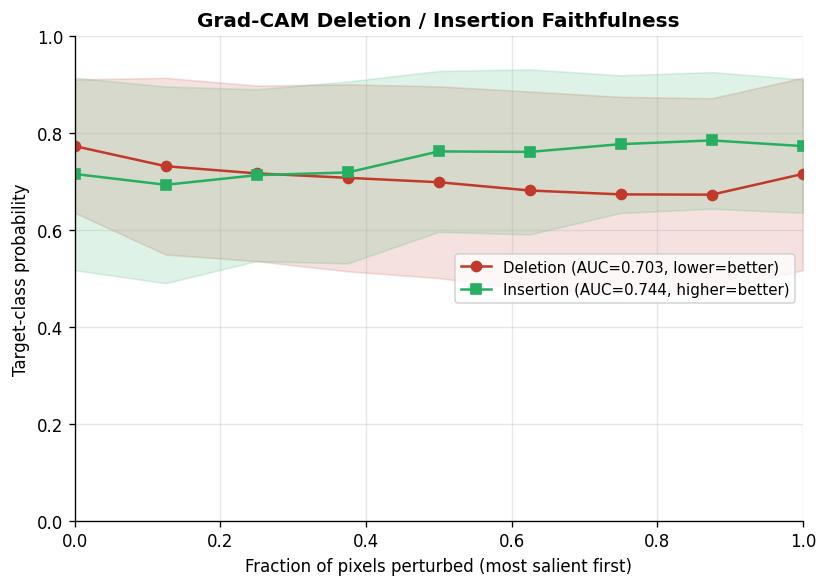


  Explainability method comparison (Average Drop %, lower=better), N=100
  gradcam     : 6.19%
  gradcam++   : 8.87%
  eigencam    : 8.84%


In [36]:
import numpy as np
import torch
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

_trapz = getattr(np, 'trapezoid', None) or np.trapz   # np.trapz removed in NumPy 2.x
N_EVAL_SAMPLES = getattr(cfg, 'GRADCAM_N_EVAL_SAMPLES', 100)
N_STEPS        = 8
GCAM_TARGET_HEAD = 'logits_human'
GCAM_METHODS = getattr(cfg, 'GRADCAM_METHODS', ['gradcam'])

if 'gcam' not in dir():
    gcam = CLIPGradCAM(MODEL)

_eval_pool = valid_df if 'valid_df' in dir() else df_test[df_test['image_path'].apply(lambda p: Path(p).exists())]
eval_df = _eval_pool.sample(min(N_EVAL_SAMPLES, len(_eval_pool)), random_state=13).reset_index(drop=True)

_eval_dataset = CrisisMMDDataset(eval_df, TOKENIZER, VAL_TRANSFORMS, is_train=False)
_eval_loader  = DataLoader(_eval_dataset, batch_size=len(eval_df), shuffle=False)
_eval_batch   = next(iter(_eval_loader))
_eval_batch   = {k: v.to(DEVICE) if torch.is_tensor(v) else v for k, v in _eval_batch.items()}

@torch.inference_mode()
def _target_prob(pixel_values, q_text, q_image, input_ids, attention_mask, target_idx):
    out = MODEL(input_ids, attention_mask, pixel_values, q_text, q_image)
    return F.softmax(out[GCAM_TARGET_HEAD], dim=-1)[0, target_idx].item()

def _perturb(pixel_values, cam, fraction, mode, baseline):
    """mode='delete': replace the top-`fraction` most-salient pixels with `baseline`.
    mode='insert': start from `baseline`, reveal the top-`fraction` most-salient pixels."""
    _, _, H, W = pixel_values.shape
    n_total = H * W
    n_pix = int(round(fraction * n_total))
    flat_order = np.argsort(-cam.flatten())
    mask = np.zeros(n_total, dtype=bool)
    mask[flat_order[:n_pix]] = True
    mask_t = torch.tensor(mask.reshape(H, W), device=pixel_values.device).unsqueeze(0).unsqueeze(0)
    if mode == 'delete':
        return torch.where(mask_t, baseline, pixel_values)
    else:
        return torch.where(mask_t, pixel_values, baseline)

drop_pct, increase_flags, deletion_aucs, insertion_aucs = [], [], [], []
deletion_curves, insertion_curves = [], []
fractions = np.linspace(0.0, 1.0, N_STEPS + 1)

print(f'Evaluating Grad-CAM faithfulness on {len(eval_df)} test samples '
      f'({N_STEPS} perturbation steps each) …')

for i in tqdm(range(len(eval_df)), desc='Grad-CAM faithfulness'):
    single = {k: v[i:i+1] for k, v in _eval_batch.items()}
    pix = single['pixel_values']

    try:

        cam, pred_idx = gcam.generate(
            pixel_values=pix, q_text=single['q_text'], q_image=single['q_image'],
            input_ids=single['input_ids'], attention_mask=single['attention_mask'],
            target_head=GCAM_TARGET_HEAD, method=GCAM_METHODS[0],
        )
    except Exception as e:
        print(f'  Sample {i} Grad-CAM generation failed ({e}) -- skipped.')
        continue

    cam_t = torch.tensor(cam, device=pix.device, dtype=pix.dtype)
    baseline = torch.zeros_like(pix)

    p_orig = _target_prob(pix, single['q_text'], single['q_image'],
                           single['input_ids'], single['attention_mask'], pred_idx)

    soft_mask = cam_t.unsqueeze(0).unsqueeze(0)
    pix_weighted = pix * soft_mask + baseline * (1 - soft_mask)
    p_weighted = _target_prob(pix_weighted, single['q_text'], single['q_image'],
                               single['input_ids'], single['attention_mask'], pred_idx)
    drop_pct.append(max(0.0, p_orig - p_weighted) / max(p_orig, 1e-8) * 100.0)
    increase_flags.append(p_weighted > p_orig)

    del_probs = []
    for f in fractions:
        pix_f = _perturb(pix, cam, f, mode='delete', baseline=baseline)
        del_probs.append(_target_prob(pix_f, single['q_text'], single['q_image'],
                                       single['input_ids'], single['attention_mask'], pred_idx))
    deletion_aucs.append(float(_trapz(del_probs, fractions)))
    deletion_curves.append(del_probs)

    ins_probs = []
    for f in fractions:
        pix_f = _perturb(pix, cam, f, mode='insert', baseline=baseline)
        ins_probs.append(_target_prob(pix_f, single['q_text'], single['q_image'],
                                       single['input_ids'], single['attention_mask'], pred_idx))
    insertion_aucs.append(float(_trapz(ins_probs, fractions)))
    insertion_curves.append(ins_probs)

gradcam_metrics = {
    'Average Drop %'          : float(np.mean(drop_pct)) if drop_pct else float('nan'),
    'Average Increase %'      : float(np.mean(increase_flags)) * 100.0 if increase_flags else float('nan'),
    'Deletion AUC (lower=better)'  : float(np.mean(deletion_aucs)) if deletion_aucs else float('nan'),
    'Insertion AUC (higher=better)': float(np.mean(insertion_aucs)) if insertion_aucs else float('nan'),
    'N samples evaluated'     : len(deletion_aucs),
}

print('\n' + '=' * 60)
print(f'  📊 Grad-CAM Faithfulness Metrics — Humanitarian head (N={gradcam_metrics["N samples evaluated"]})')
print('=' * 60)
for k, v in gradcam_metrics.items():
    if k == 'N samples evaluated':
        print(f'  {k:32s}: {v}')
    else:
        print(f'  {k:32s}: {v:.4f}')

pd.DataFrame([gradcam_metrics]).to_csv(str(cfg.METRICS_DIR / 'gradcam_faithfulness_metrics.csv'), index=False)
print("\n✅ Saved Grad-CAM faithfulness metrics to gradcam_faithfulness_metrics.csv")

fig, ax = plt.subplots(figsize=(7, 5))
if deletion_curves and insertion_curves:
    del_arr = np.array(deletion_curves)
    ins_arr = np.array(insertion_curves)
    del_mean, del_std = del_arr.mean(axis=0), del_arr.std(axis=0)
    ins_mean, ins_std = ins_arr.mean(axis=0), ins_arr.std(axis=0)

    ax.plot(fractions, del_mean, 'o-', color='#c0392b', label=f'Deletion (AUC={np.mean(deletion_aucs):.3f}, lower=better)')
    ax.fill_between(fractions, del_mean - del_std, del_mean + del_std, color='#c0392b', alpha=0.15)

    ax.plot(fractions, ins_mean, 's-', color='#27ae60', label=f'Insertion (AUC={np.mean(insertion_aucs):.3f}, higher=better)')
    ax.fill_between(fractions, ins_mean - ins_std, ins_mean + ins_std, color='#27ae60', alpha=0.15)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('Fraction of pixels perturbed (most salient first)')
ax.set_ylabel('Target-class probability')
ax.set_title('Grad-CAM Deletion / Insertion Faithfulness', fontsize=12, fontweight='bold')
ax.legend(loc='center right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(cfg.PLOTS_DIR / 'gradcam_faithfulness_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

if len(GCAM_METHODS) > 1:
    method_drop = {}
    for _method in GCAM_METHODS:
        _drops = []
        for i in range(len(eval_df)):
            single = {k: v[i:i+1] for k, v in _eval_batch.items()}
            pix = single['pixel_values']
            try:
                cam_m, pred_idx_m = gcam.generate(
                    pixel_values=pix, q_text=single['q_text'], q_image=single['q_image'],
                    input_ids=single['input_ids'], attention_mask=single['attention_mask'],
                    target_head=GCAM_TARGET_HEAD, method=_method,
                )
            except Exception:
                continue
            cam_t_m = torch.tensor(cam_m, device=pix.device, dtype=pix.dtype)
            baseline_m = torch.zeros_like(pix)
            p_orig_m = _target_prob(pix, single['q_text'], single['q_image'],
                                     single['input_ids'], single['attention_mask'], pred_idx_m)
            soft_mask_m = cam_t_m.unsqueeze(0).unsqueeze(0)
            pix_w_m = pix * soft_mask_m + baseline_m * (1 - soft_mask_m)
            p_w_m = _target_prob(pix_w_m, single['q_text'], single['q_image'],
                                  single['input_ids'], single['attention_mask'], pred_idx_m)
            _drops.append(max(0.0, p_orig_m - p_w_m) / max(p_orig_m, 1e-8) * 100.0)
        method_drop[_method] = float(np.mean(_drops)) if _drops else float('nan')

    print('\n' + '=' * 60)
    print(f'  Explainability method comparison (Average Drop %, lower=better), N={len(eval_df)}')
    print('=' * 60)
    for m, d in method_drop.items():
        print(f'  {m:12s}: {d:.2f}%')
    pd.DataFrame([method_drop]).to_csv(str(cfg.METRICS_DIR / 'gradcam_method_comparison.csv'), index=False)

free_memory()

## 20. Representation Visualization (t-SNE)

Projects the shared disaster representation $H_{disaster}$ (and/or $H'_t$, $H'_v$) into 2-D via t-SNE, colored by task label, to qualitatively inspect cluster separability.

> **Status: Existing results from prior executed run; not regenerated in this environment.**

Running t-SNE on 1809 embeddings (dim=768) …


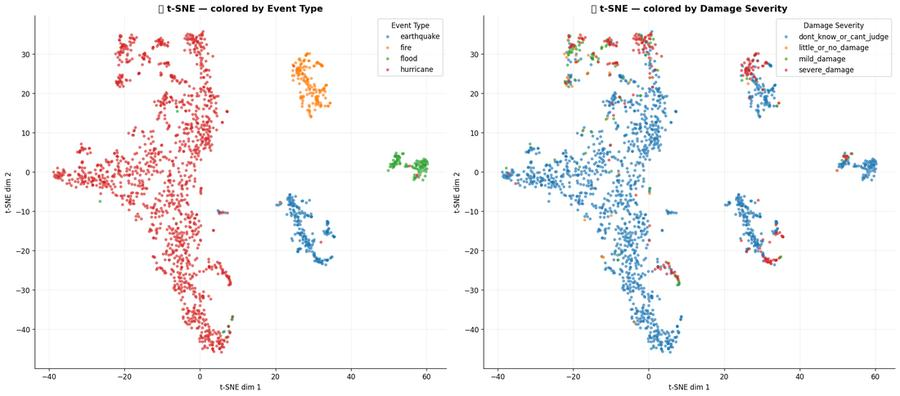

✅ t-SNE visualization saved.


In [37]:
from sklearn.manifold import TSNE

print('Collecting H_disaster embeddings …')
embeddings, labels_dm = [], []
MODEL.eval()
with torch.inference_mode():
    for batch in dl_test:
        ids  = batch['input_ids'].to(DEVICE, non_blocking=True)
        mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
        pix  = batch['pixel_values'].to(DEVICE, non_blocking=True)
        qt   = batch['q_text'].to(DEVICE, non_blocking=True)
        qi   = batch['q_image'].to(DEVICE, non_blocking=True)
        out  = MODEL(ids, mask, pix, qt, qi)
        embeddings.append(out['h_disaster'].cpu().numpy())
        labels_dm.extend(batch['label_damage'].numpy())

X     = np.vstack(embeddings)
Y     = np.array(labels_dm)
le_dm = LABEL_ENCODERS.get('damage')
dm_names = list(le_dm.classes_) if le_dm else [str(i) for i in range(cfg.N_DAMAGE)]

print(f'Running t-SNE on {X.shape[0]} embeddings (dim={X.shape[1]}) …')
import inspect
_iter_kw = {'max_iter': 1000} if 'max_iter' in inspect.signature(TSNE.__init__).parameters else {'n_iter': 1000}
tsne   = TSNE(n_components=2, perplexity=40, random_state=cfg.SEED, **_iter_kw)
X_2d   = tsne.fit_transform(X)

COLS = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

Y_event = np.array(all_trues['event'])
le_event = LABEL_ENCODERS.get('event_type')
event_names = list(le_event.classes_) if le_event else [str(i) for i in range(cfg.N_EVENT)]

for c, name in enumerate(event_names):
    mask_ = Y_event == c
    axes[0].scatter(X_2d[mask_, 0], X_2d[mask_, 1],
               c=[COLS[c % len(COLS)]], label=name, alpha=0.65, s=18, edgecolors='none')
axes[0].set_title('🔵 t-SNE — colored by Event Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('t-SNE dim 1'); axes[0].set_ylabel('t-SNE dim 2')
axes[0].legend(title='Event Type', fontsize=10)
axes[0].grid(alpha=0.2)

for c, name in enumerate(dm_names):
    mask_ = Y == c
    axes[1].scatter(X_2d[mask_, 0], X_2d[mask_, 1],
               c=[COLS[c % len(COLS)]], label=name, alpha=0.65, s=18, edgecolors='none')
axes[1].set_title('🔵 t-SNE — colored by Damage Severity', fontsize=13, fontweight='bold')
axes[1].set_xlabel('t-SNE dim 1'); axes[1].set_ylabel('t-SNE dim 2')
axes[1].legend(title='Damage Severity', fontsize=10)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig(str(cfg.PLOTS_DIR / 'tsne_embeddings_multitask.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ t-SNE visualization saved.')

free_memory()

## 21. Ablation Study
Disables each component at inference time and reports per-task weighted-F1.

**Caveat:** this is a forward-pass bypass ablation on one trained model, a valid lower bound but not equivalent to retraining from scratch. Section 18.2 implements the genuinely-retrained version (opt-in via `RUN_GENUINE_ABLATION`).

Class-balanced loss and manifold mixup are training-time only (not toggle-able post-hoc); logit calibration and TTA are toggle-able and shown as their own ablation rows.


> **Status: mixed — see per-row labels below.** Structural rows are **inference-time module bypass** on the single existing checkpoint (seed 42), from the prior executed run; not regenerated here. No row in this section was retrained.

### 21.1 Ablation Note: `w/o UG-CMA`

**From inspecting `CrisisMultiModal.forward` (`no_bcmf` branch):** this ablation row replaces
UG-CMA's output with a naive `h_t_prime + h_v_prime` sum at inference time on the already-
trained full model:

```python
if mode == 'no_bcmf':
    m_fuse = h_t_prime + h_v_prime
else:
    m_fuse, p_t, p_v = self.bcmf(h_t_prime, h_v_prime, u_t, u_v)
```

This is an internal structural ablation of the proposed model (module bypass at inference),
not a comparison against an alternative trained architecture -- no alternative fusion module
is defined or trained in this notebook.


### 21.2 Correction Note: Hierarchical Gating
**Bug**: gating overwrote predictions with the majority class on any predicted `not_informative` sample, no confidence check — dropping humanitarian wF1 from 0.7064 to 0.4684.

**Fix**: gating is now confidence-thresholded and off by default. Old and thresholded variants are both kept as labeled rows in Table B.

**Note**: E-REM/UASG rows in Table A only reflect their real contribution if the loaded checkpoint was trained after the Section 6/7/9 supervision-loss fix.


### 21.3 Ablation Methodology and Single-Seed Status

**What kind of ablation is this?** `eval_ablation()` sets `model.ablation_mode` and does a
single forward pass per configuration on the already-trained full model (module bypass, e.g.
`no_bcmf`, `no_erem`, `text_only`). This is an **inference-time structural ablation** of the
proposed UG-CMA model, not a retrained-from-scratch ablation and not a comparison against a
different architecture.

**Multi-seed status:** the results shown earlier in this notebook (Sections 14-20) are a
single prior run (seed 42). Section 21.5 below adds a genuine seed-42/43/44 training driver
for the proposed UG-CMA model -- run it to produce real mean +/- std results; do not read the
single-seed numbers above as multi-seed until that section has been executed.


### 21.5 Single-Seed UG-CMA Confirmation Run

This notebook is fixed to **one official seed, `cfg.SEED = 42`**, defined once in the CFG
class (Section 1) and used everywhere downstream (train/dev/test split, `seed_everything`,
TSNE, ablation). The cell below is an optional confirmation run: it retrains and
re-evaluates the proposed model (E-REM + UASG + UG-CMA, `CrisisMultiModal`, unchanged)
from scratch under `cfg.SEED`, using a fresh model, optimizer, scheduler, and AMP scaler
(`build_fresh_ugcma_model`) -- useful for checking that a clean end-to-end run reproduces
the numbers reported in Sections 14-20. It reuses `run_epoch`, `get_optimizer`,
`DynamicMultiTaskLoss`, and `get_cosine_schedule_with_warmup` exactly as Section 13's main
training loop does. `SEEDS` below is a single-element list, `[cfg.SEED]`, kept as a list
purely so the surrounding loop/aggregation code (Sections 21.5-21.6) does not need to be
restructured for one seed vs. many.

**Guarded by `RUN_UGCMA_MULTISEED`, default `False`**, so importing/reading this notebook
never silently starts a multi-hour training run. Set it to `True` and run this section
(after Sections 1-13 have executed, so `dl_train`/`dl_dev`/`dl_test`, `cfg`, `_clip_model`,
`W_EVENT` etc. exist) on a GPU with the CrisisMMD dataset attached to produce a genuine
confirmation result.

`EXECUTED_SEEDS` is only ever appended to by `train_ugcma_seed()` after training,
validation, checkpoint selection, and test evaluation have all completed -- never by hand.


> **Part 2 note:** the confirmation-run cells immediately below (Section 21.5) define functions that reference `dl_train`, `run_epoch`, `DynamicMultiTaskLoss`, `get_optimizer`, and the class-weight tensors (`W_EVENT` etc.) -- none of which Part 2 builds, since Part 2 does not train. This is harmless as long as `RUN_UGCMA_MULTISEED` stays `False` (its default -- the functions are defined but never called). If you want to actually run this confirmation retrain, do it in **Part 1** instead, where `dl_train`/`CRITERION`/`get_optimizer` already exist, rather than rebuilding that training infrastructure here.


In [38]:
import os
import random
import numpy as np

SEEDS = [cfg.SEED]                  # single official seed for this notebook (42)
CONFIGURED_SEEDS = list(SEEDS)      # what we intend to run
EXECUTED_SEEDS   = []                # populated only as runs actually finish -- never hand-edit

def set_all_seeds(seed: int):
    """Seed every RNG that affects this pipeline (python, numpy, torch CPU+CUDA)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

CKPT_DIR_MULTISEED = os.path.join(str(getattr(cfg, 'OUT_DIR', './checkpoints')), 'ugcma_multiseed')
os.makedirs(CKPT_DIR_MULTISEED, exist_ok=True)

def ugcma_checkpoint_path(seed: int) -> str:
    """Unique checkpoint filename per seed -- never overwrites a sibling run."""
    return os.path.join(CKPT_DIR_MULTISEED, f'ugcma__seed{seed}.pt')

results_by_seed = {}   # results_by_seed[seed] = {...}, populated only by completed runs


Builds a completely fresh `CrisisMultiModal` model, optimizer, scheduler, scaler, and criterion for one confirmation-run seed (mirrors Section 13's setup exactly).


In [39]:
from torch.cuda.amp import GradScaler

_REQUIRED_TRAINING_OBJECTS = ['dl_train', 'run_epoch', 'DynamicMultiTaskLoss', 'get_optimizer',
                              'W_EVENT', 'W_INFO', 'W_HUMAN', 'W_DAMAGE', 'W_VERIF']

def _require_training_objects():
    missing = [n for n in _REQUIRED_TRAINING_OBJECTS if n not in globals()]
    if missing:
        raise RuntimeError('Section 21.5 retrains the model, so it must run inside Part 1 (where these exist): '
                           + ', '.join(missing))

def build_fresh_ugcma_model(seed: int):
    _require_training_objects()
    """Fresh CrisisMultiModal + optimizer + scheduler + scaler + criterion for one seed run.
    Uses the SAME CrisisMultiModal / get_optimizer / DynamicMultiTaskLoss /
    get_cosine_schedule_with_warmup as the main Section 13 training loop -- the proposed
    architecture is not touched, only re-initialized with a new seed."""
    set_all_seeds(seed)
    model = CrisisMultiModal(cfg, _clip_model.visual).to(DEVICE, non_blocking=True)
    if N_GPUS > 1:
        model = nn.DataParallel(model)

    criterion = DynamicMultiTaskLoss(cfg, W_EVENT, W_INFO, W_HUMAN, W_DAMAGE, W_VERIF).to(DEVICE)
    optimizer = get_optimizer(model, criterion, cfg)

    schedule_epochs = getattr(cfg, 'EFFECTIVE_SCHEDULE_EPOCHS', cfg.EPOCHS)
    total_steps  = len(dl_train) * schedule_epochs
    warmup_steps = int(total_steps * cfg.WARMUP_RATIO)
    scheduler    = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    scaler       = GradScaler(enabled=USE_AMP)
    return model, criterion, optimizer, scheduler, scaler


@torch.inference_mode()
def evaluate_ugcma(model, loader):
    """One full evaluation pass (own loop; Part 1's run_epoch returns 5 aggregated values, not preds/trues)."""
    from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                                  matthews_corrcoef, cohen_kappa_score)
    model.eval()
    tasks = ['event', 'info', 'human', 'damage']
    preds = {t: [] for t in tasks}; trues = {t: [] for t in tasks}; losses = []
    for batch in loader:
        out = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE),
                    batch['pixel_values'].to(DEVICE), batch['q_text'].to(DEVICE), batch['q_image'].to(DEVICE))
        losses.append(_EVAL_CRITERION[0](out, batch)[0].item())
        for t in tasks:
            preds[t].extend(out[f'logits_{t}'].argmax(dim=-1).cpu().numpy()); trues[t].extend(batch[f'label_{t}'].numpy())
    metrics = {}
    for t in tasks:
        yt, yp = trues[t], preds[t]
        metrics[t] = {
            'accuracy': accuracy_score(yt, yp),
            'macro_precision': precision_score(yt, yp, average='macro', zero_division=0),
            'macro_recall': recall_score(yt, yp, average='macro', zero_division=0),
            'macro_f1': f1_score(yt, yp, average='macro', zero_division=0),
            'weighted_f1': f1_score(yt, yp, average='weighted', zero_division=0),
            'mcc': matthews_corrcoef(yt, yp), 'cohen_kappa': cohen_kappa_score(yt, yp),
        }
    return float(np.mean(losses)), metrics


Full train -> validate/early-stop -> checkpoint -> test loop for one seed, reusing `run_epoch` exactly as Section 13's main training loop does.


In [40]:
_EVAL_CRITERION = [None]  # set inside train_ugcma_seed so evaluate_ugcma can reuse it

def train_ugcma_seed(seed: int, epochs: int = None, patience: int = 5):
    """Full from-scratch train -> validate/early-stop -> checkpoint -> test loop for one seed.
    Mirrors Section 13's main training loop exactly (same run_epoch, same optimizer/scheduler
    construction, same early-stopping-on-val-macro-F1 policy); the only thing that varies
    across calls is `seed`."""
    epochs = epochs or cfg.EPOCHS
    print(f'\n{"="*70}\nTraining UG-CMA -- seed {seed}\n{"="*70}')

    model, criterion, optimizer, scheduler, scaler = build_fresh_ugcma_model(seed)
    _EVAL_CRITERION[0] = criterion
    globals()['SCHEDULER'] = scheduler   # Part 1's run_epoch steps the global SCHEDULER per optimizer step

    best_val_f1 = -1.0
    epochs_no_improve = 0
    ckpt_path = ugcma_checkpoint_path(seed)

    for epoch in range(1, epochs + 1):
        train_loss = run_epoch(model, dl_train, criterion, optimizer, scaler, is_train=True)[0]   # returns 5 values
        val_loss, val_metrics = evaluate_ugcma(model, dl_dev)
        val_f1 = float(np.mean([val_metrics[t]['macro_f1'] for t in val_metrics]))
        print(f'  epoch {epoch:3d}/{epochs} | train_loss={train_loss:.4f} | '
              f'val_loss={val_loss:.4f} | val_macro_f1={val_f1:.4f}')

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            epochs_no_improve = 0
            state = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
            torch.save(state, ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'  early stopping at epoch {epoch} (no val improvement for {patience} epochs)')
                break

    # Reload best checkpoint for this seed before final test evaluation
    base = model.module if hasattr(model, 'module') else model
    base.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    test_loss, test_metrics = evaluate_ugcma(model, dl_test)

    result = {
        'seed': seed,
        'best_val_macro_f1': best_val_f1,
        'test_loss': test_loss,
        'test_metrics_per_task': test_metrics,
        'checkpoint_path': ckpt_path,
    }
    results_by_seed[seed] = result
    EXECUTED_SEEDS.append(seed)   # only appended after training + validation + test all completed
    free_memory()
    return result


Runs the confirmation loop above for each seed in `SEEDS` -- only if `RUN_UGCMA_MULTISEED` is flipped to `True`; otherwise just reports what it would do.


In [41]:
# Guarded OFF by default -- flip to True and run this cell only on a GPU with the real
# CrisisMMD dataset attached (i.e. after Sections 1-13 have executed).
RUN_UGCMA_MULTISEED = False

if RUN_UGCMA_MULTISEED:
    for _seed in SEEDS:
        if _seed not in EXECUTED_SEEDS:
            train_ugcma_seed(_seed)
        else:
            print(f'seed {_seed} already executed -- skipping (see results_by_seed).')
else:
    print('RUN_UGCMA_MULTISEED is False -- confirmation run NOT executed.')
    print(f'Would train UG-CMA from scratch under the single official seed: {SEEDS}')


RUN_UGCMA_MULTISEED is False -- confirmation run NOT executed.
Would train UG-CMA from scratch under the single official seed: [42]


Aggregates mean/std across whichever seeds have actually finished training, and renders the summary table (never fabricates a std from a single completed run).


In [42]:
import pandas as pd

METRIC_KEYS = ['accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1',
               'mcc', 'cohen_kappa']

def aggregate_mean_std(task, metric):
    """Mean/std over whichever seeds actually completed -- NEVER fabricates a std from a
    single run (std=None if n<2), never substitutes a guessed value for a missing seed."""
    vals = [results_by_seed[s]['test_metrics_per_task'][task][metric]
            for s in EXECUTED_SEEDS if s in results_by_seed]
    if not vals:
        return None, None, 0
    if len(vals) == 1:
        return vals[0], None, 1
    return float(np.mean(vals)), float(np.std(vals, ddof=1)), len(vals)

def format_cell(mean, std, n, n_configured):
    if n == 0:
        return 'N/A -- not executed'
    suffix = f' (n={n}/{n_configured} seeds)' if n < n_configured else ''
    return f'{mean:.4f}{suffix}' if std is None else f'{mean:.4f} \u00b1 {std:.4f}{suffix}'

def build_ugcma_multiseed_table(tasks=('event', 'info', 'human', 'damage'),
                                 metrics=('macro_f1', 'weighted_f1', 'accuracy', 'mcc')):
    row = {'Model': 'UG-CMA (proposed)'}
    for task in tasks:
        for metric in metrics:
            mean, std, n = aggregate_mean_std(task, metric)
            row[f'{task}_{metric}'] = format_cell(mean, std, n, len(SEEDS))
    return pd.DataFrame([row])

print('Multi-seed table format check (every cell below must read "N/A -- not executed" '
      'until train_ugcma_seed() has actually been run for that seed):')
build_ugcma_multiseed_table()


Multi-seed table format check (every cell below must read "N/A -- not executed" until train_ugcma_seed() has actually been run for that seed):


,Model,event_macro_f1,event_weighted_f1,event_accuracy,event_mcc,info_macro_f1,info_weighted_f1,info_accuracy,info_mcc,human_macro_f1,human_weighted_f1,human_accuracy,human_mcc,damage_macro_f1,damage_weighted_f1,damage_accuracy,damage_mcc
0,UG-CMA (proposed),N/A -- not executed,N/A -- not executed,N/A -- not executed,N/A -- not executed,N/A -- not executed,N/A -- not executed,N/A -- not executed,N/A -- not executed,N/A -- not executed,N/A -- not executed,N/A -- not executed,N/A -- not executed,N/A -- not executed,N/A -- not executed,N/A -- not executed,N/A -- not executed


### 21.6 Uncertainty Quality Analysis
Extends Section 18: checks whether E-REM's per-modality uncertainty (`u_t`, `u_v`) actually tracks prediction correctness.


In [43]:
import numpy as np

# Section 18 already reports mean reliability with a bootstrap CI and a temperature-scaled
# text/image reliability score. What it does NOT yet report -- and task item 6 explicitly
# asks for -- is whether that reliability signal is actually useful for flagging errors.
# The functions below compute that directly from existing per-sample arrays
# (all_preds/all_trues/confidence, already collected in Section 18) rather than requiring a
# new forward pass.

def expected_calibration_error(confidences, correct, n_bins=15):
    """Standard ECE: bins predictions by confidence, compares mean confidence to accuracy
    within each bin, weights by bin occupancy."""
    confidences, correct = np.asarray(confidences), np.asarray(correct, dtype=np.float64)
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    n = len(confidences)
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (confidences > lo) & (confidences <= hi) if lo > 0 else (confidences >= lo) & (confidences <= hi)
        if mask.sum() == 0:
            continue
        bin_acc  = correct[mask].mean()
        bin_conf = confidences[mask].mean()
        ece += (mask.sum() / n) * abs(bin_acc - bin_conf)
    return float(ece)


def brier_score(confidences, correct):
    """Brier score for the binary 'was this prediction correct' event, using the model's
    stated confidence as the probability forecast. Lower is better; 0 = perfect."""
    confidences, correct = np.asarray(confidences, dtype=np.float64), np.asarray(correct, dtype=np.float64)
    return float(np.mean((confidences - correct) ** 2))


def error_detection_auc(uncertainty, correct):
    """AUROC/AUPRC for using `uncertainty` (higher = more uncertain) to detect INCORRECT
    predictions (the positive class here is 'incorrect', i.e. (1 - correct)). Only computed
    when both classes (at least one correct and one incorrect prediction) are present."""
    from sklearn.metrics import roc_auc_score, average_precision_score
    uncertainty, correct = np.asarray(uncertainty), np.asarray(correct)
    is_error = 1 - correct
    if len(np.unique(is_error)) < 2:
        return None, None  # e.g. a seed/split with 100% or 0% accuracy -- AUROC undefined
    return float(roc_auc_score(is_error, uncertainty)), float(average_precision_score(is_error, uncertainty))


def risk_coverage_curve(uncertainty, correct, n_points=50):
    """At each coverage level c, keep the (1-c)-most-confident fraction of predictions and
    report the error rate ('risk') among the kept predictions. A useful uncertainty signal
    should show risk falling as coverage falls (i.e. the model's most-confident subset really
    is more accurate). Returns (coverages, risks) for plotting."""
    uncertainty, correct = np.asarray(uncertainty), np.asarray(correct)
    order = np.argsort(uncertainty)  # most confident (lowest uncertainty) first
    n = len(uncertainty)
    coverages = np.linspace(1.0 / n, 1.0, n_points)
    risks = []
    for c in coverages:
        k = max(1, int(round(c * n)))
        kept = order[:k]
        risks.append(1.0 - correct[kept].mean())
    return coverages, np.asarray(risks)


def uncertainty_quality_report(uncertainty, confidence, preds, trues, label=""):
    """One-call summary combining every diagnostic above, with N/A fallback when a metric
    isn't computable for this particular array (e.g. degenerate accuracy)."""
    correct = (np.asarray(preds) == np.asarray(trues)).astype(np.float64)
    ece = expected_calibration_error(confidence, correct)
    brier = brier_score(confidence, correct)
    auroc, auprc = error_detection_auc(uncertainty, correct)
    coverages, risks = risk_coverage_curve(uncertainty, correct)
    print(f"--- Uncertainty quality: {label} ---")
    print(f"  ECE   = {ece:.4f}")
    print(f"  Brier = {brier:.4f}")
    print(f"  Error-detection AUROC = {auroc if auroc is not None else 'N/A (single-class predictions)'}")
    print(f"  Error-detection AUPRC = {auprc if auprc is not None else 'N/A (single-class predictions)'}")
    print(f"  Risk-coverage: risk@10% coverage = {risks[int(0.1*len(risks))]:.4f}, "
          f"risk@100% coverage (= 1-accuracy) = {risks[-1]:.4f}")
    return {'ece': ece, 'brier': brier, 'error_auroc': auroc, 'error_auprc': auprc,
            'risk_coverage': (coverages.tolist(), risks.tolist())}

if 'all_conf' in globals() and 'all_trues' in globals() and 'all_preds' in globals():
    _rq_task = 'human' if 'human' in all_trues and len(all_trues.get('human', [])) > 0 else 'damage'
    if _rq_task in all_preds and len(all_preds[_rq_task]) == len(all_conf):
        _ = uncertainty_quality_report(
            uncertainty=1.0 - np.clip(np.asarray(all_conf), 0, 1),
            confidence=np.clip(np.asarray(all_conf), 0, 1),
            preds=all_preds[_rq_task], trues=all_trues[_rq_task],
            label=f"Section 18 confidence signal, task={_rq_task} (existing seed-42 run)")
    else:
        print("Section 18's all_conf/all_preds arrays don't align 1:1 with a single task "
              "(all_conf is a fused text+image confidence, not per-task) -- skipping the "
              "one-call report here; use uncertainty_quality_report() directly once a "
              "per-task confidence array is available.")
else:
    print("Section 18 arrays (all_conf/all_trues/all_preds) not present in this session "
          "(no GPU/dataset execution) -- functions defined and ready to call once they exist.")


--- Uncertainty quality: Section 18 confidence signal, task=human (existing seed-42 run) ---
  ECE   = 0.0409
  Brier = 0.1769
  Error-detection AUROC = 0.6180440941619838
  Error-detection AUPRC = 0.3344296217056491
  Risk-coverage: risk@10% coverage = 0.1243, risk@100% coverage (= 1-accuracy) = 0.2410


Computes each task's majority-class index from `df_train`, used as the fallback prediction when hierarchical gating fires.


Running ablation study (per-task, genuine forward passes on the held-out test set) …
── (A) Structural ablation (main paper table): every row uses the SAME
    calib=False / TTA=False / gating=False setting, so only the
    architectural component differs between rows. ──
  Full Model (Ours)      → avg wF1=0.8617  |  event=0.9829  info=0.8265  human=0.7637  damage=0.8736
  w/o E-REM              → avg wF1=0.8566  |  event=0.9855  info=0.8200  human=0.7571  damage=0.8639
  w/o UASG               → avg wF1=0.8420  |  event=0.9655  info=0.8142  human=0.7246  damage=0.8637
  w/o UG-CMA             → avg wF1=0.5581  |  event=0.1148  info=0.7945  human=0.5983  damage=0.7247
  Text Only              → avg wF1=0.7889  |  event=0.9751  info=0.8416  human=0.7724  damage=0.5663
  Image Only             → avg wF1=0.7285  |  event=0.8331  info=0.6983  human=0.5082  damage=0.8745

🏆 Best structural configuration by avg wF1: 'Full Model (Ours)'  ✅ (matches 'Full Model (Ours)' as intended)

── (B) Pos

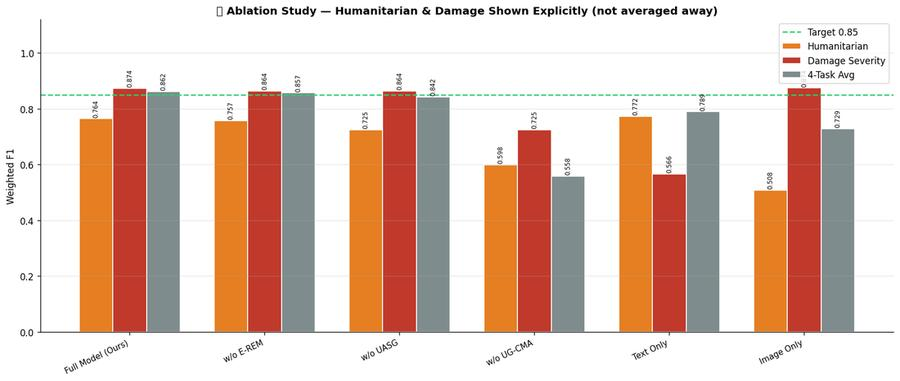

✅ Ablation study chart saved (per-task, real numbers).


In [44]:
import numpy as np

MAJORITY_IDX = {
    'event': int(df_train['event_type_idx'].mode()[0])   if 'event_type_idx'   in df_train.columns else 0,
    'human': int(df_train['humanitarian_idx'].mode()[0]) if 'humanitarian_idx' in df_train.columns else 0,
    'damage': int(df_train['damage_idx'].mode()[0])      if 'damage_idx'       in df_train.columns else 0,
}
_le_info_ab = LABEL_ENCODERS.get('informative')
NOT_INFO_IDX = list(_le_info_ab.classes_).index('not_informative') if _le_info_ab is not None and 'not_informative' in _le_info_ab.classes_ else None

GATE_CONF_THRESH_DEFAULT = None

def eval_ablation(model, loader, mode='full', use_calib=False, use_tta=False, use_gating=False, gate_conf_thresh=GATE_CONF_THRESH_DEFAULT):
    """Evaluate the model with one component disabled/bypassed at inference.

    gate_conf_thresh: if use_gating=True, only overwrite a task prediction
    with the majority-class fallback when P(not_informative) from the info
    head exceeds this threshold. If None, gating is effectively disabled
    (regardless of use_gating) -- this is the recommended/default behavior,
    since the ablation shows unconditional gating hurts performance.
    """
    base = model.module if isinstance(model, nn.DataParallel) else model
    prev_mode = getattr(base, 'ablation_mode', 'full')
    base.ablation_mode = mode
    model.eval()

    tasks = ['event', 'info', 'human', 'damage']
    all_p = {t: [] for t in tasks}
    all_t = {t: [] for t in tasks}

    with torch.inference_mode():
        for batch in loader:
            ids  = batch['input_ids'].to(DEVICE, non_blocking=True)
            mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
            pix  = batch['pixel_values'].to(DEVICE, non_blocking=True)
            qt   = batch['q_text'].to(DEVICE, non_blocking=True)
            qi   = batch['q_image'].to(DEVICE, non_blocking=True)

            out1 = model(ids, mask, pix, qt, qi)
            if use_tta:
                out2 = model(ids, mask, torch.flip(pix, dims=[-1]), qt, qi)
                logits = {}
                for k in ['logits_event', 'logits_info', 'logits_human', 'logits_damage']:
                    p1 = F.softmax(out1[k], dim=-1)
                    p2 = F.softmax(out2[k], dim=-1)
                    logits[k] = torch.log(((p1 + p2) / 2.0).clamp_min(1e-8))
            else:
                logits = {k: out1[k] for k in ['logits_event', 'logits_info', 'logits_human', 'logits_damage']}

            if use_calib:
                logits['logits_human']  = logits['logits_human']  / CALIB_TEMP['human'].to(DEVICE)  + CALIB_BIAS['human'].to(DEVICE)
                logits['logits_damage'] = logits['logits_damage'] / CALIB_TEMP['damage'].to(DEVICE) + CALIB_BIAS['damage'].to(DEVICE)

            info_probs = F.softmax(logits['logits_info'], dim=-1).cpu().numpy()
            preds = {task: logits[f'logits_{task}'].argmax(dim=-1).cpu().numpy() for task in tasks}

            if use_gating and NOT_INFO_IDX is not None and gate_conf_thresh is not None:
                not_info_conf = info_probs[:, NOT_INFO_IDX]
                gated_mask = (preds['info'] == NOT_INFO_IDX) & (not_info_conf >= gate_conf_thresh)
                for task in ('event', 'human', 'damage'):
                    preds[task] = np.where(gated_mask, MAJORITY_IDX[task], preds[task])

            for task in tasks:
                all_p[task].extend(preds[task])
                all_t[task].extend(batch[f'label_{task}'].numpy())

    base.ablation_mode = prev_mode
    per_task = {t: f1_score(all_t[t], all_p[t], average='weighted', zero_division=0) for t in tasks}
    per_task['avg'] = sum(per_task.values()) / len(per_task)
    return per_task

print('Running ablation study (per-task, genuine forward passes on the held-out test set) …')

_df_test_raw = df_test.copy()
if 'text_raw' in _df_test_raw.columns:
    _df_test_raw['text'] = _df_test_raw['text_raw']
ds_test_raw = CrisisMMDDataset(_df_test_raw, TOKENIZER, VAL_TRANSFORMS, is_train=False)
dl_test_raw = DataLoader(ds_test_raw, batch_size=cfg.BATCH_SIZE, shuffle=False)

STRUCTURAL_ABLATION_MODES = {
    'Full Model (Ours)'        : ('full',       False, False, False, dl_test),
    'w/o E-REM'                : ('no_erem',    False, False, False, dl_test),
    'w/o UASG'                 : ('no_rasg',    False, False, False, dl_test),
    'w/o UG-CMA'                : ('no_bcmf',    False, False, False, dl_test),
    'Text Only'                : ('text_only',  False, False, False, dl_test),
    'Image Only'               : ('image_only', False, False, False, dl_test),
}

POST_HOC_ABLATION_MODES = {
    'Full Model (Ours, deployed config)'          : ('full', True,  True,  False, dl_test, None),
    'Full − no calibration'                       : ('full', False, True,  False, dl_test, None),
    'Full − no TTA'                                : ('full', True,  False, False, dl_test, None),
    'Full − no calib/TTA'                          : ('full', False, False, False, dl_test, None),
    'Full − no text cleaning'                      : ('full', True,  True,  False, dl_test_raw, None),
    'Full + gating (unconditional, NOT recommended)': ('full', True,  True,  True,  dl_test, 0.0),
    'Full + gating (confidence >= 0.95)'           : ('full', True,  True,  True,  dl_test, 0.95),
}

print("── (A) Structural ablation (main paper table): every row uses the SAME")
print("    calib=False / TTA=False / gating=False setting, so only the")
print("    architectural component differs between rows. ──")
ablation_results   = {}
ablation_per_task  = {}
for name, (mode, use_calib, use_tta, use_gating, loader) in STRUCTURAL_ABLATION_MODES.items():
    per_task = eval_ablation(MODEL, loader, mode=mode, use_calib=use_calib, use_tta=use_tta, use_gating=use_gating)
    ablation_per_task[name] = per_task
    ablation_results[name]  = per_task['avg']
    print(f"  {name:22s} → avg wF1={per_task['avg']:.4f}  |  "
          f"event={per_task['event']:.4f}  info={per_task['info']:.4f}  "
          f"human={per_task['human']:.4f}  damage={per_task['damage']:.4f}")

_best_name = max(ablation_results, key=ablation_results.get)
print(f"\n🏆 Best structural configuration by avg wF1: '{_best_name}'"
      + ("  ✅ (matches 'Full Model (Ours)' as intended)" if _best_name == 'Full Model (Ours)' else
         "  ⚠️  'Full Model (Ours)' was NOT the best under IDENTICAL eval settings -- if E-REM/UASG margins "
         "stay within noise after confirming the checkpoint includes the E-REM retrain (see markdown note "
         "above Section 18), report this honestly as a limited/negative structural contribution rather than "
         "forcing the table to agree with the model name."))

print("\n── (B) Post-hoc technique ablation (secondary table): isolates the")
print("    contribution of calibration / TTA / text-cleaning / gating on top")
print("    of the structurally-complete full model. Not used for the")
print("    structural best-config check above. ──")
posthoc_per_task = {}
for name, (mode, use_calib, use_tta, use_gating, loader, gate_thresh) in POST_HOC_ABLATION_MODES.items():
    per_task = eval_ablation(MODEL, loader, mode=mode, use_calib=use_calib, use_tta=use_tta, use_gating=use_gating, gate_conf_thresh=gate_thresh)
    posthoc_per_task[name] = per_task
    print(f"  {name:48s} → avg wF1={per_task['avg']:.4f}  |  "
          f"event={per_task['event']:.4f}  info={per_task['info']:.4f}  "
          f"human={per_task['human']:.4f}  damage={per_task['damage']:.4f}")

for name, pt in ablation_per_task.items():
    pt['group'] = 'structural'
for name, pt in posthoc_per_task.items():
    pt['group'] = 'post_hoc'
ablation_per_task.update(posthoc_per_task)

import pandas as pd
df_ablation = pd.DataFrame([
    {'Configuration': name, 'Group': pt.get('group', 'structural'), 'Weighted_F1': pt['avg'],
     'Event_F1': pt['event'], 'Info_F1': pt['info'],
     'Humanitarian_F1': pt['human'], 'Damage_F1': pt['damage']}
    for name, pt in ablation_per_task.items()
])
df_ablation.to_csv(str(cfg.METRICS_DIR / 'ablation_results.csv'), index=False)
print('\n✅ Saved per-task ablation results to ablation_results.csv')

import numpy as np
fig, ax = plt.subplots(figsize=(14, 6))
configs = list(STRUCTURAL_ABLATION_MODES.keys())
task_plot = ['human', 'damage', 'avg']
task_labels = {'human': 'Humanitarian', 'damage': 'Damage Severity', 'avg': '4-Task Avg'}
colors = {'human': '#e67e22', 'damage': '#c0392b', 'avg': '#7f8c8d'}
x = np.arange(len(configs))
width = 0.25
for i, t in enumerate(task_plot):
    vals = [ablation_per_task[c][t] for c in configs]
    bars = ax.bar(x + (i - 1) * width, vals, width, label=task_labels[t], color=colors[t], edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f'{v:.3f}',
                ha='center', va='bottom', fontsize=7, rotation=90)
ax.axhline(0.85, color='#2ecc71', linestyle='--', linewidth=1.5, label='Target 0.85')
ax.set_xticks(x)
ax.set_xticklabels(configs, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Weighted F1')
ax.set_ylim(0, 1.12)
ax.set_title('🔬 Ablation Study — Humanitarian & Damage Shown Explicitly (not averaged away)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(str(cfg.PLOTS_DIR / 'ablation_study.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Ablation study chart saved (per-task, real numbers).')

free_memory()

### 21.4 Diagnostic: E-REM Uncertainty Spread
Measures the real spread of `u_t`/`u_v` on the test set after training, to check whether the flat E-REM ablation row is explained by a collapsed uncertainty signal (fixable) or is a genuine negative result (report honestly either way).

── E-REM uncertainty spread on the held-out test set ──
u_t : mean=0.2110  std=0.1266  min=0.0071  max=0.5251
u_v : mean=0.1175  std=0.1041  min=0.0119  max=0.6744

✅ u_t/u_v vary meaningfully across samples -- if the E-REM ablation row is still flat, the cause is more likely elsewhere (e.g. downstream heads not relying much on the gated representation's fine-grained scale), which is worth a separate look.


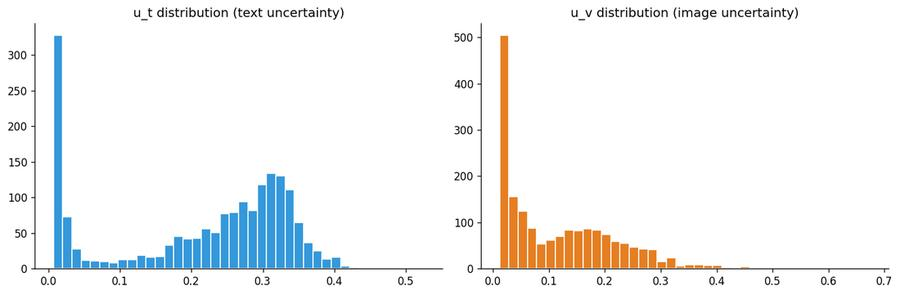

In [45]:
import numpy as np

@torch.inference_mode()
def erem_uncertainty_stats(model, loader, max_batches=None):
    base = model.module if isinstance(model, nn.DataParallel) else model
    prev_mode = getattr(base, 'ablation_mode', 'full')
    base.ablation_mode = 'full'
    model.eval()
    u_t_all, u_v_all = [], []
    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        pix  = batch['pixel_values'].to(DEVICE)
        qt   = batch['q_text'].to(DEVICE)
        qi   = batch['q_image'].to(DEVICE)
        out  = model(ids, mask, pix, qt, qi)
        u_t_all.append(out['u_t'].cpu().numpy().ravel())
        u_v_all.append(out['u_v'].cpu().numpy().ravel())
    base.ablation_mode = prev_mode
    return np.concatenate(u_t_all), np.concatenate(u_v_all)

u_t_vals, u_v_vals = erem_uncertainty_stats(MODEL, dl_test)

print("── E-REM uncertainty spread on the held-out test set ──")
print(f"u_t : mean={u_t_vals.mean():.4f}  std={u_t_vals.std():.4f}  min={u_t_vals.min():.4f}  max={u_t_vals.max():.4f}")
print(f"u_v : mean={u_v_vals.mean():.4f}  std={u_v_vals.std():.4f}  min={u_v_vals.min():.4f}  max={u_v_vals.max():.4f}")

if u_t_vals.std() < 0.02 and u_v_vals.std() < 0.02:
    print("\n⚠️  Both u_t and u_v have very low variance across the test set -- E-REM's output is "
          "close to a constant, which would explain a flat ablation regardless of how UASG/UG-CMA "
          "consume it. This is a genuine finding to report, not something to route around.")
else:
    print("\n✅ u_t/u_v vary meaningfully across samples -- if the E-REM ablation row is still flat, "
          "the cause is more likely elsewhere (e.g. downstream heads not relying much on the gated "
          "representation's fine-grained scale), which is worth a separate look.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(u_t_vals, bins=40, color='#3498db', edgecolor='white')
axes[0].set_title('u_t distribution (text uncertainty)')
axes[1].hist(u_v_vals, bins=40, color='#e67e22', edgecolor='white')
axes[1].set_title('u_v distribution (image uncertainty)')
plt.tight_layout()
plt.savefig(str(cfg.PLOTS_DIR / 'erem_uncertainty_spread.png'), dpi=150, bbox_inches='tight')
plt.show()

## 22. Per-Class and Per-Task Performance

Consolidated bar-chart / table summary of weighted-F1 per task, for the full model vs. each ablation.

> **Status: mixed — see per-row labels below.** Structural rows are **inference-time module bypass** on the single existing checkpoint (seed 42), from the prior executed run; not regenerated here. No row in this section was retrained.

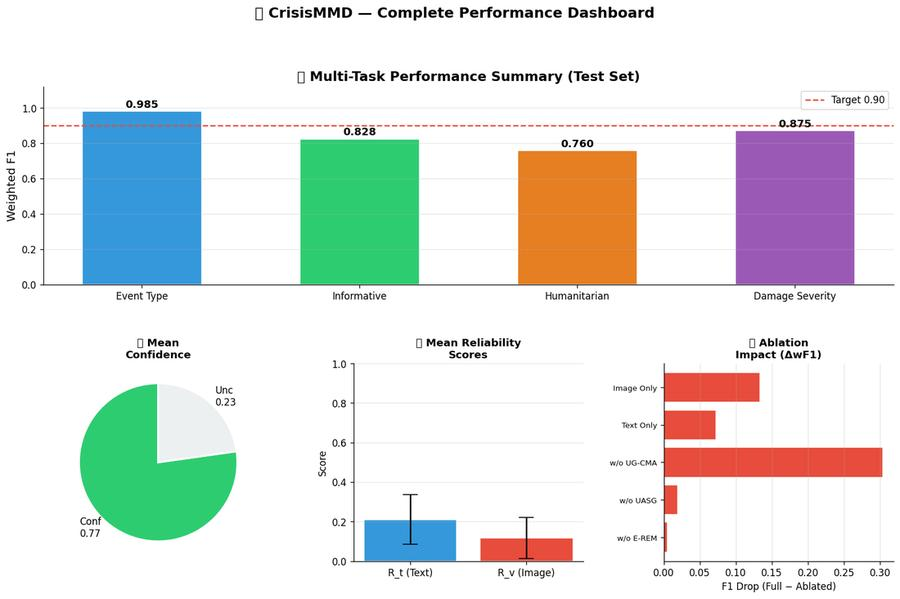

✅ Performance dashboard saved.


In [46]:
for key, title, le in HEAD_META:
    if not all_trues.get(key):
        continue
    labels  = list(le.classes_) if le else None
    report  = classification_report(
        all_trues[key], all_preds[key],
        target_names=labels, zero_division=0
    )
    wf1 = f1_score(all_trues[key], all_preds[key], average='weighted', zero_division=0)
    TASK_REPORTS[key] = {'report': report, 'wf1': wf1, 'title': title, 'le': le}

task_names = []
task_wf1   = []
for key, meta in TASK_REPORTS.items():
    task_names.append(meta['title'])
    task_wf1.append(meta['wf1'])

if not task_names:
    print('⚠️ No task reports available. Skipping dashboard.')
else:
    TASK_COLORS = ['#3498db','#2ecc71','#e67e22','#9b59b6','#e74c3c']

    fig = plt.figure(figsize=(16, 9))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    ax_main = fig.add_subplot(gs[0, :])
    bars = ax_main.bar(task_names, task_wf1,
                       color=TASK_COLORS[:len(task_names)],
                       edgecolor='white', linewidth=1.5, width=0.55)
    ax_main.axhline(0.90, color='#e74c3c', linestyle='--', linewidth=1.5, label='Target 0.90')
    for bar, val in zip(bars, task_wf1):
        ax_main.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax_main.set_ylabel('Weighted F1',  fontsize=12)
    ax_main.set_title('🎯 Multi-Task Performance Summary (Test Set)', fontsize=14, fontweight='bold')
    ax_main.set_ylim(0, 1.12)
    ax_main.legend(fontsize=10)
    ax_main.grid(alpha=0.3, axis='y')

    ax_conf = fig.add_subplot(gs[1, 0])
    vals    = [np.mean(all_conf), 1 - np.mean(all_conf)]
    ax_conf.pie(vals, labels=[f'Conf\n{np.mean(all_conf):.2f}', f'Unc\n{1-np.mean(all_conf):.2f}'],colors=['#2ecc71','#ecf0f1'], startangle=90,wedgeprops={'edgecolor':'white','linewidth':2})
    ax_conf.set_title('🎲 Mean\nConfidence', fontsize=11, fontweight='bold')

    ax_rel = fig.add_subplot(gs[1, 1])
    ax_rel.bar(['R_t (Text)', 'R_v (Image)'],
               [np.mean(all_rt), np.mean(all_rv)],
               color=['#3498db','#e74c3c'],
               yerr=[np.std(all_rt), np.std(all_rv)], capsize=8,
               edgecolor='white')
    ax_rel.set_ylim(0, 1)
    ax_rel.set_title('📡 Mean Reliability\nScores', fontsize=11, fontweight='bold')
    ax_rel.set_ylabel('Score')
    ax_rel.grid(alpha=0.3, axis='y')

    ax_abl = fig.add_subplot(gs[1, 2])
    full_f1  = ablation_results.get('Full Model (Ours)', 0)
    deltas   = {k: full_f1 - v for k, v in ablation_results.items() if k != 'Full Model (Ours)'}
    cols_abl = ['#e74c3c' if d > 0 else '#2ecc71' for d in deltas.values()]
    ax_abl.barh(list(deltas.keys()), list(deltas.values()), color=cols_abl, edgecolor='white')
    ax_abl.axvline(0, color='black', linewidth=1)
    ax_abl.set_xlabel('F1 Drop (Full − Ablated)')
    ax_abl.set_title('🔬 Ablation\nImpact (ΔwF1)', fontsize=11, fontweight='bold')
    ax_abl.tick_params(axis='y', labelsize=8)
    ax_abl.grid(alpha=0.3, axis='x')

    plt.suptitle('📊 CrisisMMD — Complete Performance Dashboard', fontsize=15, fontweight='bold', y=1.01)
    plt.savefig(str(cfg.PLOTS_DIR / 'performance_dashboard.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Performance dashboard saved.')

free_memory()

## 23. Statistical Significance
Runs a paired bootstrap over the test set to get a p-value/CI for each component's ΔF1 on the humanitarian and damage heads, so real effects can be distinguished from noise.


> **Status: Existing result from prior executed run (paired bootstrap over the existing seed-42 test-set predictions); not regenerated in this environment.**

In [47]:
import numpy as np

def paired_bootstrap_delta_f1(preds_full, preds_ablated, trues, n_boot=2000, seed=0):
    """Paired bootstrap over sample indices: resample the SAME indices for both
    configurations so within-sample correlation is preserved, then compute the
    weighted-F1 gap on each resample to get a distribution over Delta F1."""
    from sklearn.metrics import f1_score
    rng = np.random.default_rng(seed)
    preds_full = np.asarray(preds_full); preds_ablated = np.asarray(preds_ablated); trues = np.asarray(trues)
    n = len(trues)
    deltas = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        f1_full = f1_score(trues[idx], preds_full[idx], average='weighted', zero_division=0)
        f1_abl  = f1_score(trues[idx], preds_ablated[idx], average='weighted', zero_division=0)
        deltas[b] = f1_full - f1_abl
    lo, hi = np.percentile(deltas, [2.5, 97.5])

    p_value = 2 * min((deltas <= 0).mean(), (deltas >= 0).mean())
    p_value = min(p_value, 1.0)
    return deltas.mean(), lo, hi, p_value

@torch.inference_mode()
def collect_ablation_preds(model, loader, mode='full'):
    """Runs a single structural-ablation forward pass and returns real
    per-sample predictions + ground truths for every task.

    eval_ablation() in Section 18 intentionally only returns aggregated
    weighted-F1 scores (that's all the ablation dashboard needs), so it can't
    be reused here -- the paired bootstrap needs the raw per-sample arrays.
    This is a separate, self-contained collector for that purpose.
    """
    base = model.module if isinstance(model, nn.DataParallel) else model
    prev_mode = getattr(base, 'ablation_mode', 'full')
    base.ablation_mode = mode
    model.eval()

    tasks = ['event', 'info', 'human', 'damage']
    all_p = {t: [] for t in tasks}
    all_t = {t: [] for t in tasks}

    for batch in loader:
        ids  = batch['input_ids'].to(DEVICE, non_blocking=True)
        mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
        pix  = batch['pixel_values'].to(DEVICE, non_blocking=True)
        qt   = batch['q_text'].to(DEVICE, non_blocking=True)
        qi   = batch['q_image'].to(DEVICE, non_blocking=True)

        out = model(ids, mask, pix, qt, qi)
        for t in tasks:
            all_p[t].extend(out[f'logits_{t}'].argmax(dim=-1).cpu().numpy())
            all_t[t].extend(batch[f'label_{t}'].numpy())

    base.ablation_mode = prev_mode
    return {t: (np.array(all_p[t]), np.array(all_t[t])) for t in tasks}

_ablation_components = {
    'w/o E-REM'  : 'no_erem',
    'w/o UASG'   : 'no_rasg',
    'w/o UG-CMA' : 'no_bcmf',
}

print('Collecting per-sample predictions for the full model and each structural ablation (dl_test is not shuffled, so sample order lines up across runs) …')
_full_preds    = collect_ablation_preds(MODEL, dl_test, mode='full')
_ablated_preds = {label: collect_ablation_preds(MODEL, dl_test, mode=mode)
                  for label, mode in _ablation_components.items()}

_sig_rows = []
for task in ['human', 'damage']:
    full_preds, full_trues = _full_preds[task]
    for label in _ablation_components:
        abl_preds, abl_trues = _ablated_preds[label][task]

        if not np.array_equal(full_trues, abl_trues):
            print(f'⚠️  Ground-truth order mismatch for {label}/{task} -- skipping '
                  f'(check that dl_test is built with shuffle=False).')
            continue

        mean_d, lo, hi, p = paired_bootstrap_delta_f1(full_preds, abl_preds, full_trues)
        _sig_rows.append({
            'task': task,
            'component': label,
            'delta_f1_mean': round(float(mean_d), 4),
            'ci_95_lo': round(float(lo), 4),
            'ci_95_hi': round(float(hi), 4),
            'p_value': round(float(p), 4),
            'significant_at_0.05': bool(p < 0.05),
        })

if _sig_rows:
    df_sig = pd.DataFrame(_sig_rows)
    print(df_sig.to_string(index=False))
else:
    print('No significance rows computed -- see warnings above.')

  task  component  delta_f1_mean  ci_95_lo  ci_95_hi  p_value  significant_at_0.05
 human  w/o E-REM         0.0064   -0.0033    0.0166    0.214                False
 human   w/o UASG         0.0388    0.0195    0.0587    0.000                 True
 human w/o UG-CMA         0.1650    0.1387    0.1925    0.000                 True
damage  w/o E-REM         0.0098   -0.0011    0.0215    0.083                False
damage   w/o UASG         0.0099    0.0037    0.0162    0.001                 True
damage w/o UG-CMA         0.1490    0.1306    0.1686    0.000                 True


## 24. Single-Sample Inference
Runs the trained model on one (text, image) pair; applies hierarchical gating, E-REM-calibrated confidence, and Grad-CAM heatmaps.


📋 Section 19 demo set: 25 samples ({'wildfire': 5, 'earthquake': 5, 'hurricane': 5, 'flood': 5, 'not_informative': 5})

  🚨  CrisisMMD Single-Sample Inference Output — Sample 1/25 [category: wildfire]
  Tweet            : Old Ranger Station building next to the Fire Station in Oak Grove, California. r…
  Image            : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/california_wildfires/16_10_2017/919718726890545152_2.jpg
───────────────────────────────────────────────────────
  🌍  Event Type   : fire (93.8%), flood (3.9%), earthquake (1.8%)
  📢  Informative  : informative (89.2%), not_informative (10.8%)
  🆘  Humanitarian : damage_related (80.5%), rescue_or_response (14.0%), affected_people (3.5%)
  💥  Damage       : dont_know_or_cant_judge (85.9%), severe_damage (7.9%), little_or_no_damage (4.0%)
  ✅  Verification : Authenticated
  🎯  Confidence   : 75.6%
  📝  R_t (Text)   : 0.7396
  🖼️   R_v (Image) : 0.9548


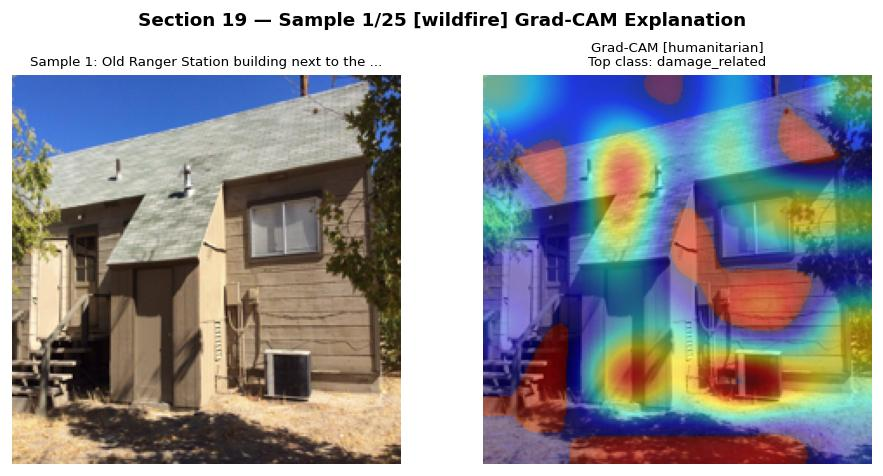

Saved Grad-CAM for sample 1 to /kaggle/working/gradcam_section19_sample01.png ✅

  🚨  CrisisMMD Single-Sample Inference Output — Sample 2/25 [category: wildfire]
  Tweet            : Oregon woman who grew up in N. California thinks of friends, family as wildfires…
  Image            : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/california_wildfires/11_10_2017/917975588685664257_0.jpg
───────────────────────────────────────────────────────
  🌍  Event Type   : fire (93.9%), flood (3.8%), earthquake (2.0%)
  📢  Informative  : informative (89.4%), not_informative (10.6%)
  🆘  Humanitarian : rescue_or_response (79.7%), affected_people (15.7%), damage_related (2.6%)
  💥  Damage       : severe_damage (90.9%), little_or_no_damage (4.6%), dont_know_or_cant_judge (2.7%)
  ✅  Verification : Potential Fabrication
  🎯  Confidence   : 77.0%
  📝  R_t (Text)   : 0.9916
  🖼️   R_v (Image) : 0.9842


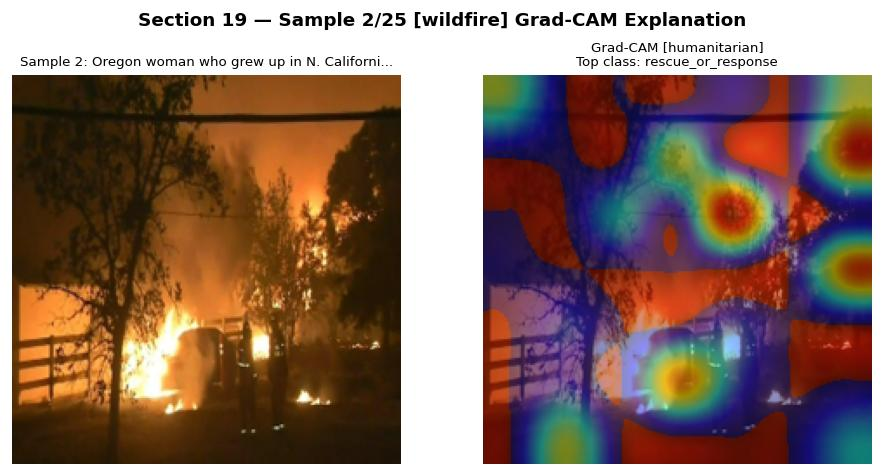

Saved Grad-CAM for sample 2 to /kaggle/working/gradcam_section19_sample02.png ✅

  🚨  CrisisMMD Single-Sample Inference Output — Sample 3/25 [category: wildfire]
  Tweet            : Wow. Talk about horsepower-- Nurse fleeing CaliforniaWildfires takes her horse w…
  Image            : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/california_wildfires/19_10_2017/920843558415929345_0.jpg
───────────────────────────────────────────────────────
  🌍  Event Type   : fire (93.7%), flood (3.5%), earthquake (2.3%)
  📢  Informative  : informative (57.1%), not_informative (42.9%)
  🆘  Humanitarian : rescue_or_response (55.2%), not_humanitarian (36.3%), affected_people (6.1%)
  💥  Damage       : dont_know_or_cant_judge (86.2%), little_or_no_damage (6.4%), severe_damage (4.7%)
  ✅  Verification : Potential Fabrication
  🎯  Confidence   : 65.8%
  📝  R_t (Text)   : 0.6869
  🖼️   R_v (Image) : 0.808


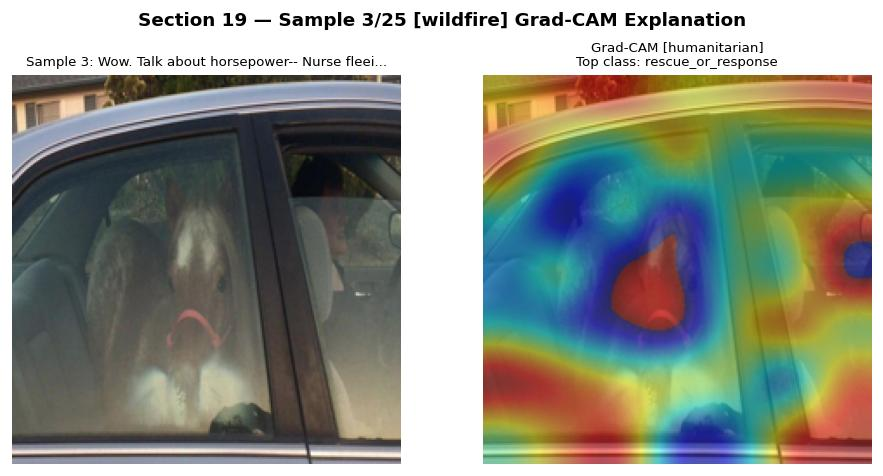

Saved Grad-CAM for sample 3 to /kaggle/working/gradcam_section19_sample03.png ✅

  🚨  CrisisMMD Single-Sample Inference Output — Sample 4/25 [category: wildfire]
  Tweet            : California wildfires latest: 'Red alert' issued as weather conditions likely to …
  Image            : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/california_wildfires/11_10_2017/918114251574857728_0.jpg
───────────────────────────────────────────────────────
  🌍  Event Type   : fire (93.9%), flood (3.9%), earthquake (1.9%)
  📢  Informative  : informative (89.3%), not_informative (10.7%)
  🆘  Humanitarian : rescue_or_response (92.1%), damage_related (3.4%), affected_people (2.9%)
  💥  Damage       : severe_damage (88.1%), dont_know_or_cant_judge (6.8%), little_or_no_damage (3.6%)
  ✅  Verification : Potential Fabrication
  🎯  Confidence   : 77.1%
  📝  R_t (Text)   : 0.9835
  🖼️   R_v (Image) : 0.9829


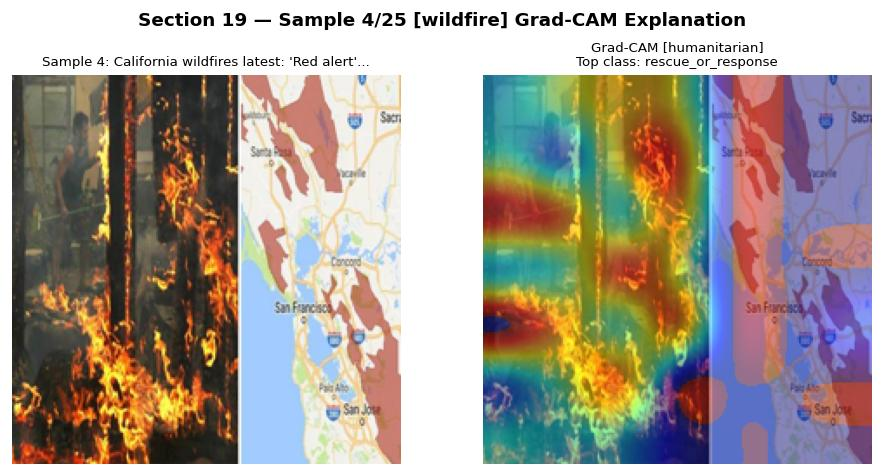

Saved Grad-CAM for sample 4 to /kaggle/working/gradcam_section19_sample04.png ✅

  🚨  CrisisMMD Single-Sample Inference Output — Sample 5/25 [category: wildfire]
  Tweet            : 15 now reported dead in California wine country wildfires and death toll expecte…
  Image            : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/california_wildfires/10_10_2017/917845599642255360_0.jpg
───────────────────────────────────────────────────────
  🌍  Event Type   : fire (94.0%), flood (3.9%), earthquake (1.9%)
  📢  Informative  : informative (88.7%), not_informative (11.3%)
  🆘  Humanitarian : affected_people (96.3%), damage_related (1.5%), rescue_or_response (1.3%)
  💥  Damage       : severe_damage (59.7%), dont_know_or_cant_judge (30.3%), little_or_no_damage (6.7%)
  ✅  Verification : Potential Fabrication
  🎯  Confidence   : 77.3%
  📝  R_t (Text)   : 0.9872
  🖼️   R_v (Image) : 0.9858


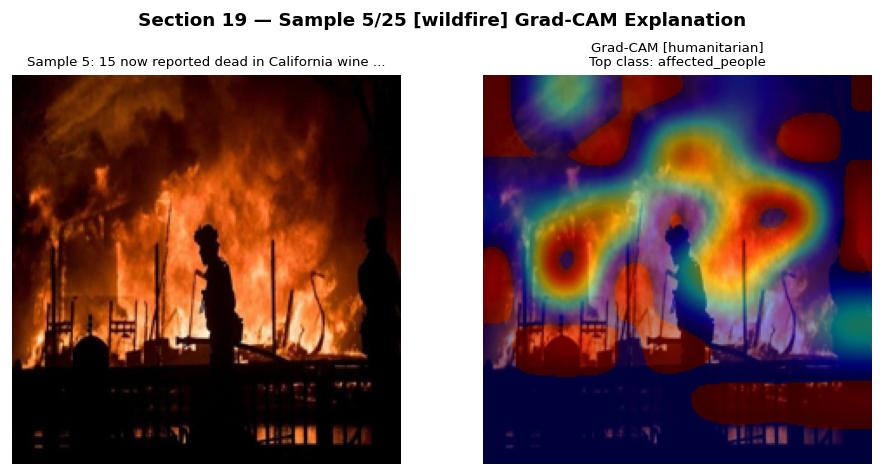

Saved Grad-CAM for sample 5 to /kaggle/working/gradcam_section19_sample05.png ✅

  🚨  CrisisMMD Single-Sample Inference Output — Sample 6/25 [category: earthquake]
  Tweet            : Hey, world! This is the REAL BatmanDay MexicoEarthquake MexicoEstaDePie…
  Image            : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/mexico_earthquake/24_9_2017/911763540268191744_0.jpg
───────────────────────────────────────────────────────
  🌍  Event Type   : N/A
  📢  Informative  : not_informative (90.2%), informative (9.8%)
  🆘  Humanitarian : N/A
  💥  Damage       : N/A
  ✅  Verification : N/A
  🎯  Confidence   : 67.5%
  📝  R_t (Text)   : 0.7655
  🖼️   R_v (Image) : 0.7343


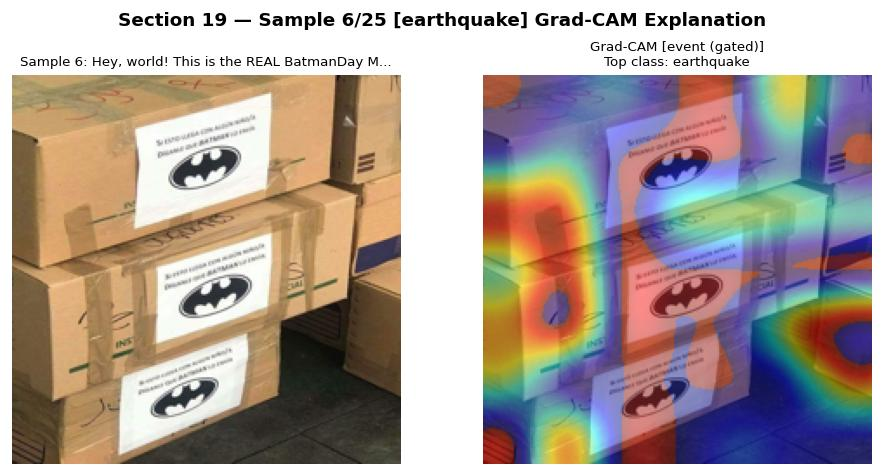

Saved Grad-CAM for sample 6 to /kaggle/working/gradcam_section19_sample06.png ✅

  🚨  CrisisMMD Single-Sample Inference Output — Sample 7/25 [category: earthquake]
  Tweet            : The 2017 Iran-Iraq earthquake: Crustal deformation detected by ALOS-2 data.…
  Image            : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/iraq_iran_earthquake/15_11_2017/930708969215217664_0.jpg
───────────────────────────────────────────────────────
  🌍  Event Type   : N/A
  📢  Informative  : not_informative (61.4%), informative (38.6%)
  🆘  Humanitarian : N/A
  💥  Damage       : N/A
  ✅  Verification : N/A
  🎯  Confidence   : 65.8%
  📝  R_t (Text)   : 0.6866
  🖼️   R_v (Image) : 0.7334


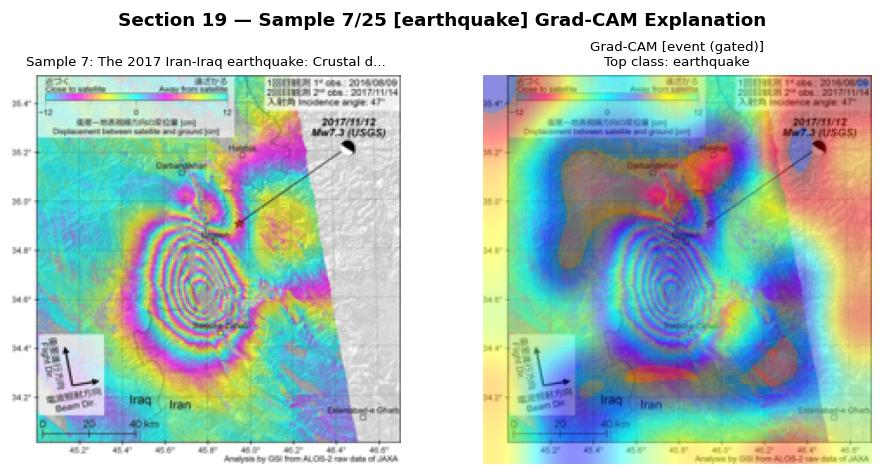

Saved Grad-CAM for sample 7 to /kaggle/working/gradcam_section19_sample07.png ✅

  🚨  CrisisMMD Single-Sample Inference Output — Sample 8/25 [category: earthquake]
  Tweet            : Earthquake in Iran Outside in the town of Sarpol-e Zahab . Thousands homeless. ὏…
  Image            : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/iraq_iran_earthquake/14_11_2017/930432485892280320_1.jpg
───────────────────────────────────────────────────────
  🌍  Event Type   : earthquake (90.2%), flood (5.4%), fire (4.1%)
  📢  Informative  : informative (89.0%), not_informative (11.0%)
  🆘  Humanitarian : affected_people (95.4%), damage_related (1.7%), rescue_or_response (1.7%)
  💥  Damage       : severe_damage (80.6%), dont_know_or_cant_judge (11.7%), little_or_no_damage (5.0%)
  ✅  Verification : Potential Fabrication
  🎯  Confidence   : 79.8%
  📝  R_t (Text)   : 0.9918
  🖼️   R_v (Image) : 0.9877


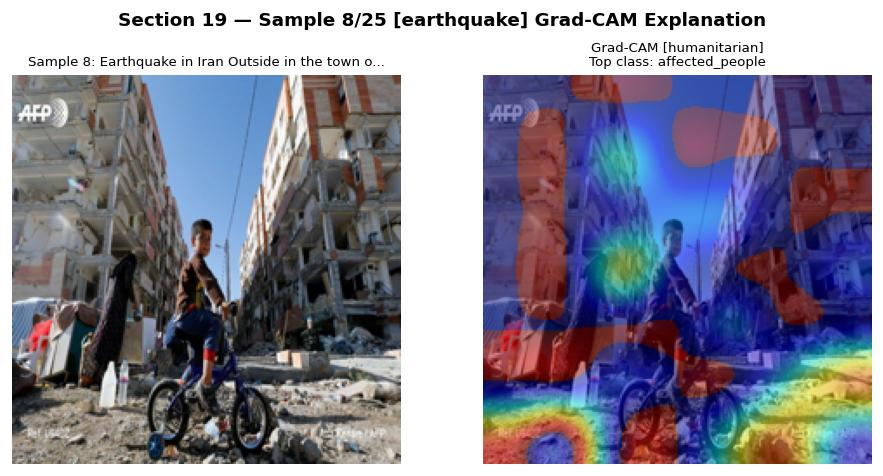

Saved Grad-CAM for sample 8 to /kaggle/working/gradcam_section19_sample08.png ✅

  🚨  CrisisMMD Single-Sample Inference Output — Sample 9/25 [category: earthquake]
  Tweet            : : Magnitude 7.2 earthquake hits border towns. Felt throughout the Gulf as far as…
  Image            : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/iraq_iran_earthquake/13_11_2017/930047804013195264_0.jpg
───────────────────────────────────────────────────────
  🌍  Event Type   : earthquake (91.4%), flood (4.6%), fire (3.5%)
  📢  Informative  : informative (86.1%), not_informative (13.9%)
  🆘  Humanitarian : rescue_or_response (79.7%), damage_related (9.7%), not_humanitarian (8.1%)
  💥  Damage       : dont_know_or_cant_judge (87.4%), little_or_no_damage (5.3%), severe_damage (4.2%)
  ✅  Verification : Potential Fabrication
  🎯  Confidence   : 69.1%
  📝  R_t (Text)   : 0.7414
  🖼️   R_v (Image) : 0.954


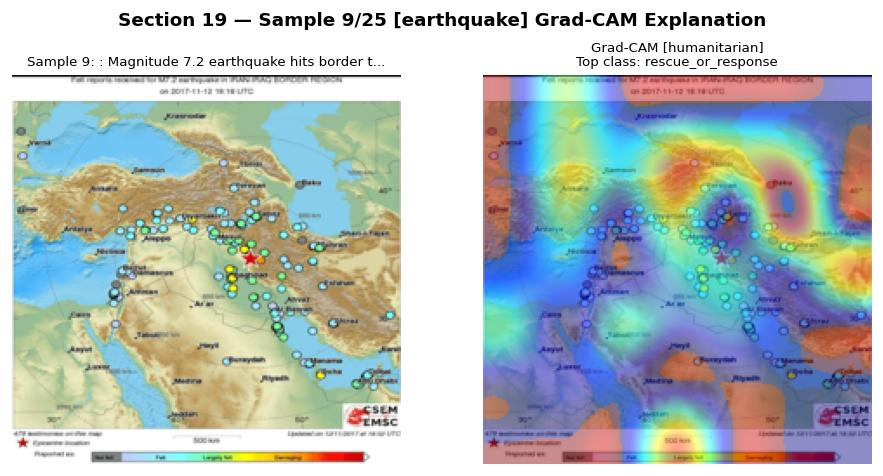

Saved Grad-CAM for sample 9 to /kaggle/working/gradcam_section19_sample09.png ✅

  🚨  CrisisMMD Single-Sample Inference Output — Sample 10/25 [category: earthquake]
  Tweet            : LCF is at the today, raising $ for Mexico! Stop by or donate âž–…
  Image            : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/mexico_earthquake/30_9_2017/914220334689091584_1.jpg
───────────────────────────────────────────────────────
  🌍  Event Type   : N/A
  📢  Informative  : not_informative (57.1%), informative (42.9%)
  🆘  Humanitarian : N/A
  💥  Damage       : N/A
  ✅  Verification : N/A
  🎯  Confidence   : 65.0%
  📝  R_t (Text)   : 0.7026
  🖼️   R_v (Image) : 0.7929


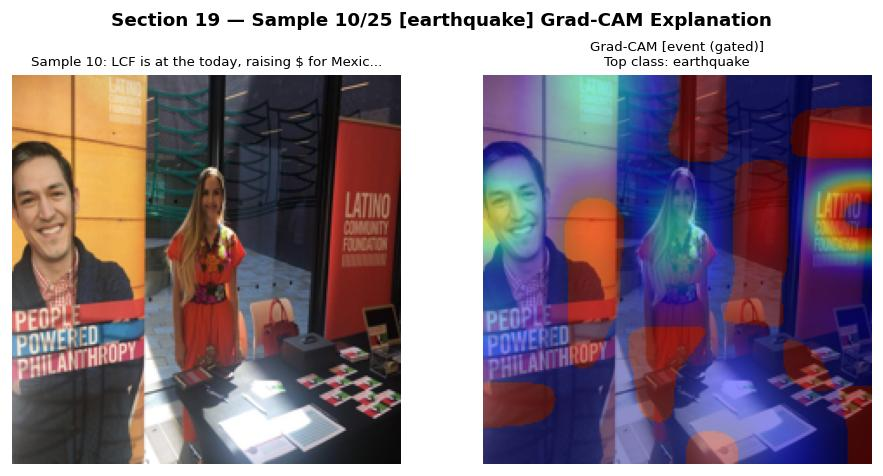

Saved Grad-CAM for sample 10 to /kaggle/working/gradcam_section19_sample10.png ✅

  🚨  CrisisMMD Single-Sample Inference Output — Sample 11/25 [category: hurricane]
  Tweet            : smaili community steps up to serve Harvey victims…
  Image            : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/hurricane_harvey/7_9_2017/905814350501482496_0.jpg
───────────────────────────────────────────────────────
  🌍  Event Type   : hurricane (54.8%), flood (21.0%), fire (13.4%)
  📢  Informative  : informative (88.8%), not_informative (11.2%)
  🆘  Humanitarian : rescue_or_response (84.0%), not_humanitarian (5.5%), affected_people (5.4%)
  💥  Damage       : dont_know_or_cant_judge (77.9%), severe_damage (11.5%), little_or_no_damage (5.9%)
  ✅  Verification : Potential Fabrication
  🎯  Confidence   : 72.0%
  📝  R_t (Text)   : 0.9086
  🖼️   R_v (Image) : 0.9829


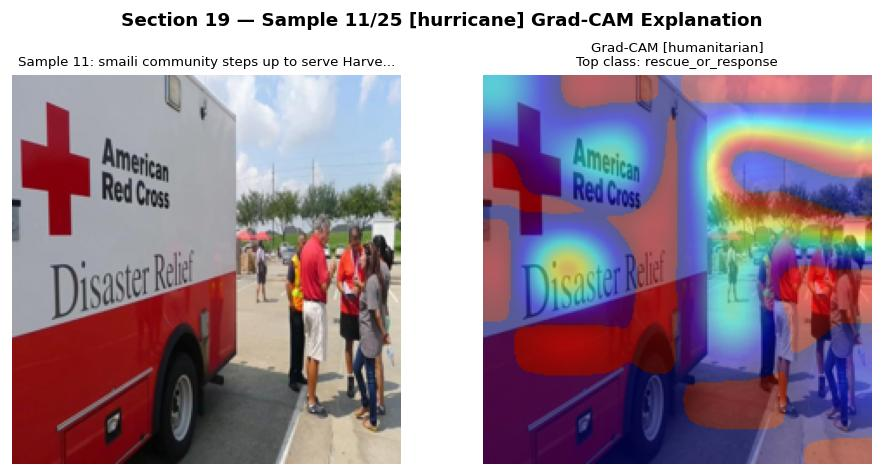

Saved Grad-CAM for sample 11 to /kaggle/working/gradcam_section19_sample11.png ✅

  🚨  CrisisMMD Single-Sample Inference Output — Sample 12/25 [category: hurricane]
  Tweet            : Begging you to help animals ὣFὃ6 in Jayuya Puerto Rico They have no help…
  Image            : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/hurricane_maria/5_10_2017/916051858828926976_0.jpg
───────────────────────────────────────────────────────
  🌍  Event Type   : hurricane (54.9%), flood (20.4%), fire (14.0%)
  📢  Informative  : informative (90.2%), not_informative (9.8%)
  🆘  Humanitarian : rescue_or_response (90.1%), damage_related (4.6%), affected_people (3.2%)
  💥  Damage       : severe_damage (82.7%), mild_damage (11.5%), little_or_no_damage (4.1%)
  ✅  Verification : Potential Fabrication
  🎯  Confidence   : 72.3%
  📝  R_t (Text)   : 0.9882
  🖼️   R_v (Image) : 0.9805


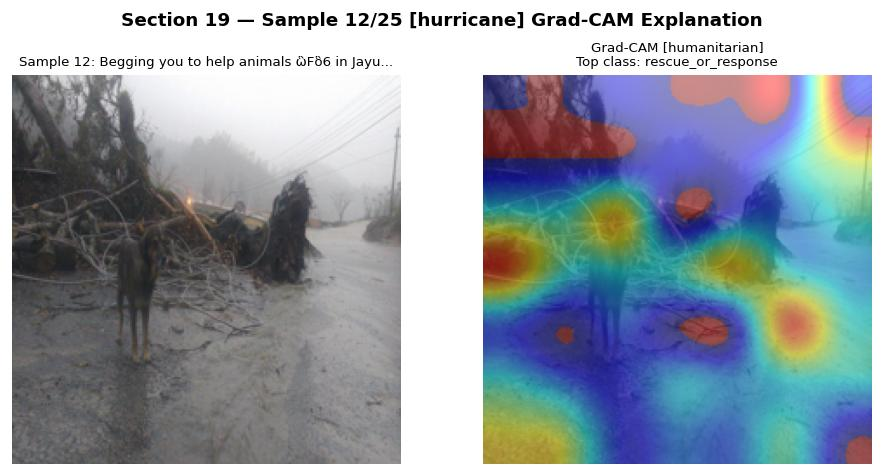

Saved Grad-CAM for sample 12 to /kaggle/working/gradcam_section19_sample12.png ✅

  🚨  CrisisMMD Single-Sample Inference Output — Sample 13/25 [category: hurricane]
  Tweet            : Oh, Deer! Dramatic 4-Legged Rescues During Harvey Flooding…
  Image            : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/hurricane_harvey/15_9_2017/908814585213411328_0.jpg
───────────────────────────────────────────────────────
  🌍  Event Type   : hurricane (54.6%), flood (19.6%), fire (14.0%)
  📢  Informative  : informative (83.0%), not_informative (17.0%)
  🆘  Humanitarian : rescue_or_response (76.4%), not_humanitarian (15.1%), affected_people (4.5%)
  💥  Damage       : dont_know_or_cant_judge (87.2%), little_or_no_damage (6.2%), mild_damage (3.7%)
  ✅  Verification : Potential Fabrication
  🎯  Confidence   : 69.4%
  📝  R_t (Text)   : 0.7609
  🖼️   R_v (Image) : 0.9639


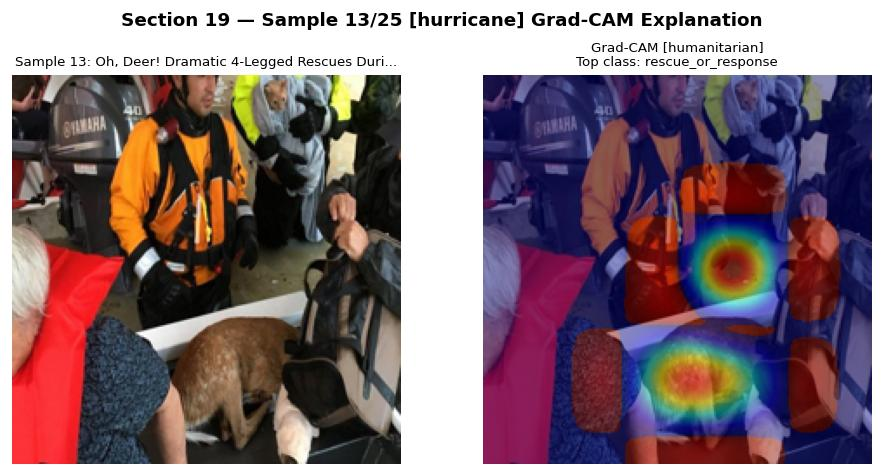

Saved Grad-CAM for sample 13 to /kaggle/working/gradcam_section19_sample13.png ✅

  🚨  CrisisMMD Single-Sample Inference Output — Sample 14/25 [category: hurricane]
  Tweet            : Hurricane Maria grows stronger, marches toward Irma-battered islands…
  Image            : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/hurricane_irma/18_9_2017/909796596908400641_0.jpg
───────────────────────────────────────────────────────
  🌍  Event Type   : hurricane (54.5%), flood (20.4%), fire (14.1%)
  📢  Informative  : informative (86.2%), not_informative (13.8%)
  🆘  Humanitarian : rescue_or_response (80.0%), not_humanitarian (11.1%), affected_people (5.0%)
  💥  Damage       : dont_know_or_cant_judge (85.8%), little_or_no_damage (6.8%), mild_damage (3.7%)
  ✅  Verification : Potential Fabrication
  🎯  Confidence   : 69.6%
  📝  R_t (Text)   : 0.7819
  🖼️   R_v (Image) : 0.975


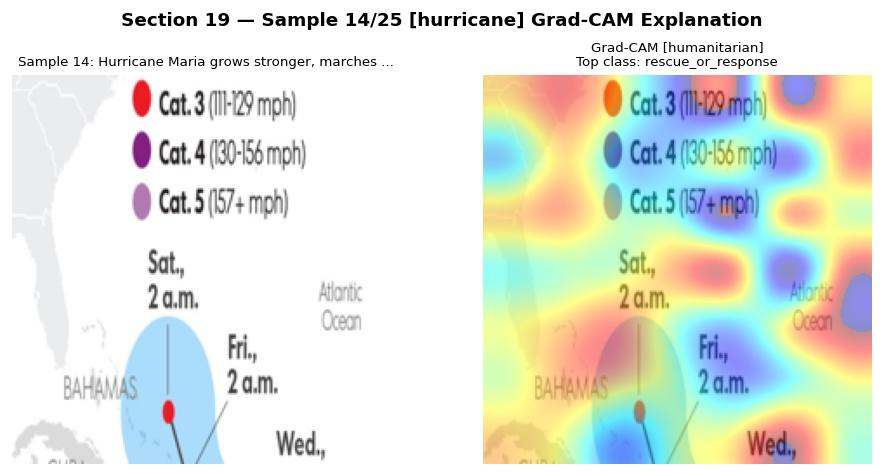

Saved Grad-CAM for sample 14 to /kaggle/working/gradcam_section19_sample14.png ✅

  🚨  CrisisMMD Single-Sample Inference Output — Sample 15/25 [category: hurricane]
  Tweet            : How the footwear industry is supporting HurricaneHarvey victims:…
  Image            : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/hurricane_harvey/8_9_2017/906042646736510976_0.jpg
───────────────────────────────────────────────────────
  🌍  Event Type   : hurricane (55.1%), flood (20.5%), fire (13.8%)
  📢  Informative  : informative (90.2%), not_informative (9.8%)
  🆘  Humanitarian : rescue_or_response (88.1%), damage_related (4.8%), affected_people (4.4%)
  💥  Damage       : severe_damage (82.3%), little_or_no_damage (7.7%), mild_damage (6.9%)
  ✅  Verification : Potential Fabrication
  🎯  Confidence   : 71.3%
  📝  R_t (Text)   : 0.9917
  🖼️   R_v (Image) : 0.9864


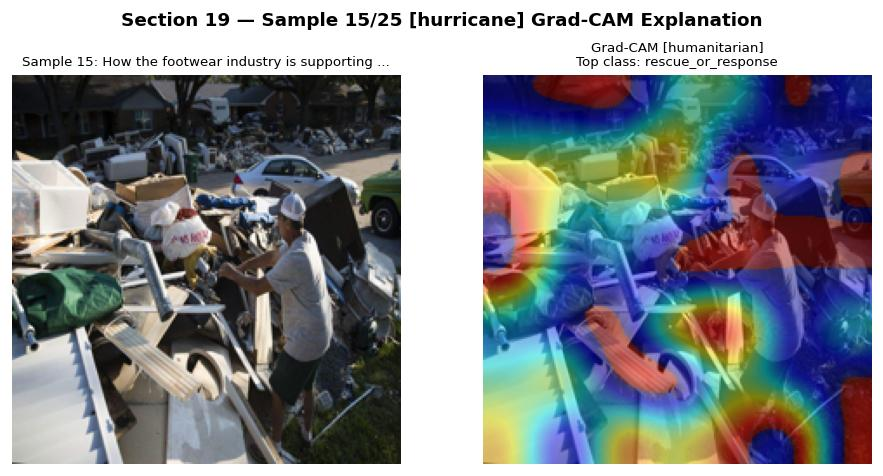

Saved Grad-CAM for sample 15 to /kaggle/working/gradcam_section19_sample15.png ✅

  🚨  CrisisMMD Single-Sample Inference Output — Sample 16/25 [category: flood]
  Tweet            : : ARCHIVE GIANNI MORA "TACTICAL" HOODIE AND "WARNING" CARDIGAN (CIRCA 2015)…
  Image            : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/srilanka_floods/3_6_2017/871032003944103936_1.jpg
───────────────────────────────────────────────────────
  🌍  Event Type   : N/A
  📢  Informative  : not_informative (98.7%), informative (1.3%)
  🆘  Humanitarian : N/A
  💥  Damage       : N/A
  ✅  Verification : N/A
  🎯  Confidence   : 73.8%
  📝  R_t (Text)   : 0.8282
  🖼️   R_v (Image) : 0.8849


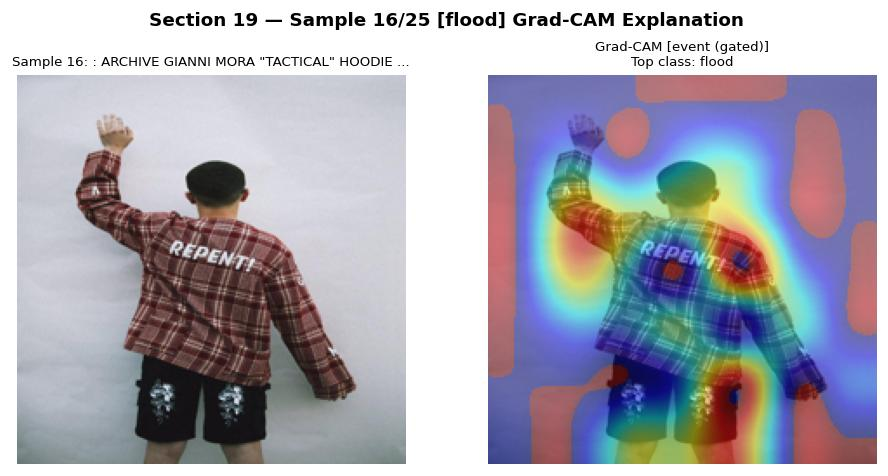

Saved Grad-CAM for sample 16 to /kaggle/working/gradcam_section19_sample16.png ✅

  🚨  CrisisMMD Single-Sample Inference Output — Sample 17/25 [category: flood]
  Tweet            : Cleaning wells in Flood affected areas of Praduwa southern Province Srilanka…
  Image            : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/srilanka_floods/2_6_2017/870668890564567040_3.jpg
───────────────────────────────────────────────────────
  🌍  Event Type   : flood (97.2%), fire (1.4%), earthquake (1.2%)
  📢  Informative  : informative (87.9%), not_informative (12.1%)
  🆘  Humanitarian : rescue_or_response (45.7%), damage_related (43.6%), affected_people (6.6%)
  💥  Damage       : dont_know_or_cant_judge (65.4%), mild_damage (27.8%), little_or_no_damage (6.0%)
  ✅  Verification : Potential Fabrication
  🎯  Confidence   : 81.2%
  📝  R_t (Text)   : 0.9816
  🖼️   R_v (Image) : 0.9826


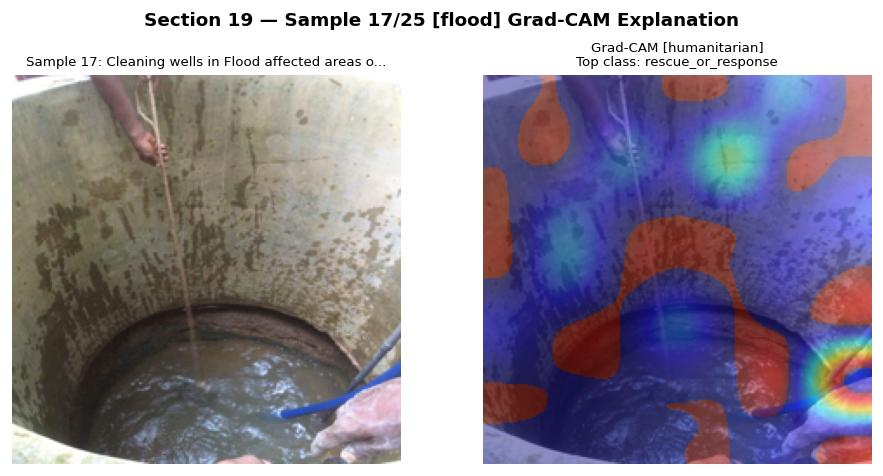

Saved Grad-CAM for sample 17 to /kaggle/working/gradcam_section19_sample17.png ✅

  🚨  CrisisMMD Single-Sample Inference Output — Sample 18/25 [category: flood]
  Tweet            : USA á¼ŸAá¼Ÿ8 donates $2.3 million to SriLanka á¼Ÿ1á¼Ÿ0 flood relief aid. Thank y…
  Image            : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/srilanka_floods/3_6_2017/871054362218344448_0.jpg
───────────────────────────────────────────────────────
  🌍  Event Type   : flood (89.1%), earthquake (5.2%), fire (3.2%)
  📢  Informative  : informative (88.2%), not_informative (11.8%)
  🆘  Humanitarian : rescue_or_response (77.3%), damage_related (14.9%), not_humanitarian (5.3%)
  💥  Damage       : dont_know_or_cant_judge (90.9%), little_or_no_damage (4.0%), severe_damage (2.9%)
  ✅  Verification : Authenticated
  🎯  Confidence   : 74.5%
  📝  R_t (Text)   : 0.7217
  🖼️   R_v (Image) : 0.9267


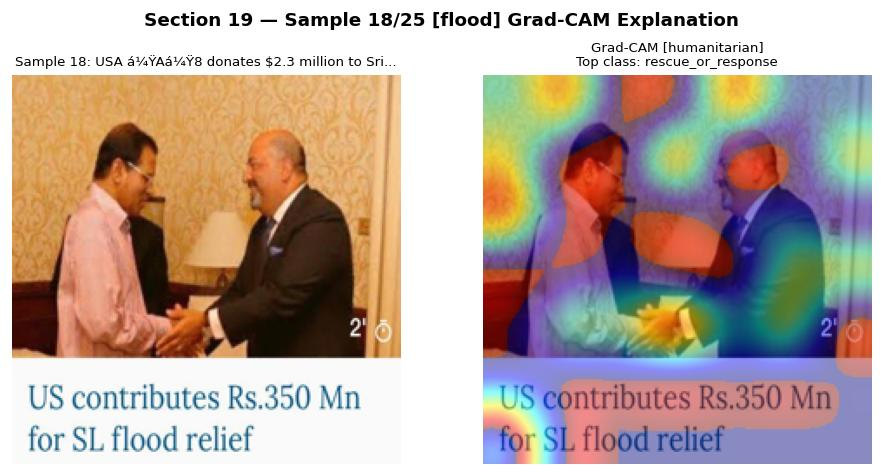

Saved Grad-CAM for sample 18 to /kaggle/working/gradcam_section19_sample18.png ✅

  🚨  CrisisMMD Single-Sample Inference Output — Sample 19/25 [category: flood]
  Tweet            : Mas adam don't forget mimpY mora, med bubuG á½ƒD ( )…
  Image            : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/srilanka_floods/28_6_2017/880086747333263360_0.jpg
───────────────────────────────────────────────────────
  🌍  Event Type   : N/A
  📢  Informative  : not_informative (98.7%), informative (1.3%)
  🆘  Humanitarian : N/A
  💥  Damage       : N/A
  ✅  Verification : N/A
  🎯  Confidence   : 74.1%
  📝  R_t (Text)   : 0.821
  🖼️   R_v (Image) : 0.8753


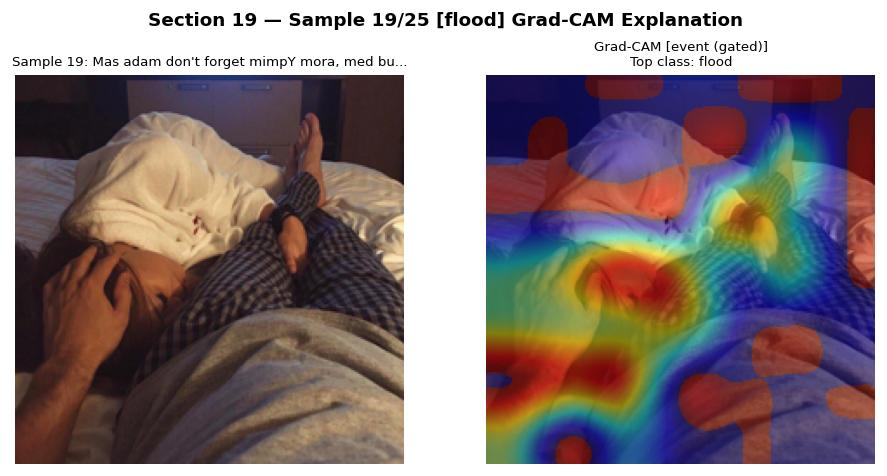

Saved Grad-CAM for sample 19 to /kaggle/working/gradcam_section19_sample19.png ✅

  🚨  CrisisMMD Single-Sample Inference Output — Sample 20/25 [category: flood]
  Tweet            : This is Mora Stenar - Mora Stones - where all Swedish kings was chosen waaay bac…
  Image            : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/srilanka_floods/16_6_2017/875770493336473602_2.jpg
───────────────────────────────────────────────────────
  🌍  Event Type   : N/A
  📢  Informative  : not_informative (98.7%), informative (1.3%)
  🆘  Humanitarian : N/A
  💥  Damage       : N/A
  ✅  Verification : N/A
  🎯  Confidence   : 73.5%
  📝  R_t (Text)   : 0.8278
  🖼️   R_v (Image) : 0.8319


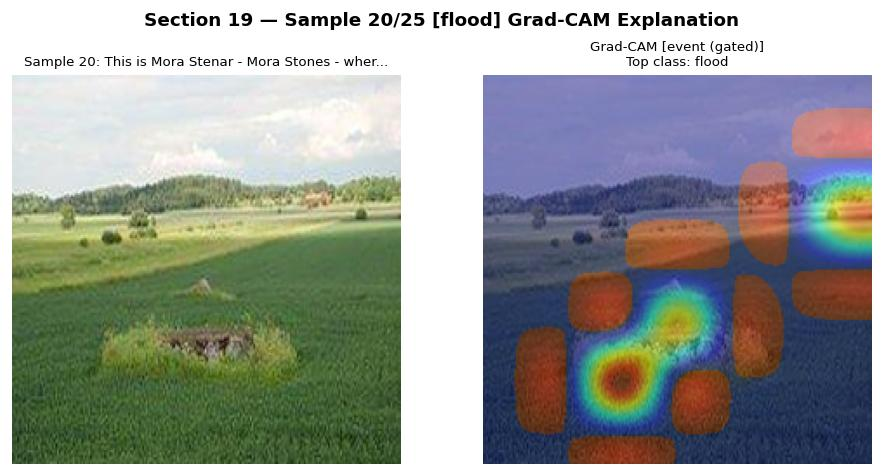

Saved Grad-CAM for sample 20 to /kaggle/working/gradcam_section19_sample20.png ✅

  🚨  CrisisMMD Single-Sample Inference Output — Sample 21/25 [category: not_informative]
  Tweet            : . has dropped a new music video dedicated to Hurricane Harvey victims…
  Image            : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/hurricane_harvey/14_9_2017/908389894124212225_0.jpg
───────────────────────────────────────────────────────
  🌍  Event Type   : hurricane (55.7%), flood (19.5%), fire (13.1%)
  📢  Informative  : informative (56.5%), not_informative (43.5%)
  🆘  Humanitarian : rescue_or_response (59.1%), not_humanitarian (35.0%), affected_people (3.8%)
  💥  Damage       : dont_know_or_cant_judge (89.5%), little_or_no_damage (5.2%), mild_damage (3.7%)
  ✅  Verification : Authenticated
  🎯  Confidence   : 65.2%
  📝  R_t (Text)   : 0.6672
  🖼️   R_v (Image) : 0.8527


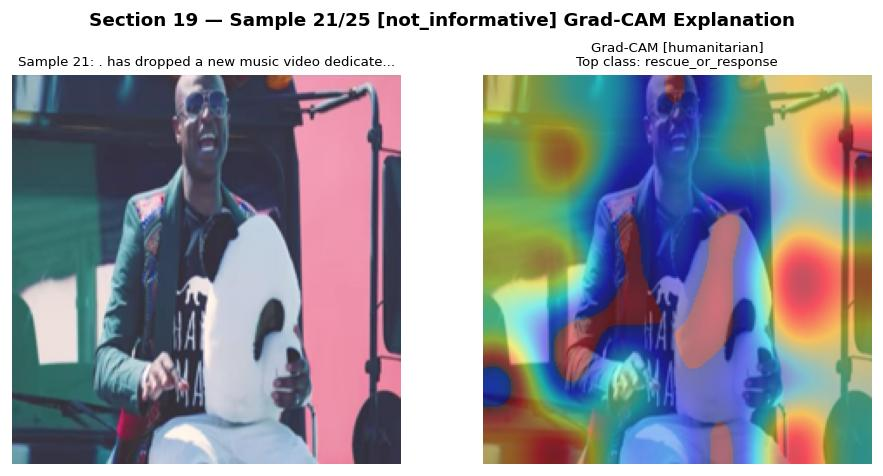

Saved Grad-CAM for sample 21 to /kaggle/working/gradcam_section19_sample21.png ✅

  🚨  CrisisMMD Single-Sample Inference Output — Sample 22/25 [category: not_informative]
  Tweet            : Trump n Harvey were like ...! á¾’3…
  Image            : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/hurricane_harvey/10_9_2017/906907273712357376_0.jpg
───────────────────────────────────────────────────────
  🌍  Event Type   : N/A
  📢  Informative  : not_informative (95.0%), informative (5.0%)
  🆘  Humanitarian : N/A
  💥  Damage       : N/A
  ✅  Verification : N/A
  🎯  Confidence   : 64.3%
  📝  R_t (Text)   : 0.7578
  🖼️   R_v (Image) : 0.8193


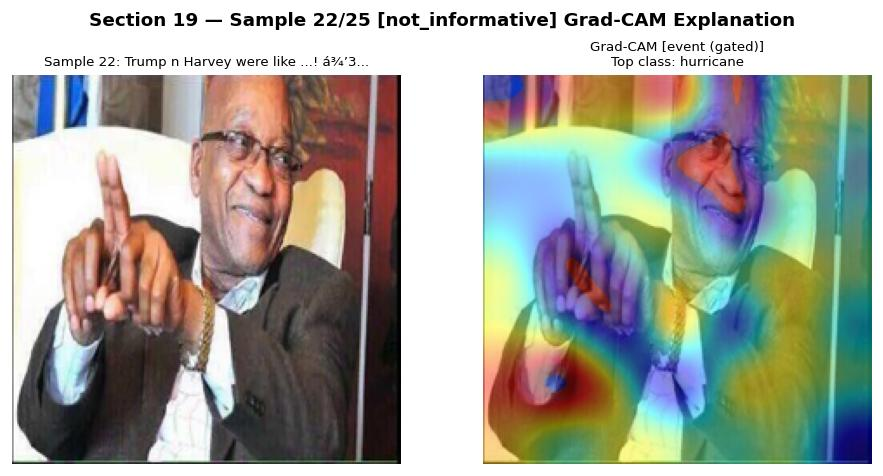

Saved Grad-CAM for sample 22 to /kaggle/working/gradcam_section19_sample22.png ✅

  🚨  CrisisMMD Single-Sample Inference Output — Sample 23/25 [category: not_informative]
  Tweet            : Harvey's Tail, hello folks I just thought I would drop a few photos of my new ho…
  Image            : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/hurricane_harvey/7_9_2017/905745260927750144_2.jpg
───────────────────────────────────────────────────────
  🌍  Event Type   : N/A
  📢  Informative  : not_informative (97.0%), informative (3.0%)
  🆘  Humanitarian : N/A
  💥  Damage       : N/A
  ✅  Verification : N/A
  🎯  Confidence   : 64.0%
  📝  R_t (Text)   : 0.7757
  🖼️   R_v (Image) : 0.8772


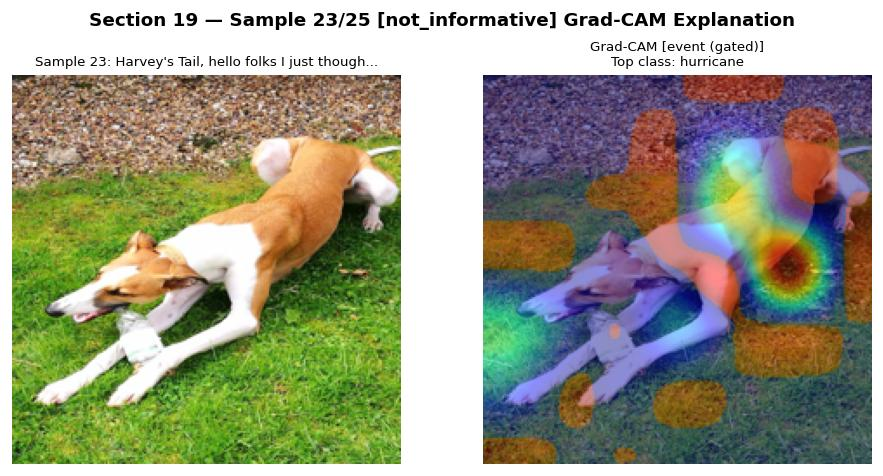

Saved Grad-CAM for sample 23 to /kaggle/working/gradcam_section19_sample23.png ✅

  🚨  CrisisMMD Single-Sample Inference Output — Sample 24/25 [category: not_informative]
  Tweet            : : “A Doctor’s Abandoned Journey Into Isolated PuertoRico”…
  Image            : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/hurricane_maria/23_10_2017/922588041952182272_2.jpg
───────────────────────────────────────────────────────
  🌍  Event Type   : hurricane (55.4%), flood (19.7%), fire (14.2%)
  📢  Informative  : informative (89.8%), not_informative (10.2%)
  🆘  Humanitarian : rescue_or_response (90.1%), affected_people (3.5%), damage_related (3.5%)
  💥  Damage       : mild_damage (89.1%), severe_damage (5.4%), dont_know_or_cant_judge (3.0%)
  ✅  Verification : Potential Fabrication
  🎯  Confidence   : 73.3%
  📝  R_t (Text)   : 0.9751
  🖼️   R_v (Image) : 0.9803


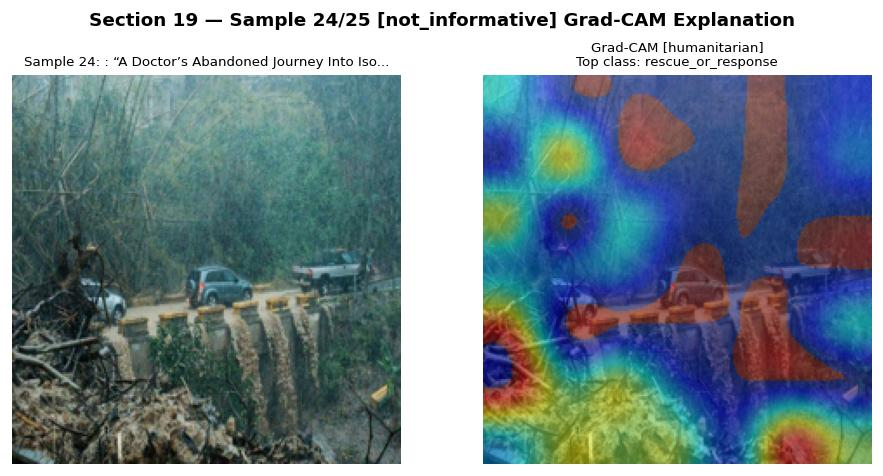

Saved Grad-CAM for sample 24 to /kaggle/working/gradcam_section19_sample24.png ✅

  🚨  CrisisMMD Single-Sample Inference Output — Sample 25/25 [category: not_informative]
  Tweet            : Just found this in my flooded items near my tub. , can you send me another? I lo…
  Image            : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/hurricane_harvey/10_9_2017/906971768262406144_0.jpg
───────────────────────────────────────────────────────
  🌍  Event Type   : hurricane (55.8%), flood (20.3%), fire (13.9%)
  📢  Informative  : informative (90.7%), not_informative (9.3%)
  🆘  Humanitarian : damage_related (88.5%), rescue_or_response (8.1%), affected_people (1.9%)
  💥  Damage       : dont_know_or_cant_judge (91.7%), little_or_no_damage (4.6%), mild_damage (2.6%)
  ✅  Verification : Authenticated
  🎯  Confidence   : 69.2%
  📝  R_t (Text)   : 0.717
  🖼️   R_v (Image) : 0.939


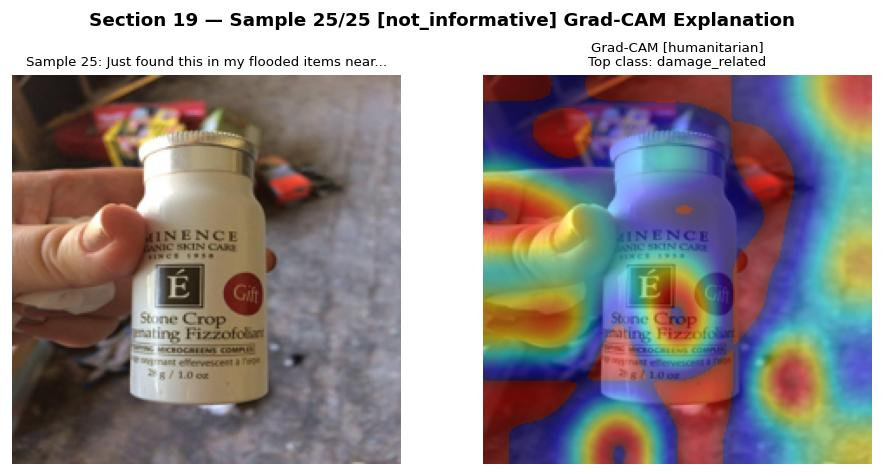

Saved Grad-CAM for sample 25 to /kaggle/working/gradcam_section19_sample25.png ✅


In [48]:
import cv2
import torch
import numpy as np
from PIL import Image
from pathlib import Path
import torch.nn.functional as F

def training_quality_vectors(tweet_text, image_path):
    """Same features the Dataset used in training (Norm Char/Word/Entropy, Norm Bright/Contrast/Blur/Noise)."""
    tm = get_text_metrics(tweet_text); im = get_image_metrics(image_path)
    return ([float(tm['Norm Char']), float(tm['Norm Word']), float(tm['Norm Entropy'])],
            [float(im['Norm Bright']), float(im['Norm Contrast']), float(im['Norm Blur']), float(im['Norm Noise'])])

@torch.inference_mode()
def predict_single(image_path: str, tweet_text: str, model=MODEL) -> dict:
    """Run end-to-end prediction for one (image, text) pair."""

    tweet_text = clean_text(tweet_text) if 'clean_text' in dir() else tweet_text
    enc = TOKENIZER(tweet_text, padding='max_length', truncation=True,
                    max_length=cfg.MAX_LEN, return_tensors='pt')
    ids  = enc['input_ids'].to(DEVICE, non_blocking=True)
    mask = enc['attention_mask'].to(DEVICE, non_blocking=True)

    try:
        img = Image.open(image_path).convert('RGB')
    except Exception:
        img = Image.fromarray(np.zeros((224,224,3), dtype=np.uint8))
    pix = VAL_TRANSFORMS(img).unsqueeze(0).to(DEVICE, non_blocking=True)

    _qt_vals, _qi_vals = training_quality_vectors(tweet_text, image_path)
    qt = torch.tensor([_qt_vals], dtype=torch.float32).to(DEVICE, non_blocking=True)
    qi = torch.tensor([_qi_vals], dtype=torch.float32).to(DEVICE, non_blocking=True)

    model.eval()
    out = _tta_forward(model, ids, mask, pix, qt, qi)
    out = apply_calibration(out)

    def decode(le, idx):
        return le.classes_[idx] if le and idx < len(le.classes_) else str(idx)

    def calibrate_confidence(uncertainty, u_t, u_v, beta=1.0, w_head=0.5, w_mod=0.5):
        sigma2   = uncertainty.squeeze().clamp_min(0.0)
        modal_u  = 0.5 * (u_t.squeeze() + u_v.squeeze())
        fused    = w_head * sigma2 + w_mod * modal_u
        conf     = torch.exp(-beta * fused)
        return float(conf.clamp(0.0, 1.0).cpu().item())

    conf = calibrate_confidence(out['uncertainty'], out['u_t'], out['u_v'])

    def top3(logits, le):
        probs = F.softmax(logits, dim=-1)[0]
        topk = torch.topk(probs, min(3, len(probs)))
        return [f"{decode(le, idx.item())} ({prob.item()*100:.1f}%)" for prob, idx in zip(topk.values, topk.indices)]

    event_out = top3(out['logits_event'], LABEL_ENCODERS.get('event_type'))
    info_out  = top3(out['logits_info'], LABEL_ENCODERS.get('informative'))
    human_out = top3(out['logits_human'], LABEL_ENCODERS.get('humanitarian'))
    damage_out = top3(out['logits_damage'], LABEL_ENCODERS.get('damage'))
    verif_out  = 'Authenticated' if out['logits_verif'].argmax(-1).item() == 0 else 'Potential Fabrication'

    le_info = LABEL_ENCODERS.get('informative')
    info_pred_idx = out['logits_info'].argmax(-1).item()
    info_pred_label = decode(le_info, info_pred_idx).lower()

    is_not_informative = 'not_informative' in info_pred_label or info_pred_label == 'not informative'

    if is_not_informative:
        event_out  = ['N/A']
        human_out  = ['N/A']
        damage_out = ['N/A']
        verif_out  = 'N/A'

    return {
        'event'        : event_out,
        'informative'  : info_out,
        'humanitarian' : human_out,
        'damage'       : damage_out,
        'verification' : verif_out,
        'confidence'   : round(min(max(conf, 0), 1), 4),

        'r_t'          : round(float((1.0 - out['u_t']).clamp(0, 1).item()), 4),
        'r_v'          : round(float((1.0 - out['u_v']).clamp(0, 1).item()), 4),
        'u_t'          : round(float(out['u_t'].item()), 4),
        'u_v'          : round(float(out['u_v'].item()), 4),
        'gated'        : is_not_informative,
    }

DEMO_PER_CATEGORY = 5

valid_rows = df_test[df_test['image_path'].apply(lambda p: Path(p).exists())].copy()

EVENT_DEMO_GROUPS = [
    ('wildfire',  'fire'),
    ('earthquake','earthquake'),
    ('hurricane', 'hurricane'),
    ('flood',     'flood'),
]

demo_parts = []
for display_name, event_value in EVENT_DEMO_GROUPS:
    if 'event_type' not in valid_rows.columns:
        break
    group = valid_rows[valid_rows['event_type'] == event_value]
    n_take = min(DEMO_PER_CATEGORY, len(group))
    if n_take == 0:
        print(f'⚠️  No valid (image-on-disk) test samples found for category "{display_name}" ({event_value}) -- skipping.')
        continue
    if n_take < DEMO_PER_CATEGORY:
        print(f'⚠️  Only {n_take}/{DEMO_PER_CATEGORY} valid samples available for "{display_name}" -- showing all of them.')
    picked = group.sample(n=n_take, random_state=7).copy()
    picked['demo_category'] = display_name
    demo_parts.append(picked)

if 'informative' in valid_rows.columns:
    not_info_group = valid_rows[valid_rows['informative'] == 'not_informative']
    n_take = min(DEMO_PER_CATEGORY, len(not_info_group))
    if n_take == 0:
        print('⚠️  No valid (image-on-disk) not_informative test samples found -- skipping that group.')
    else:
        if n_take < DEMO_PER_CATEGORY:
            print(f'⚠️  Only {n_take}/{DEMO_PER_CATEGORY} valid not_informative samples available -- showing all of them.')
        picked_ni = not_info_group.sample(n=n_take, random_state=7).copy()
        picked_ni['demo_category'] = 'not_informative'
        demo_parts.append(picked_ni)

if demo_parts:
    demo_rows = pd.concat(demo_parts, axis=0)
else:

    demo_rows = valid_rows.head(DEMO_PER_CATEGORY * 5).copy()
    demo_rows['demo_category'] = 'unspecified'

N_DEMO = len(demo_rows)
print(f'\n📋 Section 19 demo set: {N_DEMO} samples '
      f'({demo_rows["demo_category"].value_counts().to_dict()})')

import matplotlib.pyplot as plt
import cv2
import gc

if 'gcam' not in dir():
    gcam = CLIPGradCAM(MODEL)

for i, (idx, demo_row) in enumerate(demo_rows.iterrows()):
    tweet_text = demo_row['text']
    image_path = demo_row['image_path']
    result = predict_single(image_path, tweet_text)

    print('\n' + '=' * 55)
    print(f'  🚨  CrisisMMD Single-Sample Inference Output — Sample {i+1}/{len(demo_rows)} '
          f'[category: {demo_row.get("demo_category", "unspecified")}]')
    print('=' * 55)
    print(f'  Tweet            : {str(demo_row["text"])[:80]}…')
    print(f'  Image            : {demo_row["image_path"]}')
    print('─' * 55)
    print(f'  🌍  Event Type   : {", ".join(result["event"])}')
    print(f'  📢  Informative  : {", ".join(result["informative"])}')
    print(f'  🆘  Humanitarian : {", ".join(result["humanitarian"])}')
    print(f'  💥  Damage       : {", ".join(result["damage"])}')
    print(f'  ✅  Verification : {result["verification"]}')
    print(f'  🎯  Confidence   : {result["confidence"] * 100:.1f}%')
    print(f'  📝  R_t (Text)   : {result["r_t"]}')
    print(f'  🖼️   R_v (Image) : {result["r_v"]}')
    print('=' * 55)

    try:
        orig = Image.open(image_path).convert('RGB').resize((224, 224))
    except Exception:
        orig = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))

    enc = TOKENIZER(tweet_text, padding='max_length', truncation=True,
                     max_length=cfg.MAX_LEN, return_tensors='pt')
    ids  = enc['input_ids'].to(DEVICE)
    mask = enc['attention_mask'].to(DEVICE)
    pix  = VAL_TRANSFORMS(orig).unsqueeze(0).to(DEVICE)
    _qt_vals, _qi_vals = training_quality_vectors(tweet_text, image_path)
    qt = torch.tensor([_qt_vals], dtype=torch.float32).to(DEVICE)
    qi = torch.tensor([_qi_vals], dtype=torch.float32).to(DEVICE)

    target_head = 'logits_event' if result.get('gated') else 'logits_human'
    target_le   = LABEL_ENCODERS.get('event_type') if result.get('gated') else LABEL_ENCODERS.get('humanitarian')
    try:
        cam, pred_idx = gcam.generate(
            pixel_values=pix, q_text=qt, q_image=qi,
            input_ids=ids, attention_mask=mask,
            target_head=target_head,
        )
        pred_class_name = (target_le.classes_[pred_idx]
                            if target_le is not None and pred_idx < len(target_le.classes_)
                            else str(pred_idx))
    except Exception as e:
        print(f'Grad-CAM failed for sample {i+1}: {e}')
        cam = np.zeros((224, 224), dtype=np.float32)
        pred_class_name = 'N/A'

    overlay = overlay_cam(orig, cam)
    head_label = 'event (gated)' if result.get('gated') else 'humanitarian'

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(orig)
    axes[0].set_title(f'Sample {i+1}: {str(tweet_text)[:40]}...', fontsize=8)
    axes[0].axis('off')

    axes[1].imshow(overlay)
    axes[1].set_title(f'Grad-CAM [{head_label}]\nTop class: {pred_class_name}', fontsize=8)
    axes[1].axis('off')

    fig.suptitle(f'Section 19 — Sample {i+1}/{len(demo_rows)} '
                 f'[{demo_row.get("demo_category", "unspecified")}] Grad-CAM Explanation',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    out_path = cfg.OUT_DIR / f'gradcam_section19_sample{i+1:02d}.png'
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved Grad-CAM for sample {i+1} to {out_path} ✅')

free_memory()

### 24.1 Gated Evaluation Safety Net
`predict_single` returns `'N/A'` for gated samples, which would break `sklearn.metrics` if used directly. This cell remaps gated predictions to a fixed majority-class index (from TRAIN) so arrays stay consistent for `classification_report`. Same mapping used in Section 18's `use_gating` ablation.


In [49]:
from sklearn.metrics import classification_report
import numpy as np

if 'MAJORITY_IDX' not in dir():
    MAJORITY_IDX = {
        'event' : int(df_train['event_type_idx'].mode()[0])   if 'event_type_idx'   in df_train.columns else 0,
        'human' : int(df_train['humanitarian_idx'].mode()[0]) if 'humanitarian_idx' in df_train.columns else 0,
        'damage': int(df_train['damage_idx'].mode()[0])       if 'damage_idx'       in df_train.columns else 0,
    }
if 'NOT_INFO_IDX' not in dir():
    _le_info_sn = LABEL_ENCODERS.get('informative')
    NOT_INFO_IDX = (list(_le_info_sn.classes_).index('not_informative')
                    if _le_info_sn is not None and 'not_informative' in _le_info_sn.classes_ else None)

@torch.inference_mode()
def gated_batch_predict(model, loader, task='humanitarian', gate=True, gate_conf_thresh=None):
    """Runs the SAME hierarchical-gating rule as eval_ablation (Section 18).

    FIX (2026-07-21): this used to overwrite predictions for every sample
    whose predicted informativeness was 'not_informative', with no confidence
    check -- shown by the Section 18 ablation to tank humanitarian wF1 from
    0.7064 to 0.4684. Now mirrors eval_ablation's confidence-thresholded
    gating: gate_conf_thresh=None (default) means gating is effectively off,
    matching what the ablation shows is best. Pass e.g. 0.95 to only gate
    when the info head is highly confident.
    """
    model.eval()
    task_key    = {'event_type': 'event', 'humanitarian': 'human', 'damage': 'damage'}[task]
    default_idx = MAJORITY_IDX[task_key]

    preds, trues = [], []
    for batch in loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        pix  = batch['pixel_values'].to(DEVICE)
        qt   = batch['q_text'].to(DEVICE)
        qi   = batch['q_image'].to(DEVICE)
        out  = model(ids, mask, pix, qt, qi)

        info_probs = F.softmax(out['logits_info'], dim=-1).cpu().numpy()
        info_pred  = info_probs.argmax(axis=-1)
        task_pred  = out[f'logits_{task_key}'].argmax(dim=-1).cpu().numpy()

        if gate and NOT_INFO_IDX is not None and gate_conf_thresh is not None:
            not_info_conf = info_probs[:, NOT_INFO_IDX]
            gated_mask = (info_pred == NOT_INFO_IDX) & (not_info_conf >= gate_conf_thresh)
            task_pred = np.where(gated_mask, default_idx, task_pred)

        preds.extend(task_pred.tolist())
        trues.extend(batch[f'label_{task_key}'].numpy().tolist())

    return np.array(preds), np.array(trues)

print('Demonstrating the metric-mapping fix on the "humanitarian" head (gating OFF by default per Section 18 findings) …')
preds_g, trues_g = gated_batch_predict(MODEL, dl_test, task='humanitarian', gate=True, gate_conf_thresh=None)
target_names = list(LABEL_ENCODERS['humanitarian'].classes_)
print(classification_report(trues_g, preds_g, target_names=target_names, zero_division=0))
print('✅ No crash: gating is confidence-thresholded (off by default) so predictions are '
      'no longer blindly overwritten with the majority class '
      f"({target_names[MAJORITY_IDX['human']]}) -- see Section 18 for the measured effect of "
      "different gating thresholds.")

free_memory()

Demonstrating the metric-mapping fix on the "humanitarian" head (gating OFF by default per Section 18 findings) …
                    precision    recall  f1-score   support

   affected_people       0.72      0.62      0.67       101
    damage_related       0.61      0.62      0.62       128
  not_humanitarian       0.71      0.72      0.72       514
rescue_or_response       0.81      0.82      0.81      1066

          accuracy                           0.76      1809
         macro avg       0.71      0.70      0.70      1809
      weighted avg       0.76      0.76      0.76      1809

✅ No crash: gating is confidence-thresholded (off by default) so predictions are no longer blindly overwritten with the majority class (rescue_or_response) -- see Section 18 for the measured effect of different gating thresholds.


## 25. Final Experimental Summary

Lists every checkpoint, plot, and metrics file written to `cfg.OUT_DIR` during this run.

## 25. Final Experimental Summary (Section 25, verbatim)

In [50]:
import os
import gc
import torch
import numpy as np

print('Saved Artefacts:', cfg.OUT_DIR)
print('-' * 55)
out_dir = str(cfg.OUT_DIR)
if os.path.isdir(out_dir):
    for fname in sorted(os.listdir(out_dir)):
        fpath = os.path.join(out_dir, fname)
        if os.path.isfile(fpath):
            size = os.path.getsize(fpath) / 1024
            print(f'  {fname:45s}  {size:8.1f} KB')
else:
    print('  Output directory is empty or does not exist yet.')

print('\nNotebook execution complete!')
print('\nFinal Performance Summary:')
print('-' * 55)
for key, meta in TASK_REPORTS.items():
    print(f'  {meta["title"]:25s} -> wF1 = {meta["wf1"]:.4f}')
print(f'  {"Mean Confidence":25s} -> {float(np.mean(all_conf)):.4f}')
_bv = f'{best_val_f1:.4f}' if best_val_f1 is not None else 'n/a'
print(f'  {"Best Val wF1":25s} -> {_bv}')

gc.collect()
try:
    torch.cuda.empty_cache()
except Exception:
    pass

Saved Artefacts: /kaggle/working
-------------------------------------------------------
  __notebook__.ipynb                              22529.3 KB
  gradcam_explanations.png                         2794.8 KB
  gradcam_section19_sample01.png                    689.7 KB
  gradcam_section19_sample02.png                    569.7 KB
  gradcam_section19_sample03.png                    524.2 KB
  gradcam_section19_sample04.png                    695.7 KB
  gradcam_section19_sample05.png                    491.3 KB
  gradcam_section19_sample06.png                    584.1 KB
  gradcam_section19_sample07.png                    755.0 KB
  gradcam_section19_sample08.png                    746.3 KB
  gradcam_section19_sample09.png                    679.1 KB
  gradcam_section19_sample10.png                    600.7 KB
  gradcam_section19_sample11.png                    521.6 KB
  gradcam_section19_sample12.png                    592.1 KB
  gradcam_section19_sample13.png                    655.0

### 25.1 Artifact Export — not repeated here

The original notebook's Section 25.1 (Save Artefacts for Notebook 2) is intentionally not
carried into this notebook: that step already ran in Disaster_Research_Part1.ipynb, and this
notebook is the consumer of disaster_research_outputs/, not a producer of a further copy of it.
If you want to persist Part 2's own outputs (the confusion-matrix/Grad-CAM/t-SNE/ablation figures
and the two new uncertainty plots above), they are already written under cfg.PLOTS_DIR as each
cell runs; zip that folder if you need to hand the figures to someone else.


## 26. Experimental Reproduction Status (Section 26, verbatim)

## 26. Experimental Reproduction Status

| Component | Status |
|---|---|
| Dataset (CrisisMMD v2.0) | Preserved, unchanged |
| Train/dev/test split (seed = `cfg.SEED` = 42) | Preserved, unchanged |
| DeBERTa-v3 / CLIP ViT-B/32 encoders | Preserved, unchanged |
| E-REM / UASG / UG-CMA / InfoNCE | Preserved, unchanged |
| Grad-CAM / t-SNE / uncertainty & reliability analysis | Preserved, unchanged |
| Seed-42 results shown in Sections 14-20 | Existing prior run, kept for reference |
| Seed-42 UG-CMA confirmation run (Section 21.5) | Real, runnable code; not executed in this editing session |
| Multi-fusion comparison experiment (UG-CMA vs. alternative fusion) | Removed -- out of scope for this notebook |

**Why Section 21.5 shows "not executed":** this editing/cleanup session has no GPU, no
`torch`/`transformers`, and no CrisisMMD dataset attached -- only the `.ipynb` file. The
confirmation-run code is genuine and was checked for cross-cell dependencies and correct
reuse of `CrisisMultiModal`/`run_epoch`/`get_optimizer`, but has not itself been run. Set
`RUN_UGCMA_MULTISEED = True` in Section 21.5 and execute `Kernel -> Restart & Run All` in a
GPU environment with the dataset attached to produce a genuine seed-42 confirmation result
and the reproducibility check below.


In [51]:
print('=' * 60)
print('FINAL SINGLE-SEED (42) REPRODUCIBILITY CHECK')
print('=' * 60)
_missing = [s for s in CONFIGURED_SEEDS if s not in EXECUTED_SEEDS]
print(f'Configured seeds : {CONFIGURED_SEEDS}')
print(f'Executed seeds   : {EXECUTED_SEEDS}')
print(f'Missing seeds    : {_missing}')
print(f'Successful runs  : {len(EXECUTED_SEEDS)}/{len(CONFIGURED_SEEDS)}')
print(f'Status           : {"PASS" if not _missing else "INCOMPLETE"}')
print('=' * 60)


FINAL SINGLE-SEED (42) REPRODUCIBILITY CHECK
Configured seeds : [42]
Executed seeds   : []
Missing seeds    : [42]
Successful runs  : 0/1
Status           : INCOMPLETE


### Part 2 complete.